# M04 - Scar Analysis

This notebook is organized around six analysis questions:

| Analysis | Population | Variables | Main comparison / question |
|---|---|---|---|
| 1 | All scar-analysis patients | AHA-17 scar burden, total scar, polar maps | What does the population scar atlas look like? |
| 2 | All scar-analysis patients | 17 paired AHA segment burdens | Are some AHA segments more affected than others? |
| 3 | All scar-analysis patients | LAD, RCA, LCX burden | Are coronary territories affected differently? |
| 4 | Sex-labeled patients | AHA-17 vector, territory vector, total scar, PCA scores | Do male and female patients differ in scar extent or pattern? |
| 5 | Age-labeled patients | Age vs segment, territory, total scar, PCA scores | Is scar burden or pattern associated with age? |
| 6 | Patients with layer maps | Ring and territory transmurality | Where is scar more transmural? |

The four notebook sections are: setup, polar/AHA map construction, scar burden summaries, and statistical/transmurality analysis.

## Statistics Reference

Summary of the main statistical and descriptive analyses used in this notebook.

| Section | Analysis | Applied to | Output |
|---|---|---|---|
| 3.1 | Territory scar burden | LAD / RCA / LCX per patient | Per-patient burden, dominant territory, number of involved territories |
| 3.2 | Cohort and AHA-17 summaries | Age, sex, 17 AHA scar extents | Label availability, sex counts, age mean +/- SD, segment prevalence and extent |
| 3.3 | Friedman + pairwise Wilcoxon | 17 AHA segment burdens within patients | Spatial non-uniformity across AHA segments |
| 3.4 | Bootstrap confidence intervals | Mean scar burden per AHA segment | 95% CI from patients resampled with replacement |
| 4.1 | Normality diagnostics | Scalar variables, AHA segments, AHA-17 and territory vectors | Shapiro-Wilk, QQ plots, multivariate chi-square QQ diagnostics |
| 4.2 | Vertex count-based analysis | Binary scar-positive polar bins | Population maps, territory/ring/AHA summaries, age associations, PCA, bootstrap, variability, and archetype maps |
| 4.3 | Area-based analysis | CZ area, scar-normalized CZ area, and LV surface coverage | M03-style projection comparison, territory/ring/AHA summaries, age associations, PCA, bootstrap, variability, and archetype maps |
| 5 | Transmurality analysis | `Layer_10.vtk` ... `Layer_90.vtk` projected to polar map | Ring and territory transmurality summaries |
| Appendix | Descriptive sex summaries | 27M / 5F | Exploratory sex summaries kept outside the main Section 4 inference |

Multiple comparisons are corrected with Bonferroni where segment-wise families are tested. The main inferential analyses emphasize non-parametric and permutation approaches because scar burden is bounded, sparse, and zero-inflated.


## Section 1 - Setup, Data Loading, and Clinical Labels

In [68]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import (
    ttest_ind, spearmanr, pearsonr, f_oneway, friedmanchisquare, levene,
    mannwhitneyu, probplot, shapiro, chi2, kruskal, wilcoxon, f as f_dist,
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm


def find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for candidate in (base, base / 'lv-scar-segmentation'):
            if (candidate / 'src' / 'data_loading.py').exists():
                return candidate.resolve()
    raise FileNotFoundError('Could not locate lv-scar-segmentation.')


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for mod in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
    del sys.modules[mod]

from src.data_loading import scan
from src.mesh_utils import best_shell, get_cz_mesh, best_rv_mesh
from src.lv_geometry import (
    long_axis,
    rv_reference_pca,
    rv_reference_from_rv_mesh,
    prepare_polar_geometry,
    project_points_to_polar,
    polar_mask,
)

HD_ROOT      = r'F:/RM_TEKNON_DEVELOP'
CLINICAL_CSV = Path(r'C:/Users/joan/Desktop/FEINA/UPF/TFG/develop-vt.csv')
RESULTS      = ROOT / 'results'
SPLIT_JSON   = RESULTS / 'split.json'
OUT          = RESULTS / 'M04_scar_analysis'
OUT.mkdir(parents=True, exist_ok=True)

N_R     = 64
N_THETA = 128

AHA_DISPLAY_DEG = 0.0    # no roll: septal/RV vector stays at West (9 o'clock)

# Threshold: fraction of a coronary territory occupied to call that territory involved.
SCAR_THRESH = 0.02

NOTEBOOK_PALETTE = {
    'primary': '#356A8A',
    'secondary': '#7A5195',
    'accent': '#D95F02',
    'neutral': '#4D4D4D',
    'light_grid': '#B8B8B8',
    'lad': '#C83E4D',
    'rca': '#2F6B9A',
    'lcx': '#3F8F5F',
}
TERR_COLORS = {
    'LAD': NOTEBOOK_PALETTE['lad'],
    'RCA': NOTEBOOK_PALETTE['rca'],
    'LCX': NOTEBOOK_PALETTE['lcx'],
}
SCAR_CMAP = 'YlOrRd'
AREA_CMAP = 'YlOrRd'
COVERAGE_CMAP = 'YlOrRd'
VAR_CMAP = 'YlOrRd'

plt.rcParams['figure.dpi'] = 120
print(f'Project root: {ROOT}')
print('Config done.')

Project root: C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation
Config done.


### 1.2 Data Loading

In [69]:
all_cases = scan(HD_ROOT)

with open(SPLIT_JSON) as f:
    split = json.load(f)
known_keys = set(split['known'])

case_by_key = {f'{c.year}/{c.patient_id}': c for c in all_cases}
known = [
    case_by_key[k] for k in known_keys
    if k in case_by_key
    and case_by_key[k].tissue_surfaces.get('core') is not None
    and best_shell(case_by_key[k]) is not None
]

print(f'Known cases with shell + core zone: {len(known)}')
n_bz = sum(1 for c in known if c.tissue_surfaces.get('border_zone') is not None)
print(f'  of which have border zone mesh  : {n_bz} ({100*n_bz/max(len(known),1):.0f}%)')

Known cases with shell + core zone: 84
  of which have border zone mesh  : 84 (100%)


### 1.3 Clinical Labels (Sex and Age)

In [70]:
sex_map  = {}   # patient_id -> 'M' or 'F'
age_map  = {}   # patient_id -> float
core_pct_map   = {}  # patient_id -> float (core zone % of LV mass)
bz_core_pct_map = {} # patient_id -> float (core+BZ % of LV mass)
core_g_map = {}      # patient_id -> float (core zone grams)

if CLINICAL_CSV is not None and CLINICAL_CSV.exists():
    try:
        from src.clinical_data import load as _load_clinical
        _clin = _load_clinical(CLINICAL_CSV)

        for col, d in [('sex', sex_map), ('age', age_map),
                        ('core_pct', core_pct_map),
                        ('bz_core_pct', bz_core_pct_map),
                        ('core_g', core_g_map)]:
            if col in _clin.columns and 'patient_id' in _clin.columns:
                for _, row in _clin[['patient_id', col]].dropna().iterrows():
                    pid = str(row['patient_id']).strip().rstrip('.0')
                    d[pid] = row[col]

        # Recode sex to M/F
        sex_map = {pid: ('M' if int(v) == 1 else 'F')
                   for pid, v in sex_map.items() if int(v) in (1, 2)}

        teknon_pids = {str(c.patient_id).strip().rstrip('.0') for c in all_cases}
        known_pids = {str(c.patient_id).strip().rstrip('.0') for c in known}
        sex_pids = set(sex_map)
        age_pids = set(age_map)

        clinical_label_summary = pd.DataFrame([
            {'cohort': 'clinical CSV', 'label': 'sex', 'n_patients_with_label': len(sex_pids)},
            {'cohort': 'clinical CSV', 'label': 'age', 'n_patients_with_label': len(age_pids)},
            {'cohort': 'clinical CSV', 'label': 'both_sex_and_age', 'n_patients_with_label': len(sex_pids & age_pids)},
            {'cohort': 'clinical CSV', 'label': 'sex_or_age', 'n_patients_with_label': len(sex_pids | age_pids)},
            {'cohort': 'Teknon folders found', 'label': 'sex', 'n_patients_with_label': len(sex_pids & teknon_pids)},
            {'cohort': 'Teknon folders found', 'label': 'age', 'n_patients_with_label': len(age_pids & teknon_pids)},
            {'cohort': 'Teknon folders found', 'label': 'both_sex_and_age', 'n_patients_with_label': len(sex_pids & age_pids & teknon_pids)},
            {'cohort': 'Teknon folders found', 'label': 'sex_or_age', 'n_patients_with_label': len((sex_pids | age_pids) & teknon_pids)},
            {'cohort': 'known shell + core subset', 'label': 'sex', 'n_patients_with_label': len(sex_pids & known_pids)},
            {'cohort': 'known shell + core subset', 'label': 'age', 'n_patients_with_label': len(age_pids & known_pids)},
            {'cohort': 'known shell + core subset', 'label': 'both_sex_and_age', 'n_patients_with_label': len(sex_pids & age_pids & known_pids)},
            {'cohort': 'known shell + core subset', 'label': 'sex_or_age', 'n_patients_with_label': len((sex_pids | age_pids) & known_pids)},
        ])

        print('Clinical label availability from CSV:')
        print(f'  Sex labels: {len(sex_map)} patients  '
              f'(M={sum(v=="M" for v in sex_map.values())}, '
              f'F={sum(v=="F" for v in sex_map.values())})')
        print(f'  Age labels: {len(age_map)} patients')
        print(f'  Both sex and age labels: {len(set(sex_map) & set(age_map))} patients')
        print(f'  Sex or age label: {len(sex_pids | age_pids)} patients')
        print('Clinical labels matched to Teknon folders:')
        print(f'  Teknon patient folders scanned: {len(teknon_pids)}')
        print(f'  Sex labels among Teknon folders: {len(sex_pids & teknon_pids)} patients')
        print(f'  Age labels among Teknon folders: {len(age_pids & teknon_pids)} patients')
        print(f'  Both sex and age among Teknon folders: {len(sex_pids & age_pids & teknon_pids)} patients')
        print('Clinical labels matched to known shell + core subset:')
        print(f'  Known shell + core patients: {len(known_pids)}')
        print(f'  Sex labels among known subset: {len(sex_pids & known_pids)} patients')
        print(f'  Age labels among known subset: {len(age_pids & known_pids)} patients')
        print(f'  Both sex and age among known subset: {len(sex_pids & age_pids & known_pids)} patients')
        display(clinical_label_summary)
        clinical_label_summary.to_csv(OUT / 'clinical_label_availability.csv', index=False)
        print('Saved clinical_label_availability.csv')

        print(f'core_pct    : {len(core_pct_map)}')
        print(f'bz_core_pct : {len(bz_core_pct_map)}')
    except Exception as exc:
        print(f'Clinical loading failed: {exc}')
else:
    print(f'Clinical CSV not found: {CLINICAL_CSV}')

Clinical label availability from CSV:
  Sex labels: 94 patients  (M=79, F=15)
  Age labels: 94 patients
  Both sex and age labels: 94 patients
  Sex or age label: 94 patients
Clinical labels matched to Teknon folders:
  Teknon patient folders scanned: 165
  Sex labels among Teknon folders: 53 patients
  Age labels among Teknon folders: 53 patients
  Both sex and age among Teknon folders: 53 patients
Clinical labels matched to known shell + core subset:
  Known shell + core patients: 84
  Sex labels among known subset: 37 patients
  Age labels among known subset: 37 patients
  Both sex and age among known subset: 37 patients


,cohort,label,n_patients_with_label
0,clinical CSV,sex,94
1,clinical CSV,age,94
2,clinical CSV,both_sex_and_age,94
3,clinical CSV,sex_or_age,94
4,Teknon folders found,sex,53
5,Teknon folders found,age,53
6,Teknon folders found,both_sex_and_age,53
7,Teknon folders found,sex_or_age,53
8,known shell + core subset,sex,37
9,known shell + core subset,age,37


Saved clinical_label_availability.csv
core_pct    : 165
bz_core_pct : 165


### 1.4 Held-Out Set Sex Labels

Quick check of the held-out split composition using clinical sex labels only. This does not inspect the Teknon folders; it uses `results/split.json` and the `sex_map` loaded from the clinical CSV.

In [71]:
held_out_keys = split.get('held_out', [])
held_out_rows = []
for key in held_out_keys:
    pid = str(key).split('/')[-1].strip().rstrip('.0')
    held_out_rows.append({
        'key': key,
        'pid': pid,
        'sex': sex_map.get(pid, np.nan),
    })

held_out_sex_df = pd.DataFrame(held_out_rows)
held_out_sex_counts = (
    held_out_sex_df['sex']
    .fillna('missing')
    .value_counts()
    .rename_axis('sex')
    .reset_index(name='n')
)
held_out_sex_counts['percent'] = 100 * held_out_sex_counts['n'] / max(len(held_out_sex_df), 1)

n_held_out = len(held_out_sex_df)
n_female_held_out = int((held_out_sex_df['sex'] == 'F').sum()) if n_held_out else 0
n_male_held_out = int((held_out_sex_df['sex'] == 'M').sum()) if n_held_out else 0
n_missing_held_out = int(held_out_sex_df['sex'].isna().sum()) if n_held_out else 0

print(f'Held-out cases in split: {n_held_out}')
print(f'  Female: {n_female_held_out} / {n_held_out} ({100*n_female_held_out/max(n_held_out,1):.1f}%)')
print(f'  Male: {n_male_held_out} / {n_held_out} ({100*n_male_held_out/max(n_held_out,1):.1f}%)')
print(f'  Missing sex label: {n_missing_held_out} / {n_held_out} ({100*n_missing_held_out/max(n_held_out,1):.1f}%)')

print('\nHeld-out sex distribution:')
display(held_out_sex_counts)

print('Held-out female cases:')
display(held_out_sex_df[held_out_sex_df['sex'] == 'F'][['key', 'pid', 'sex']])

held_out_sex_df.to_csv(OUT / 'held_out_sex_labels.csv', index=False)
held_out_sex_counts.to_csv(OUT / 'held_out_sex_counts.csv', index=False)
print('Saved held_out_sex_labels.csv and held_out_sex_counts.csv')

Held-out cases in split: 21
  Female: 3 / 21 (14.3%)
  Male: 8 / 21 (38.1%)
  Missing sex label: 10 / 21 (47.6%)

Held-out sex distribution:


,sex,n,percent
0,missing,10,47.619048
1,M,8,38.095238
2,F,3,14.285714


Held-out female cases:


,key,pid,sex
8,2021/96014917,96014917,F
12,2024/17017195,17017195,F
15,2023/50082698,50082698,F


Saved held_out_sex_labels.csv and held_out_sex_counts.csv


## Section 2 - Polar Maps and AHA Segments

### 2.1 Polar Map Computation

Each patient produces one 64x128 binary polar map from their 3-D meshes:

1. **Meshes loaded**: LV shell (myocardium surface) and **core zone** scar mesh (`tissue_surfaces['core']`).
2. **Long axis**: PCA of LV shell vertices gives the apex-to-base axis.
3. **Circumferential reference (theta = 0)**: set at the RV insertion / septal reference.
4. **Projection**: each CZ vertex is mapped to `s` (0 apex, 1 base) and clockwise `theta`.
5. **Binning**: each polar bin is 1 if any CZ vertex falls there.
6. **Bullseye orientation**: centre = apex, outer ring = base, septum at 9 o'clock.

In [72]:
import pyvista as pv


def _get_bz_mesh(case):
    """Load border zone mesh (returns None if not available)."""
    path = case.tissue_surfaces.get('border_zone')
    if path is None or not path.exists():
        return None
    return pv.read(str(path))


def _build_polar_map(lv_shell, scar_mesh, rv_mesh=None, n_r=N_R, n_theta=N_THETA):
    """
    Project scar_mesh vertices onto the LV polar grid.

    Returns (n_r, n_theta) bool array: True = scar vertex in that bin.
    Orientation: s=0 apex (centre), s=1 base (outer ring).
    theta=0 septum, increasing CW (ANT at top in bullseye display).
    """
    if rv_mesh is not None:
        ref_fn = lambda mesh, ax, ap: rv_reference_from_rv_mesh(mesh, rv_mesh, ax, ap)
        geom   = prepare_polar_geometry(lv_shell, ref_fn=ref_fn, rv_mesh=rv_mesh)
    else:
        geom = prepare_polar_geometry(lv_shell, rv_mesh=None)
    theta, s = project_points_to_polar(scar_mesh.points, geom)
    theta = (2.0 * np.pi - theta) % (2.0 * np.pi)   # CW flip
    ri = np.clip((s * n_r).astype(int), 0, n_r - 1)
    ti = np.clip((theta / (2 * np.pi) * n_theta).astype(int), 0, n_theta - 1)
    return polar_mask(theta, s, n_r, n_theta, roll_deg=AHA_DISPLAY_DEG)
def _polar_map_for_case(case, use_rv=True):
    shell = best_shell(case)
    cz    = get_cz_mesh(case)
    if shell is None or cz is None:
        return None
    rv = best_rv_mesh(case) if use_rv else None
    return _build_polar_map(shell, cz, rv_mesh=rv)


def _polar_map_bz_for_case(case, use_rv=True):
    shell = best_shell(case)
    bz    = _get_bz_mesh(case)
    if shell is None or bz is None:
        return None
    rv = best_rv_mesh(case) if use_rv else None
    return _build_polar_map(shell, bz, rv_mesh=rv)


# Compute core zone polar maps (main analysis)
pmaps = {}
for case in tqdm(known, desc='Core zone polar maps'):
    key = f'{case.year}/{case.patient_id}'
    try:
        m = _polar_map_for_case(case, use_rv=True)
        if m is not None:
            pmaps[key] = m.astype(float)
    except Exception as e:
        print(f'  skip {key}: {e}')

# Compute border zone polar maps
pmaps_bz = {}
for case in tqdm(known, desc='Border zone polar maps'):
    key = f'{case.year}/{case.patient_id}'
    try:
        m = _polar_map_bz_for_case(case, use_rv=True)
        if m is not None:
            pmaps_bz[key] = m.astype(float)
    except Exception as e:
        pass   # BZ mesh often absent; silent skip

print(f'Core zone polar maps : {len(pmaps)}')
print(f'Border zone polar maps: {len(pmaps_bz)}')

Border zone polar maps: 100%|██████████| 84/84 [00:11<00:00,  7.41it/s]

Core zone polar maps : 84
Border zone polar maps: 84


In [73]:

# --- Bullseye display helpers (same convention as M03) ---

_AHA_SEG_LABELS_M04 = (
    (1, 90, 0.875), (2, 30, 0.875), (3, 330, 0.875),
    (4, 270, 0.875), (5, 210, 0.875), (6, 150, 0.875),
    (7, 90, 0.625), (8, 30, 0.625), (9, 330, 0.625),
    (10, 270, 0.625), (11, 210, 0.625), (12, 150, 0.625),
    (13, 90, 0.375), (14, 0, 0.375), (15, 270, 0.375),
    (16, 180, 0.375), (17, 90, 0.125),
)


def _mark_septal_point_m04(ax, theta=np.deg2rad(60), radius=1.04):
    ax.scatter([theta], [radius], s=26, color='dodgerblue', edgecolor='white',
               linewidth=0.7, zorder=10, clip_on=False)


def _draw_bullseye_grid_m04(ax):
    t = np.linspace(0, 2 * np.pi, 361)
    for r in (0.25, 0.50, 0.75, 1.0):
        ax.plot(t, np.full_like(t, r), color='#555', lw=0.6, alpha=0.6)
    for deg in (0, 60, 120, 180, 240, 300):
        ax.plot([np.deg2rad(deg)] * 2, [0.5, 1.0], color='#555', lw=0.6, alpha=0.6)
    for deg in (45, 135, 225, 315):
        ax.plot([np.deg2rad(deg)] * 2, [0.0, 0.5], color='#555', lw=0.6, alpha=0.6)
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    ax.set_rticks([])
    ax.set_xticks([])
    _mark_septal_point_m04(ax)


def draw_bullseye_m04(data, ax, title=None, cmap='hot_r', vmax=None, label_segs=False):
    # Render (n_r x n_theta) array as AHA bullseye on a polar axis.
    arr = np.asarray(data, dtype=float)
    if vmax is None:
        vmax = max(float(np.nanmax(arr)), 1e-12)
    T, R = np.meshgrid(
        np.linspace(0, 2 * np.pi, arr.shape[1] + 1),
        np.linspace(0, 1.0,       arr.shape[0] + 1),
    )
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    mesh = ax.pcolormesh(T, R, arr, cmap=cmap, vmin=0, vmax=vmax, shading='flat')
    _draw_bullseye_grid_m04(ax)
    if label_segs:
        for seg, deg, r in _AHA_SEG_LABELS_M04:
            ax.text(np.deg2rad(deg % 360), r, str(seg), fontsize=6,
                    ha='center', va='center', color='black',
                    bbox=dict(boxstyle='circle,pad=0.12', facecolor='white',
                              edgecolor='none', alpha=0.7))
    if title:
        ax.set_title(title, fontsize=9, pad=6)
    return mesh


def add_colorbar_m04(mappable, ax, label=None, fraction=0.046, pad=0.10):
    """Attach a compact colorbar to one polar bullseye axis."""
    cbar = ax.figure.colorbar(mappable, ax=ax, fraction=fraction, pad=pad)
    if label:
        cbar.set_label(label, fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    return cbar


print('Bullseye helpers ready.')


Bullseye helpers ready.


### 2.2 Example Polar Maps

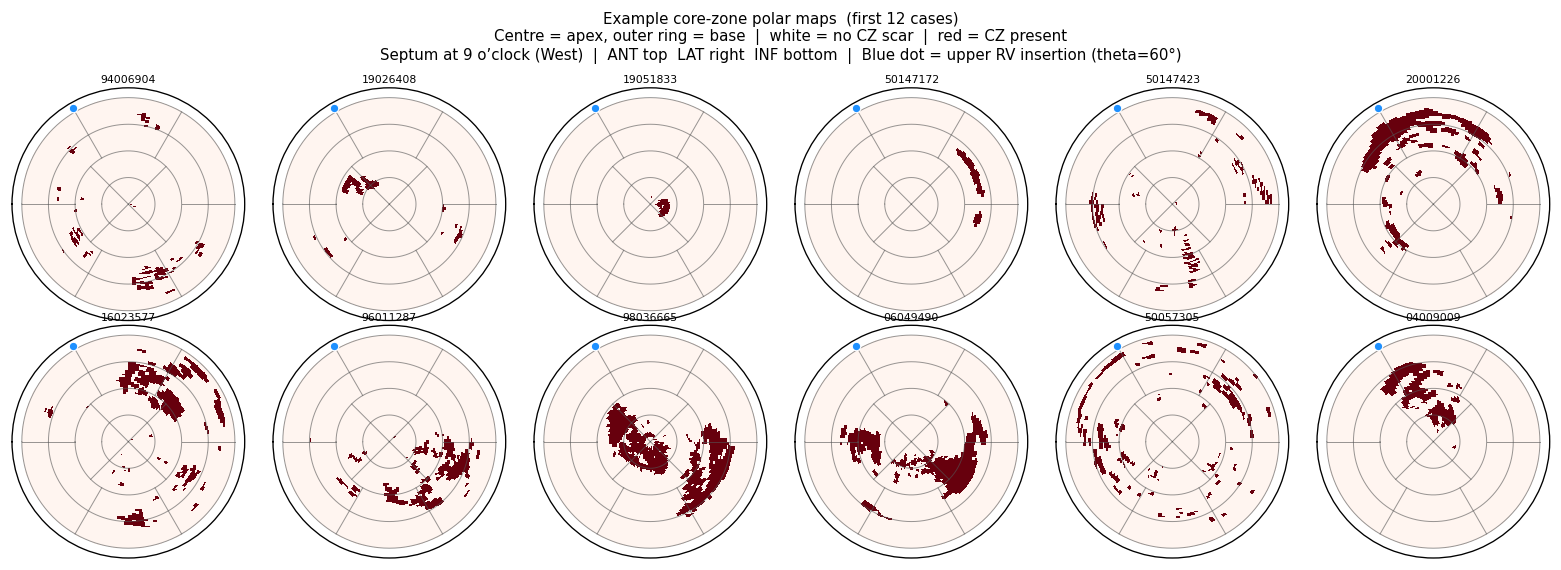

Saved example_polar_maps.png


In [74]:

# Show first N cases with available polar maps as bullseye plots (M03 style)
_SHOW_N  = 12
_NCOLS   = 6
_pm_keys = list(pmaps.keys())[:_SHOW_N]
_nrows   = int(np.ceil(len(_pm_keys) / _NCOLS))

fig = plt.figure(figsize=(_NCOLS * 2.2, _nrows * 2.4))
fig.suptitle(
    f'Example core-zone polar maps  (first {len(_pm_keys)} cases)\n'
    'Centre = apex, outer ring = base  |  white = no CZ scar  |  red = CZ present\n'
    'Septum at 9 o’clock (West)  |  ANT top  LAT right  INF bottom  |  '
    'Blue dot = upper RV insertion (theta=60°)',
    fontsize=9,
)

for idx, key in enumerate(_pm_keys):
    ax = fig.add_subplot(_nrows, _NCOLS, idx + 1, projection='polar')
    draw_bullseye_m04(pmaps[key], ax, cmap='Reds', vmax=1.0)
    pid = key.split('/')[-1]
    ax.set_title(pid, fontsize=6.5, pad=3)

plt.tight_layout()
plt.savefig(OUT / 'example_polar_maps.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved example_polar_maps.png')


### 2.3 AHA Segment Grid and Coronary Territory Map

Each polar bin `(r, theta)` is assigned to one of the 17 AHA segments (Cerqueira et al. 2002), then grouped into LAD, RCA, or LCX.

Important: the territories do **not** occupy the same number of polar bins. LAD includes more/larger AHA segments, including the apex, so its denominator is larger. All territory burden values are therefore reported as:

`scar-positive bins in territory / total bins assigned to that territory`

This makes LAD/RCA/LCX comparable as **fractions of each territory affected**, not raw bin counts.

Convention: theta = 0 = septum (West), increasing clockwise.

| Territory | Segments | Wall |
|---|---|---|
| **LAD** | 1, 2, 7, 8, 13, 14, 17 | Anterior, anteroseptal, apical cap |
| **RCA** | 3, 4, 9, 10, 15 | Inferoseptal, inferior |
| **LCX** | 5, 6, 11, 12, 16 | Inferolateral, anterolateral |

In [75]:
def _aha_segment_grid(n_r=N_R, n_theta=N_THETA):
    labels = np.zeros((n_r, n_theta), dtype=np.int64)
    rc = (np.arange(n_r) + 0.5) / n_r
    tc = (np.arange(n_theta) + 0.5) / n_theta * 360.0
    for ri, radius in enumerate(rc):
        for ti, theta_deg in enumerate(tc):
            if radius < 0.25:
                labels[ri, ti] = 17
            elif radius < 0.50:
                if   45  <= theta_deg < 135: labels[ri, ti] = 13
                elif 135 <= theta_deg < 225: labels[ri, ti] = 16
                elif 225 <= theta_deg < 315: labels[ri, ti] = 15
                else:                        labels[ri, ti] = 14
            elif radius < 0.75:
                if   0   <= theta_deg < 60:  labels[ri, ti] = 8
                elif 60  <= theta_deg < 120: labels[ri, ti] = 7
                elif 120 <= theta_deg < 180: labels[ri, ti] = 12
                elif 180 <= theta_deg < 240: labels[ri, ti] = 11
                elif 240 <= theta_deg < 300: labels[ri, ti] = 10
                else:                        labels[ri, ti] = 9
            else:
                if   0   <= theta_deg < 60:  labels[ri, ti] = 2
                elif 60  <= theta_deg < 120: labels[ri, ti] = 1
                elif 120 <= theta_deg < 180: labels[ri, ti] = 6
                elif 180 <= theta_deg < 240: labels[ri, ti] = 5
                elif 240 <= theta_deg < 300: labels[ri, ti] = 4
                else:                        labels[ri, ti] = 3
    return labels


AHA_GRID = _aha_segment_grid()

SEG_LABELS = {
    1:'bas ant',  2:'bas ant-sep', 3:'bas inf-sep', 4:'bas inf',
    5:'bas inf-lat', 6:'bas ant-lat',
    7:'mid ant',  8:'mid ant-sep', 9:'mid inf-sep', 10:'mid inf',
    11:'mid inf-lat', 12:'mid ant-lat',
    13:'api ant', 14:'api sep',   15:'api inf',    16:'api lat', 17:'apex',
}

TERRITORY = {
    'LAD': [1, 2, 7, 8, 13, 14, 17],
    'RCA': [3, 4, 9, 10, 15],
    'LCX': [5, 6, 11, 12, 16],
}

SEG_TERRITORY = {s: t for t, segs in TERRITORY.items() for s in segs}

TERRITORY_GRID = np.full((N_R, N_THETA), '', dtype=object)
for terr, segs in TERRITORY.items():
    for seg in segs:
        TERRITORY_GRID[AHA_GRID == seg] = terr

# Number of polar bins per territory (denominator for scar burden)
TERR_NBINS = {t: int((TERRITORY_GRID == t).sum()) for t in TERRITORY}

print('Polar-bin denominator per coronary territory:')
for t, n in TERR_NBINS.items():
    print(f'  {t}: {n} polar bins ({100*n/(N_R*N_THETA):.1f}% of the 64x128 grid)')
print('These denominators are used to report territory burden as a fraction of each territory, not as raw size.')

Polar-bin denominator per coronary territory:
  LAD: 4448 polar bins (54.3% of the 64x128 grid)
  RCA: 1888 polar bins (23.0% of the 64x128 grid)
  LCX: 1856 polar bins (22.7% of the 64x128 grid)
These denominators are used to report territory burden as a fraction of each territory, not as raw size.


## Section 3 - Scar Burden

### 3.1 Per-Patient Territory Scar Burden

A core-zone polar map is binary: each polar bin is either scar-positive or not. A scar-positive bin means at least one core-zone mesh vertex projected into that spatial bin. Territory burden is the fraction of each coronary territory occupied by scar-positive bins.

A territory is counted as involved when at least `SCAR_THRESH = 0.02` (2%) of that territory is scar-positive. This lower threshold is useful because post-MI scars can be spatially small but still clinically meaningful, and scars can span more than one territory.

In [76]:
rows = []
for key, pm in pmaps.items():
    pid = key.split('/')[-1]

    # Territory burden: scar-positive polar bins / total territory bins
    terr_burden = {}
    terr_cz_bins = {}
    for terr in TERRITORY:
        mask = (TERRITORY_GRID == terr)
        n_cz = int(pm[mask].sum())
        terr_cz_bins[terr] = n_cz
        terr_burden[terr]  = n_cz / TERR_NBINS[terr]

    dominant   = max(terr_burden, key=lambda t: terr_burden[t])
    n_involved = sum(1 for v in terr_burden.values() if v >= SCAR_THRESH)

    row = {
        'key':        key,
        'pid':        pid,
        'sex':        sex_map.get(pid, np.nan),
        'age':        float(age_map[pid])    if pid in age_map    else np.nan,
        'core_pct':   float(core_pct_map[pid]) if pid in core_pct_map else np.nan,
        'bz_core_pct': float(bz_core_pct_map[pid]) if pid in bz_core_pct_map else np.nan,
        'core_g':     float(core_g_map[pid]) if pid in core_g_map else np.nan,
        'LAD':        terr_burden['LAD'],
        'RCA':        terr_burden['RCA'],
        'LCX':        terr_burden['LCX'],
        'LAD_cz_bins': terr_cz_bins['LAD'],
        'RCA_cz_bins': terr_cz_bins['RCA'],
        'LCX_cz_bins': terr_cz_bins['LCX'],
        'dominant':   dominant,
        'n_involved': n_involved,
        'total_scar': float(pm.mean()),
    }
    rows.append(row)

df = pd.DataFrame(rows)

n_analysis = len(df)
n_sex_analysis = int(df['sex'].notna().sum())
n_age_analysis = int(df['age'].notna().sum())
n_both_analysis = int((df['sex'].notna() & df['age'].notna()).sum())
n_either_analysis = int((df['sex'].notna() | df['age'].notna()).sum())
n_neither_analysis = int((df['sex'].isna() & df['age'].isna()).sum())

analysis_label_summary = pd.DataFrame([
    {'cohort': 'analysis patients with polar maps', 'label': 'sex', 'n_patients': n_sex_analysis,
     'percent_of_analysis_cohort': 100 * n_sex_analysis / max(n_analysis, 1)},
    {'cohort': 'analysis patients with polar maps', 'label': 'age', 'n_patients': n_age_analysis,
     'percent_of_analysis_cohort': 100 * n_age_analysis / max(n_analysis, 1)},
    {'cohort': 'analysis patients with polar maps', 'label': 'both_sex_and_age', 'n_patients': n_both_analysis,
     'percent_of_analysis_cohort': 100 * n_both_analysis / max(n_analysis, 1)},
    {'cohort': 'analysis patients with polar maps', 'label': 'sex_or_age', 'n_patients': n_either_analysis,
     'percent_of_analysis_cohort': 100 * n_either_analysis / max(n_analysis, 1)},
    {'cohort': 'analysis patients with polar maps', 'label': 'neither_sex_nor_age', 'n_patients': n_neither_analysis,
     'percent_of_analysis_cohort': 100 * n_neither_analysis / max(n_analysis, 1)},
])

print(f'Patients in scar-analysis cohort: {n_analysis}')
print(f'  Patients with sex labels: {n_sex_analysis} / {n_analysis} ({100*n_sex_analysis/max(n_analysis,1):.1f}%)')
print(f'  Patients with age labels: {n_age_analysis} / {n_analysis} ({100*n_age_analysis/max(n_analysis,1):.1f}%)')
print(f'  Patients with both sex and age labels: {n_both_analysis} / {n_analysis} ({100*n_both_analysis/max(n_analysis,1):.1f}%)')
print(f'  Patients with either sex or age label: {n_either_analysis} / {n_analysis} ({100*n_either_analysis/max(n_analysis,1):.1f}%)')
print(f'  Patients with neither label: {n_neither_analysis} / {n_analysis} ({100*n_neither_analysis/max(n_analysis,1):.1f}%)')
print(f'core_pct known: {df["core_pct"].notna().sum()}')
display(analysis_label_summary)
analysis_label_summary.to_csv(OUT / 'analysis_label_availability.csv', index=False)
print('Saved analysis_label_availability.csv')
print('\nTerritory burden (mean +/- SD across patients) [scar-positive polar bins / territory denominator]:')
for terr in ('LAD', 'RCA', 'LCX'):
    mean_b = df[terr].mean()
    std_b  = df[terr].std()
    mean_cz = df[f'{terr}_cz_bins'].mean()
    denom   = TERR_NBINS[terr]
    print(f'  {terr}: {mean_b:.4f} +/- {std_b:.4f}  '
          f'(mean scar-positive bins: {mean_cz:.1f} / {denom})')
print(f'\nDominant territory:')
print(df['dominant'].value_counts().to_string())
print(f'\nTerritories involved (threshold={SCAR_THRESH:.2f} = {100*SCAR_THRESH:.0f}% of territory scar-positive):')
print(df['n_involved'].value_counts().sort_index().to_string())

Patients in scar-analysis cohort: 84
  Patients with sex labels: 32 / 84 (38.1%)
  Patients with age labels: 32 / 84 (38.1%)
  Patients with both sex and age labels: 32 / 84 (38.1%)
  Patients with either sex or age label: 32 / 84 (38.1%)
  Patients with neither label: 52 / 84 (61.9%)
core_pct known: 63


,cohort,label,n_patients,percent_of_analysis_cohort
0,analysis patients with polar maps,sex,32,38.095238
1,analysis patients with polar maps,age,32,38.095238
2,analysis patients with polar maps,both_sex_and_age,32,38.095238
3,analysis patients with polar maps,sex_or_age,32,38.095238
4,analysis patients with polar maps,neither_sex_nor_age,52,61.904762


Saved analysis_label_availability.csv

Territory burden (mean +/- SD across patients) [scar-positive polar bins / territory denominator]:
  LAD: 0.0534 +/- 0.0838  (mean scar-positive bins: 237.5 / 4448)
  RCA: 0.0466 +/- 0.0543  (mean scar-positive bins: 88.0 / 1888)
  LCX: 0.0507 +/- 0.0619  (mean scar-positive bins: 94.1 / 1856)

Dominant territory:
dominant
LCX    32
LAD    28
RCA    24

Territories involved (threshold=0.02 = 2% of territory scar-positive):
n_involved
0     7
1    31
2    35
3    11


### 3.2 Analysis 1 - Population-Level Scar Characterization

This section translates each patient polar map into the 17 AHA segments. For each segment, the value is the fraction of bins in that segment containing core-zone scar. These segment vectors are the basis for the normality checks, sex comparisons, age correlations, PCA, permutation tests, and bootstrap confidence intervals below.

In [77]:
SEGMENTS = list(range(1, 18))
SEG_COLS = [f'seg_{s:02d}' for s in SEGMENTS]

seg_rows = []
for key, pm in pmaps.items():
    pid = key.split('/')[-1]
    row = {
        'key': key,
        'pid': pid,
        'sex': sex_map.get(pid, np.nan),
        'age': float(age_map[pid]) if pid in age_map else np.nan,
        'total_scar': float(np.asarray(pm, dtype=float).mean()),
    }
    for seg, col in zip(SEGMENTS, SEG_COLS):
        mask = (AHA_GRID == seg)
        row[col] = float(np.asarray(pm, dtype=float)[mask].mean())
    seg_rows.append(row)

seg_df = pd.DataFrame(seg_rows)
seg_matrix = seg_df[SEG_COLS].to_numpy(dtype=float) if len(seg_df) else np.empty((0, len(SEG_COLS)))

# Add segment columns to df for convenient downstream joins without changing existing territory logic.
if len(df) and len(seg_df):
    df = df.merge(seg_df[['key', *SEG_COLS]], on='key', how='left', suffixes=('', '_aha'))

age_desc = seg_df['age'].dropna()
sex_counts = seg_df['sex'].value_counts(dropna=True).rename_axis('sex').reset_index(name='n')
sex_counts['percent'] = 100 * sex_counts['n'] / max(int(sex_counts['n'].sum()), 1)

seg_summary = []
for seg, col in zip(SEGMENTS, SEG_COLS):
    vals = seg_df[col].dropna()
    pos = vals[vals > 0]
    seg_summary.append({
        'segment': seg,
        'label': SEG_LABELS[seg],
        'n_patients': int(vals.size),
        'n_with_scar': int((vals > 0).sum()),
        'pct_with_scar': 100 * float((vals > 0).mean()) if vals.size else np.nan,
        'mean_extent_all': float(vals.mean()) if vals.size else np.nan,
        'sd_extent_all': float(vals.std(ddof=1)) if vals.size > 1 else np.nan,
        'median_extent_all': float(vals.median()) if vals.size else np.nan,
        'mean_extent_positive': float(pos.mean()) if len(pos) else 0.0,
        'median_extent_positive': float(pos.median()) if len(pos) else 0.0,
    })
seg_summary = pd.DataFrame(seg_summary)

print(f'Cohort with AHA segment vectors: n={len(seg_df)}')
print(f'  Patients with sex labels: {int(seg_df["sex"].notna().sum())} / {len(seg_df)} '
      f'({100*seg_df["sex"].notna().sum()/max(len(seg_df),1):.1f}%)')
print(f'  Patients with age labels: {int(seg_df["age"].notna().sum())} / {len(seg_df)} '
      f'({100*seg_df["age"].notna().sum()/max(len(seg_df),1):.1f}%)')
print(f'  Patients with both sex and age labels: '
      f'{int((seg_df["sex"].notna() & seg_df["age"].notna()).sum())} / {len(seg_df)} '
      f'({100*(seg_df["sex"].notna() & seg_df["age"].notna()).sum()/max(len(seg_df),1):.1f}%)')
if len(age_desc):
    print(f'Age: mean={age_desc.mean():.1f} +/- {age_desc.std(ddof=1):.1f} years  '
          f'(median={age_desc.median():.1f}, n={len(age_desc)})')
else:
    print('Age: no available values')
print('\nSex distribution:')
print(sex_counts.to_string(index=False) if len(sex_counts) else 'No sex labels available')
print('\nPer-segment scar summary:')
display(seg_summary)

seg_summary.to_csv(OUT / 'aha17_segment_summary.csv', index=False)
print('Saved aha17_segment_summary.csv')

Cohort with AHA segment vectors: n=84
  Patients with sex labels: 32 / 84 (38.1%)
  Patients with age labels: 32 / 84 (38.1%)
  Patients with both sex and age labels: 32 / 84 (38.1%)
Age: mean=64.6 +/- 9.5 years  (median=64.0, n=32)

Sex distribution:
sex  n  percent
  M 27   84.375
  F  5   15.625

Per-segment scar summary:


,segment,label,n_patients,n_with_scar,pct_with_scar,mean_extent_all,sd_extent_all,median_extent_all,mean_extent_positive,median_extent_positive
0,1,bas ant,84,22,26.190476,0.019683,0.061134,0.000000,0.075155,0.035511
1,2,bas ant-sep,84,33,39.285714,0.020833,0.044558,0.000000,0.053030,0.029762
2,3,bas inf-sep,84,21,25.000000,0.015873,0.056909,0.000000,0.063492,0.032738
3,4,bas inf,84,26,30.952381,0.013427,0.036744,0.000000,0.043378,0.024148
4,5,bas inf-lat,84,38,45.238095,0.028097,0.051199,0.000000,0.062108,0.029762
5,6,bas ant-lat,84,29,34.523810,0.029585,0.062519,0.000000,0.085694,0.065476
6,7,mid ant,84,29,34.523810,0.044237,0.116281,0.000000,0.128135,0.048295
7,8,mid ant-sep,84,43,51.190476,0.067177,0.135003,0.002976,0.131229,0.083333
8,9,mid inf-sep,84,47,55.952381,0.062571,0.107858,0.011905,0.111829,0.065476
9,10,mid inf,84,50,59.523810,0.079444,0.136945,0.019886,0.133466,0.076705


Saved aha17_segment_summary.csv


### 3.3 Analysis 2 - AHA-17 Within-Patient Segment Comparison

**Analysis 2.** This tests whether scar is uniformly distributed across the 17 AHA segments.

Each patient contributes 17 paired values, one per segment, so this is a within-patient repeated-measures problem. The global test is the **Friedman test**, a non-parametric alternative to repeated-measures ANOVA.

Null hypothesis: the 17 AHA segments have the same scar-burden distribution.

If the global p-value is small, scar has a spatial preference across the ventricle. Pairwise post-hoc tests are optional and are corrected here with Bonferroni because there are many segment pairs.

AHA-17 within-patient Friedman test: chi2=98.98, p=5.371e-14, n=84
Null hypothesis: all 17 AHA segments have the same scar-burden distribution.
Interpretation: small p-value => scar burden is spatially non-uniform across AHA segments.


,segment,label,mean_extent_all,sd_extent_all,median_extent_all,pct_with_scar
10,11,mid inf-lat,0.093537,0.158894,0.011905,55.952381
13,14,api sep,0.086891,0.185619,0.000000,44.047619
9,10,mid inf,0.079444,0.136945,0.019886,59.523810
12,13,api ant,0.071498,0.163602,0.000000,41.666667
7,8,mid ant-sep,0.067177,0.135003,0.002976,51.190476
8,9,mid inf-sep,0.062571,0.107858,0.011905,55.952381
14,15,api inf,0.056641,0.089096,0.009766,54.761905
11,12,mid ant-lat,0.053890,0.107102,0.000000,46.428571
16,17,apex,0.050921,0.111588,0.006592,57.142857
15,16,api lat,0.049200,0.089899,0.000000,46.428571


C:\Users\joan\AppData\Local\Temp\ipykernel_20000\3320134642.py:49: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


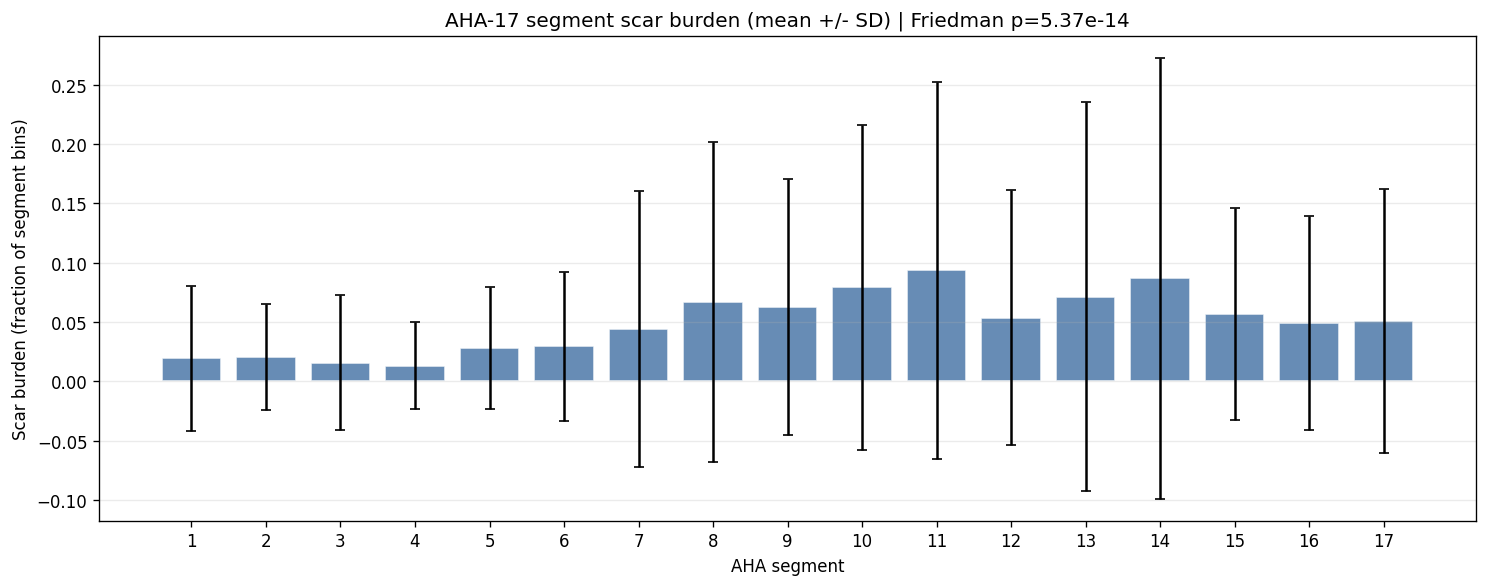

Saved aha17_within_patient_friedman.png
Saved aha17_segment_comparison_ranked.csv and aha17_pairwise_wilcoxon_bonferroni.csv


In [78]:
aha_complete = seg_df.dropna(subset=SEG_COLS).copy()
if len(aha_complete) >= 3:
    aha_values = [aha_complete[col].to_numpy(dtype=float) for col in SEG_COLS]
    aha_fr_stat, aha_fr_p = friedmanchisquare(*aha_values)

    aha_segment_comparison = seg_summary[['segment', 'label', 'mean_extent_all', 'sd_extent_all',
                                           'median_extent_all', 'pct_with_scar']].copy()
    aha_segment_comparison = aha_segment_comparison.sort_values('mean_extent_all', ascending=False)

    print(f'AHA-17 within-patient Friedman test: chi2={aha_fr_stat:.2f}, p={aha_fr_p:.4g}, n={len(aha_complete)}')
    print('Null hypothesis: all 17 AHA segments have the same scar-burden distribution.')
    print('Interpretation: small p-value => scar burden is spatially non-uniform across AHA segments.')
    display(aha_segment_comparison)

    pair_rows = []
    for ii, (seg_i, col_i) in enumerate(zip(SEGMENTS, SEG_COLS)):
        for seg_j, col_j in zip(SEGMENTS[ii + 1:], SEG_COLS[ii + 1:]):
            x = aha_complete[col_i].to_numpy(dtype=float)
            y = aha_complete[col_j].to_numpy(dtype=float)
            diff = x - y
            if np.allclose(diff, 0):
                stat, p_pair = 0.0, 1.0
            else:
                stat, p_pair = wilcoxon(x, y, zero_method='zsplit', alternative='two-sided')
            pair_rows.append({
                'segment_a': seg_i,
                'label_a': SEG_LABELS[seg_i],
                'segment_b': seg_j,
                'label_b': SEG_LABELS[seg_j],
                'mean_diff_a_minus_b': float(np.nanmean(diff)),
                'wilcoxon_stat': stat,
                'p_uncorrected': p_pair,
            })
    aha_pairwise = pd.DataFrame(pair_rows)
    n_pairs = len(aha_pairwise)
    aha_pairwise['p_bonferroni'] = np.minimum(aha_pairwise['p_uncorrected'] * n_pairs, 1.0)
    aha_pairwise['significant_bonf_0_05'] = aha_pairwise['p_bonferroni'] < 0.05

    fig_aha_cmp, ax_aha_cmp = plt.subplots(figsize=(12.5, 5.0), constrained_layout=True)
    plot_df = seg_summary.sort_values('segment')
    ax_aha_cmp.bar(plot_df['segment'], plot_df['mean_extent_all'],
                   yerr=plot_df['sd_extent_all'], capsize=3,
                   color='#4c78a8', edgecolor='white', alpha=0.85)
    ax_aha_cmp.set_xticks(SEGMENTS)
    ax_aha_cmp.set_xlabel('AHA segment')
    ax_aha_cmp.set_ylabel('Scar burden (fraction of segment bins)')
    ax_aha_cmp.set_title(f'AHA-17 segment scar burden (mean +/- SD) | Friedman p={aha_fr_p:.3g}')
    ax_aha_cmp.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT / 'aha17_within_patient_friedman.png', bbox_inches='tight', dpi=150)
    plt.show()

    aha_segment_comparison.to_csv(OUT / 'aha17_segment_comparison_ranked.csv', index=False)
    aha_pairwise.to_csv(OUT / 'aha17_pairwise_wilcoxon_bonferroni.csv', index=False)
    print('Saved aha17_within_patient_friedman.png')
    print('Saved aha17_segment_comparison_ranked.csv and aha17_pairwise_wilcoxon_bonferroni.csv')
else:
    print(f'Skipping AHA-17 Friedman test: only {len(aha_complete)} complete patient vectors available.')

### 3.4 Analysis 1 - Population Scar Atlas and Bootstrap Confidence Intervals

The atlas maps the average scar burden per AHA segment across patients.

Bootstrap is used because scar burden is bounded, sparse, and non-normal. "Resampling 84 patients with replacement" means each bootstrap sample has the same size as the cohort, but patients are sampled randomly from the observed cohort and a patient can appear more than once while another can be absent. For each resample, the mean scar burden is recomputed. After 2000 resamples, the 2.5th and 97.5th percentiles form the 95% confidence interval.

So `Bootstrap CI lower/upper` is not a new scar map from another dataset; it is the uncertainty range around the estimated population mean segment burden.

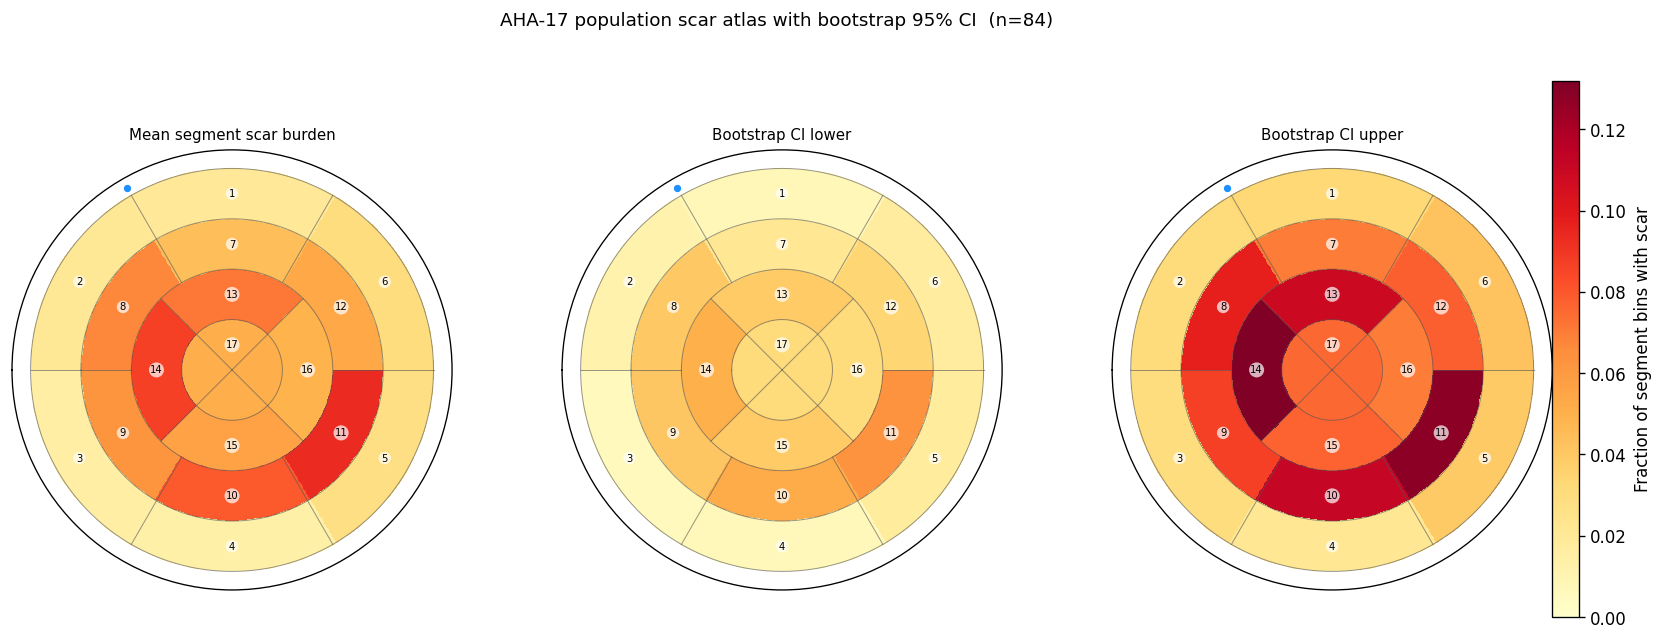

Saved aha17_population_scar_atlas_bootstrap_ci.png


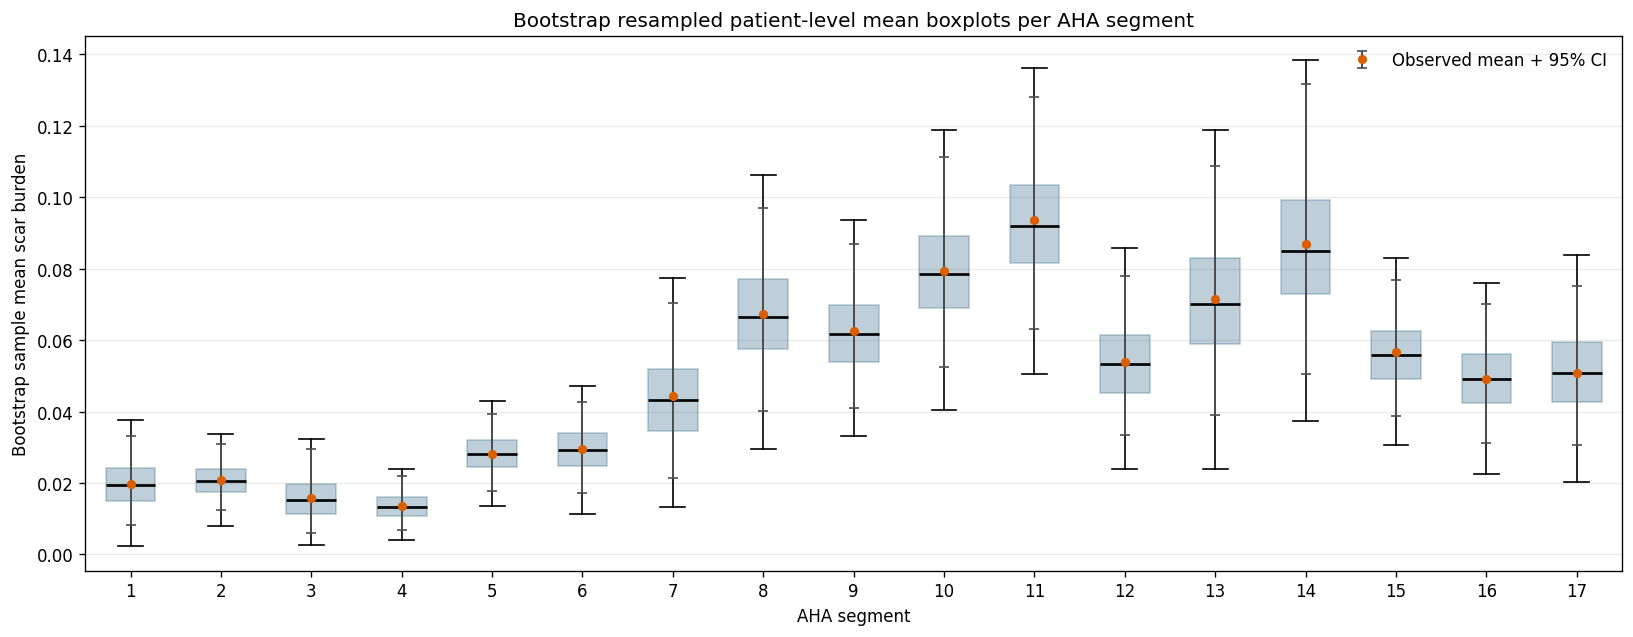

Saved aha17_bootstrap_sample_distributions.png and aha17_bootstrap_sample_means.csv


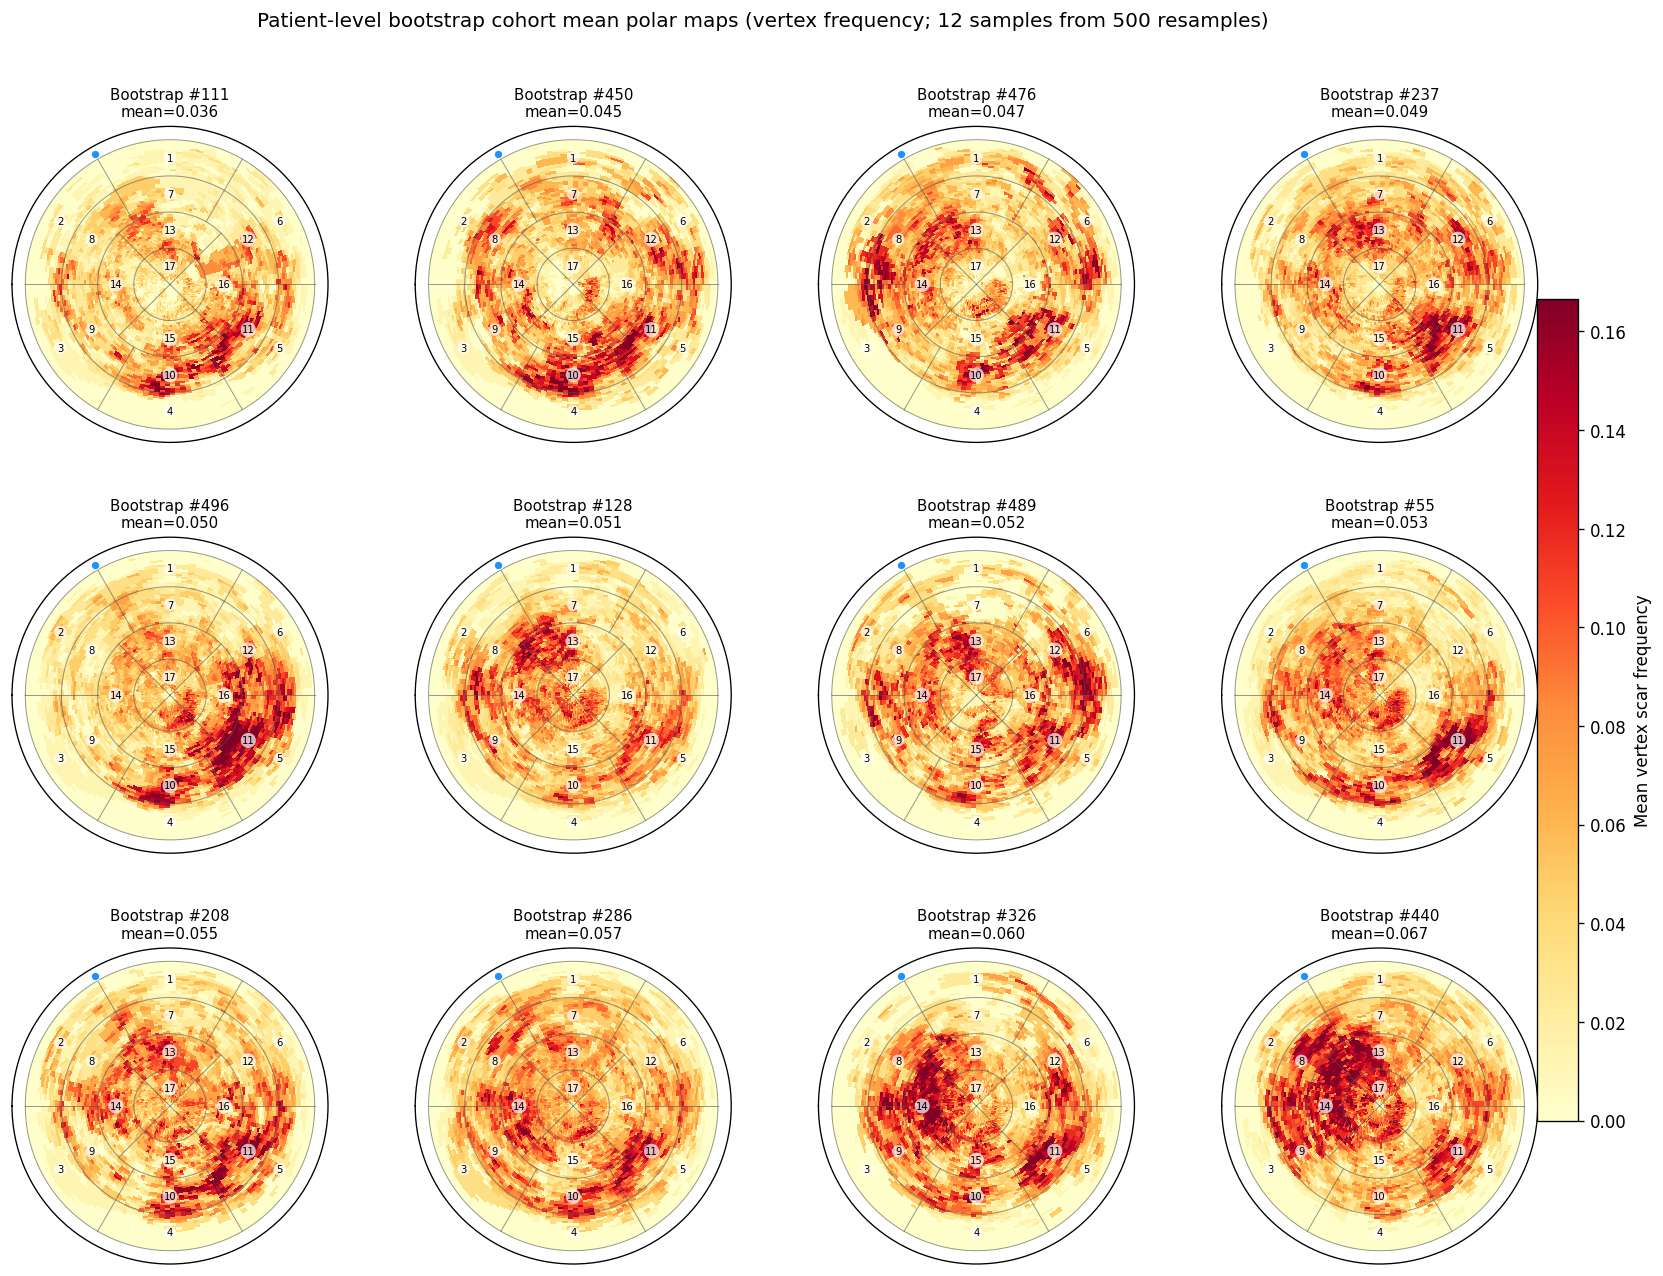

Saved aha17_bootstrap_sample_polar_maps.png


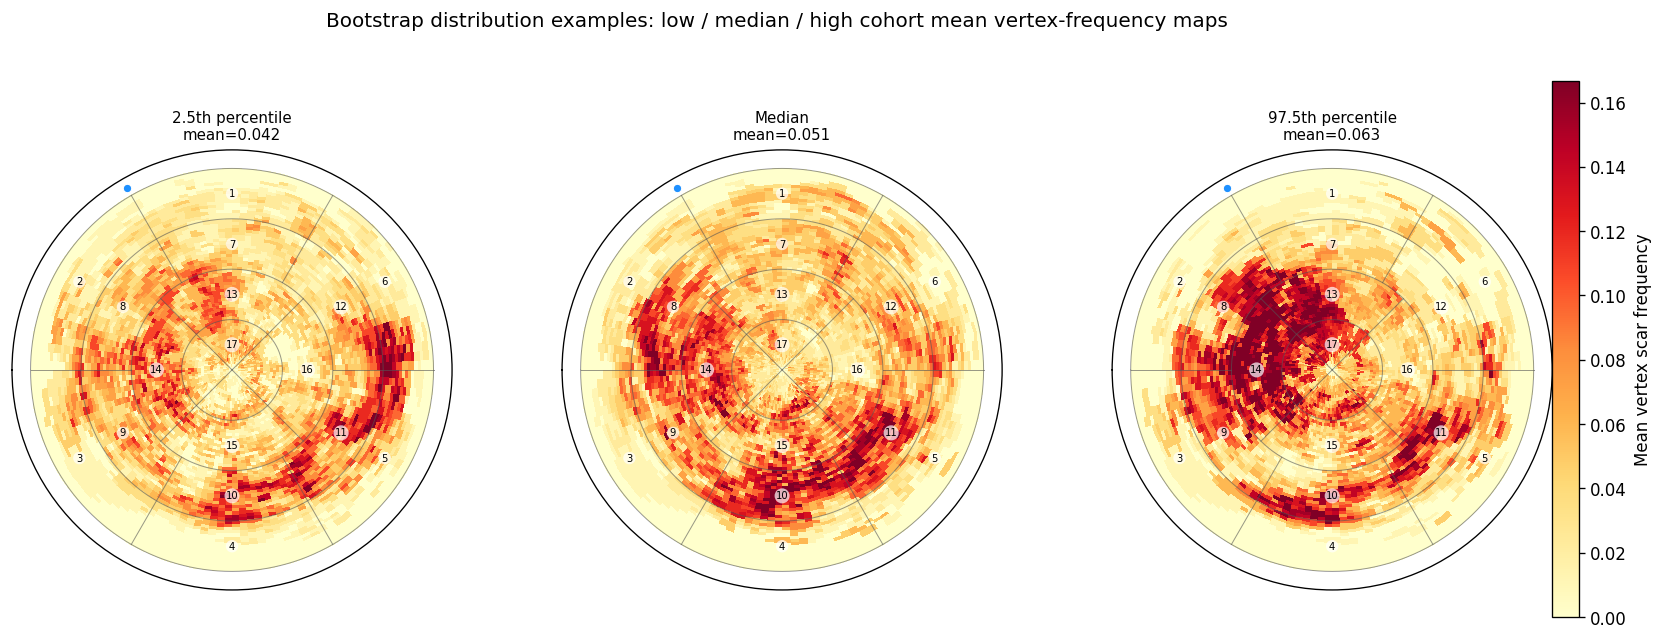

Saved aha17_bootstrap_percentile_polar_maps.png


In [79]:
def bootstrap_samples(data, statistic=np.nanmean, n_boot=2000, rng=None):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if data.size == 0:
        return np.array([])
    rng = np.random.default_rng(42) if rng is None else rng
    idx = rng.integers(0, data.size, size=(n_boot, data.size))
    return np.apply_along_axis(statistic, 1, data[idx])


def bootstrap_ci(data, statistic=np.nanmean, n_boot=2000, ci=95, rng=None):
    boot = bootstrap_samples(data, statistic=statistic, n_boot=n_boot, rng=rng)
    if boot.size == 0:
        return np.nan, np.nan
    alpha = (100 - ci) / 2
    return tuple(np.nanpercentile(boot, [alpha, 100 - alpha]))


rng_boot = np.random.default_rng(42)
seg_boot = []
seg_boot_samples = {}
for seg, col in zip(SEGMENTS, SEG_COLS):
    vals = seg_df[col].to_numpy(dtype=float)
    boot_vals = bootstrap_samples(vals, np.nanmean, n_boot=2000, rng=rng_boot)
    lo, hi = tuple(np.nanpercentile(boot_vals, [2.5, 97.5])) if boot_vals.size else (np.nan, np.nan)
    seg_boot_samples[seg] = boot_vals
    seg_boot.append({'segment': seg, 'mean_extent': np.nanmean(vals), 'ci95_low': lo, 'ci95_high': hi})
seg_boot = pd.DataFrame(seg_boot)
seg_summary = seg_summary.merge(seg_boot, on='segment', how='left')

atlas_grid = np.zeros_like(AHA_GRID, dtype=float)
ci_low_grid = np.zeros_like(AHA_GRID, dtype=float)
ci_high_grid = np.zeros_like(AHA_GRID, dtype=float)
for _, row in seg_boot.iterrows():
    mask = (AHA_GRID == int(row['segment']))
    atlas_grid[mask] = row['mean_extent']
    ci_low_grid[mask] = row['ci95_low']
    ci_high_grid[mask] = row['ci95_high']

fig_atlas, axes_atlas = plt.subplots(1, 3, figsize=(17, 5.8), subplot_kw={'projection': 'polar'})
fig_atlas.suptitle(f'AHA-17 population scar atlas with bootstrap 95% CI  (n={len(seg_df)})', fontsize=11)
vmax_atlas = max(float(np.nanmax(ci_high_grid)), 1e-9)
for ax, arr, title in zip(
    axes_atlas,
    [atlas_grid, ci_low_grid, ci_high_grid],
    ['Mean segment scar burden', 'Bootstrap CI lower', 'Bootstrap CI upper'],
):
    m = draw_bullseye_m04(arr, ax, title=title, cmap=SCAR_CMAP, vmax=vmax_atlas, label_segs=True)
plt.colorbar(m, ax=axes_atlas, fraction=0.026, pad=0.08, label='Fraction of segment bins with scar')
fig_atlas.subplots_adjust(top=0.82, right=0.88, wspace=0.25)
plt.savefig(OUT / 'aha17_population_scar_atlas_bootstrap_ci.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved aha17_population_scar_atlas_bootstrap_ci.png')

boot_sample_df = pd.DataFrame({f'seg_{seg:02d}': vals for seg, vals in seg_boot_samples.items()})
fig_boot, ax_boot = plt.subplots(figsize=(13.5, 5.2), constrained_layout=True)
_box_data = [np.asarray(seg_boot_samples[seg], dtype=float) for seg in SEGMENTS]
bp = ax_boot.boxplot(_box_data, positions=SEGMENTS, widths=0.55, patch_artist=True,
                     showfliers=False, medianprops=dict(color='black', lw=1.6),
                     boxprops=dict(linewidth=1.0), whiskerprops=dict(linewidth=1.0),
                     capprops=dict(linewidth=1.0))
for patch in bp['boxes']:
    patch.set_facecolor(NOTEBOOK_PALETTE['primary'])
    patch.set_alpha(0.32)
    patch.set_edgecolor(NOTEBOOK_PALETTE['primary'])

# Observed mean and 95% bootstrap CI are overlaid on top of the boxplots.
ax_boot.errorbar(seg_boot['segment'], seg_boot['mean_extent'],
                 yerr=[seg_boot['mean_extent'] - seg_boot['ci95_low'],
                       seg_boot['ci95_high'] - seg_boot['mean_extent']],
                 fmt='o', color=NOTEBOOK_PALETTE['accent'],
                 ecolor=NOTEBOOK_PALETTE['neutral'], elinewidth=1.2,
                 capsize=3, markersize=4.5, label='Observed mean + 95% CI')
ax_boot.set_xticks(SEGMENTS)
ax_boot.set_xlabel('AHA segment')
ax_boot.set_ylabel('Bootstrap sample mean scar burden')
ax_boot.set_title('Bootstrap resampled patient-level mean boxplots per AHA segment')
ax_boot.grid(axis='y', alpha=0.25)
ax_boot.legend(frameon=False)
plt.savefig(OUT / 'aha17_bootstrap_sample_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
boot_sample_df.to_csv(OUT / 'aha17_bootstrap_sample_means.csv', index=False)
print('Saved aha17_bootstrap_sample_distributions.png and aha17_bootstrap_sample_means.csv')

# Patient-level bootstrap polar-map samples: each panel is one resampled cohort mean vertex-frequency map.
_boot_map_rng = np.random.default_rng(123)
_boot_map_n = 500
_pmap_keys_boot = list(pmaps.keys()) if 'pmaps' in globals() else []
if _pmap_keys_boot:
    _pmap_stack_boot = np.stack([np.asarray(pmaps[k], dtype=float) for k in _pmap_keys_boot], axis=0)
    _boot_idx = _boot_map_rng.integers(0, _pmap_stack_boot.shape[0],
                                       size=(_boot_map_n, _pmap_stack_boot.shape[0]))
    _boot_mean_maps = np.stack([_pmap_stack_boot[_idx].mean(axis=0) for _idx in _boot_idx], axis=0)
    _boot_total_mean = _boot_mean_maps.mean(axis=(1, 2))

    _sample_order = np.argsort(_boot_total_mean)
    _sample_positions = np.linspace(0, _boot_map_n - 1, 12).astype(int)
    _sample_ids = _sample_order[_sample_positions]
    _boot_maps = [(_bi, _boot_mean_maps[_bi], _boot_total_mean[_bi]) for _bi in _sample_ids]

    _positive_boot = _boot_mean_maps[np.isfinite(_boot_mean_maps) & (_boot_mean_maps > 0)]
    _vmax_boot_maps = float(np.nanpercentile(_positive_boot, 99)) if len(_positive_boot) else 1.0
    _vmax_boot_maps = max(_vmax_boot_maps, 0.05)

    fig_boot_maps, axes_boot_maps = plt.subplots(3, 4, figsize=(17, 12), subplot_kw={'projection': 'polar'})
    fig_boot_maps.suptitle(
        f'Patient-level bootstrap cohort mean polar maps (vertex frequency; 12 samples from {_boot_map_n} resamples)',
        fontsize=12,
    )
    for _ax, (_bi, _g, _tm) in zip(axes_boot_maps.ravel(), _boot_maps):
        _m = draw_bullseye_m04(_g, _ax,
                               title=f'Bootstrap #{_bi}\nmean={_tm:.3f}',
                               cmap=SCAR_CMAP, vmax=_vmax_boot_maps, label_segs=True)
    plt.colorbar(_m, ax=axes_boot_maps.ravel().tolist(), fraction=0.026, pad=0.08,
                 label='Mean vertex scar frequency')
    fig_boot_maps.subplots_adjust(top=0.90, right=0.88, wspace=0.22, hspace=0.30)
    plt.savefig(OUT / 'aha17_bootstrap_sample_polar_maps.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved aha17_bootstrap_sample_polar_maps.png')

    _summary_ids = [_sample_order[int(0.025 * (_boot_map_n - 1))],
                    _sample_order[int(0.500 * (_boot_map_n - 1))],
                    _sample_order[int(0.975 * (_boot_map_n - 1))]]
    fig_boot_q, axes_boot_q = plt.subplots(1, 3, figsize=(17, 5.8), subplot_kw={'projection': 'polar'})
    fig_boot_q.suptitle('Bootstrap distribution examples: low / median / high cohort mean vertex-frequency maps', fontsize=12)
    for _ax, _label, _bi in zip(axes_boot_q, ['2.5th percentile', 'Median', '97.5th percentile'], _summary_ids):
        _m = draw_bullseye_m04(_boot_mean_maps[_bi], _ax,
                               title=f'{_label}\nmean={_boot_total_mean[_bi]:.3f}',
                               cmap=SCAR_CMAP, vmax=_vmax_boot_maps, label_segs=True)
    plt.colorbar(_m, ax=axes_boot_q, fraction=0.026, pad=0.08,
                 label='Mean vertex scar frequency')
    fig_boot_q.subplots_adjust(top=0.82, right=0.88, wspace=0.25)
    plt.savefig(OUT / 'aha17_bootstrap_percentile_polar_maps.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved aha17_bootstrap_percentile_polar_maps.png')
else:
    print('No vertex polar maps available for bootstrap polar-map samples.')


## Section 4 - Statistical Analysis

### 4.1 Normality Diagnostics

This section documents whether parametric assumptions are plausible for the full-cohort analyses.

Diagnostics included:
- QQ-plots + Shapiro-Wilk for scalar variables: age, total scar, LAD, RCA, LCX.
- Shapiro-Wilk table for all 17 AHA segment variables.
- Multivariate chi-square QQ plots of Mahalanobis distances for the AHA-17 and LAD/RCA/LCX vectors.

Sex-stratified normality checks are omitted from the main inferential workflow because only 5 female patients have labels.

If normality assumptions look poor, non-parametric tests (Spearman, Friedman, Mann-Whitney) should be used as the main evidence.


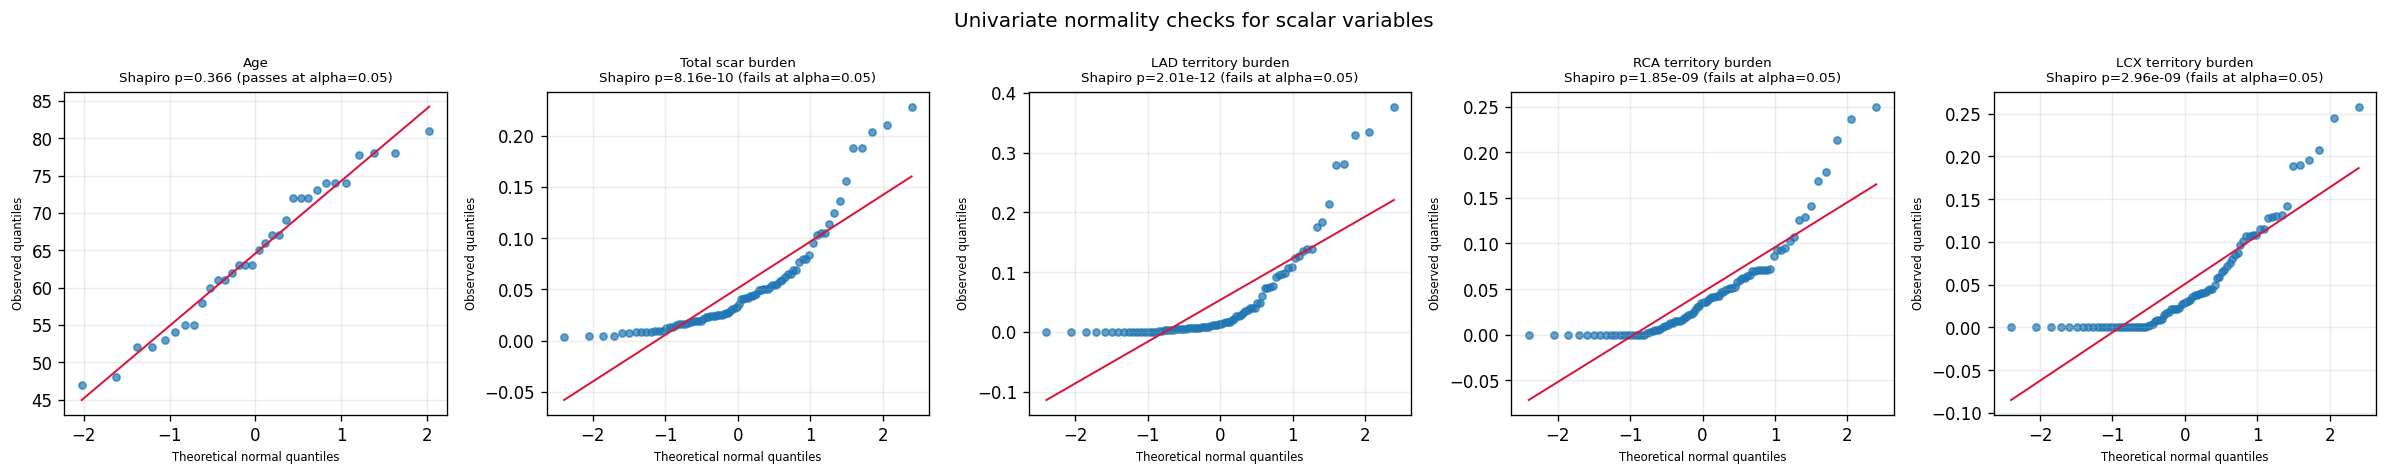

Saved normality_qq_scalar_variables.png
Normality summary (scalar variables + AHA-17 table):


,variable,group,n,shapiro_p,passes_0_05,segment,label
0,age,all,32,3.660392e-01,True,NaN,NaN
1,total_scar,all,84,8.163205e-10,False,NaN,NaN
2,LAD,all,84,2.005276e-12,False,NaN,NaN
3,RCA,all,84,1.853320e-09,False,NaN,NaN
4,LCX,all,84,2.956117e-09,False,NaN,NaN
5,seg_01,all,84,2.897333e-17,False,1.0,bas ant
6,seg_02,all,84,8.847204e-15,False,2.0,bas ant-sep
7,seg_03,all,84,4.444092e-18,False,3.0,bas inf-sep
8,seg_04,all,84,1.177742e-16,False,4.0,bas inf
9,seg_05,all,84,2.449489e-13,False,5.0,bas inf-lat


AHA-17 segments passing Shapiro alpha=0.05: 0 / 17
Saved normality_shapiro_scalar_aha17_summary.csv


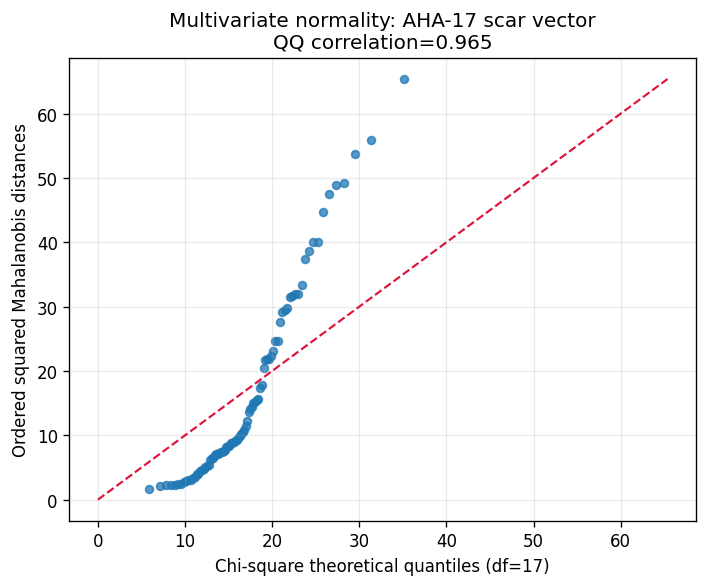

Saved normality_chisquare_aha17.png


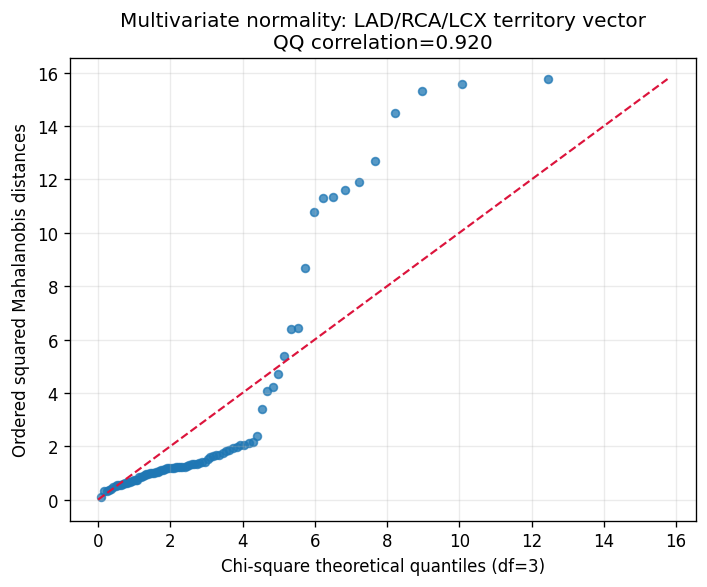

Saved normality_chisquare_territories.png


,analysis,n,p_variables,qq_correlation,status
0,Multivariate normality: AHA-17 scar vector,84,17,0.965362,computed
1,Multivariate normality: LAD/RCA/LCX territory ...,84,3,0.920359,computed


Saved normality_multivariate_summary.csv
Sex-stratified scalar normality checks:


,group,variable,n,shapiro_p,passes_0_05
0,M,total_scar,27,0.000446,False
1,M,LAD,27,0.000079,False
2,M,RCA,27,0.000084,False
3,M,LCX,27,0.001750,False
4,F,total_scar,5,0.000675,False
5,F,LAD,5,0.000187,False
6,F,RCA,5,0.353341,True
7,F,LCX,5,0.342452,True


Saved normality_by_sex_scalar_summary.csv
Descriptive covariance diagnostics for sex-group multivariate tests:


,analysis,n_male,n_female,p_variables,trace_cov_male,trace_cov_female,trace_ratio_larger_over_smaller,regularized_det_male,regularized_det_female,relative_frobenius_cov_difference,status
0,AHA-17 scar vector by sex,27,5,17,0.208783,0.172097,1.213167,1.946630e-44,1.104891e-112,0.903147,descriptive_only
1,LAD/RCA/LCX territory vector by sex,27,5,3,0.012234,0.030195,2.468113,5.345834e-08,3.699366e-09,0.816084,descriptive_only


Saved normality_covariance_diagnostics_by_sex.csv

Decision note: if Shapiro/QQ and covariance diagnostics look poor, use permutation p-values and non-parametric tests as the main results; keep parametric F tests as exploratory summaries.


In [80]:
_NORMALITY_ALPHA = 0.05


def _shapiro_result(values, alpha=_NORMALITY_ALPHA):
    values = pd.Series(values).dropna().astype(float).to_numpy()
    if len(values) < 3:
        return np.nan, len(values), False
    p_val = shapiro(values).pvalue if len(values) <= 5000 else np.nan
    return p_val, len(values), bool(np.isfinite(p_val) and p_val >= alpha)


def _qq_on_axis(ax, values, title, alpha=_NORMALITY_ALPHA):
    values = pd.Series(values).dropna().astype(float).to_numpy()
    if len(values) < 3:
        ax.text(0.5, 0.5, 'n < 3', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return np.nan
    osm, osr = probplot(values, dist='norm', fit=False)
    slope, intercept = np.polyfit(osm, osr, 1)
    ax.scatter(osm, osr, s=18, alpha=0.70)
    ax.plot(osm, slope * np.asarray(osm) + intercept, color='crimson', lw=1.2)
    p_val, _, passes = _shapiro_result(values, alpha=alpha)
    status = 'passes' if passes else 'fails'
    ax.set_title(f'{title}\nShapiro p={p_val:.3g} ({status} at alpha={alpha})', fontsize=8)
    ax.set_xlabel('Theoretical normal quantiles', fontsize=7)
    ax.set_ylabel('Observed quantiles', fontsize=7)
    ax.grid(alpha=0.25)
    return p_val


def _mahalanobis_chisquare_qq(X, title, out_name, variable_names=None, ridge=1e-8):
    X = np.asarray(X, dtype=float)
    X = X[np.isfinite(X).all(axis=1)]
    if X.shape[0] <= X.shape[1] or X.shape[0] < 5:
        print(f'Skipping {title}: n={X.shape[0]} <= p={X.shape[1]} or too few rows')
        return {'analysis': title, 'n': X.shape[0], 'p_variables': X.shape[1], 'status': 'skipped'}

    Xc = X - X.mean(axis=0, keepdims=True)
    cov = np.cov(Xc, rowvar=False)
    scale = np.trace(cov) / max(cov.shape[0], 1)
    cov_reg = cov + np.eye(cov.shape[0]) * ridge * max(scale, 1.0)
    inv_cov = np.linalg.pinv(cov_reg)
    d2 = np.einsum('ij,jk,ik->i', Xc, inv_cov, Xc)
    d2_sorted = np.sort(d2)
    probs = (np.arange(1, len(d2_sorted) + 1) - 0.5) / len(d2_sorted)
    chi_q = chi2.ppf(probs, df=X.shape[1])

    corr = float(np.corrcoef(chi_q, d2_sorted)[0, 1]) if len(d2_sorted) > 2 else np.nan
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(chi_q, d2_sorted, s=22, alpha=0.75)
    lim = max(float(np.nanmax(chi_q)), float(np.nanmax(d2_sorted)))
    ax.plot([0, lim], [0, lim], color='crimson', lw=1.3, ls='--')
    ax.set_xlabel(f'Chi-square theoretical quantiles (df={X.shape[1]})')
    ax.set_ylabel('Ordered squared Mahalanobis distances')
    ax.set_title(f'{title}\nQQ correlation={corr:.3f}')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT / out_name, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved {out_name}')
    return {'analysis': title, 'n': X.shape[0], 'p_variables': X.shape[1],
            'qq_correlation': corr, 'status': 'computed'}


def _covariance_diagnostic(X, labels, label_name):
    labels = np.asarray(labels)
    X = np.asarray(X, dtype=float)
    mask = np.isfinite(X).all(axis=1) & pd.Series(labels).isin(['M', 'F']).to_numpy()
    X = X[mask]
    labels = labels[mask]
    Xm = X[labels == 'M']
    Xf = X[labels == 'F']
    if len(Xm) < 2 or len(Xf) < 2:
        return {'analysis': label_name, 'status': 'skipped', 'reason': 'group n < 2'}
    cov_m = np.atleast_2d(np.cov(Xm, rowvar=False))
    cov_f = np.atleast_2d(np.cov(Xf, rowvar=False))
    trace_m = float(np.trace(cov_m))
    trace_f = float(np.trace(cov_f))
    det_m = float(np.linalg.det(cov_m + np.eye(cov_m.shape[0]) * 1e-8))
    det_f = float(np.linalg.det(cov_f + np.eye(cov_f.shape[0]) * 1e-8))
    frob_diff = float(np.linalg.norm(cov_m - cov_f, ord='fro'))
    frob_rel = frob_diff / max(float(np.linalg.norm(cov_m, ord='fro')), float(np.linalg.norm(cov_f, ord='fro')), 1e-12)
    return {
        'analysis': label_name,
        'n_male': len(Xm),
        'n_female': len(Xf),
        'p_variables': X.shape[1],
        'trace_cov_male': trace_m,
        'trace_cov_female': trace_f,
        'trace_ratio_larger_over_smaller': max(trace_m, trace_f) / max(min(trace_m, trace_f), 1e-12),
        'regularized_det_male': det_m,
        'regularized_det_female': det_f,
        'relative_frobenius_cov_difference': frob_rel,
        'status': 'descriptive_only',
    }


# 4.1a: scalar QQ-plots and Shapiro-Wilk.
scalar_specs = [
    ('age', 'Age', seg_df['age']),
    ('total_scar', 'Total scar burden', seg_df['total_scar']),
    ('LAD', 'LAD territory burden', df['LAD']),
    ('RCA', 'RCA territory burden', df['RCA']),
    ('LCX', 'LCX territory burden', df['LCX']),
]
fig_qq, axes_qq = plt.subplots(1, len(scalar_specs), figsize=(4 * len(scalar_specs), 4))
fig_qq.suptitle('Univariate normality checks for scalar variables', fontsize=12)
normality_rows = []
for ax, (var, title, values) in zip(np.atleast_1d(axes_qq), scalar_specs):
    p_val = _qq_on_axis(ax, values, title)
    _, n_var, passes = _shapiro_result(values)
    normality_rows.append({'variable': var, 'group': 'all', 'n': n_var,
                           'shapiro_p': p_val, 'passes_0_05': passes})
plt.tight_layout()
plt.savefig(OUT / 'normality_qq_scalar_variables.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved normality_qq_scalar_variables.png')

# 4.1b: AHA-17 Shapiro table only.
for seg, col in zip(SEGMENTS, SEG_COLS):
    p_val, n_var, passes = _shapiro_result(seg_df[col])
    normality_rows.append({'variable': col, 'segment': seg, 'label': SEG_LABELS[seg],
                           'group': 'all', 'n': n_var, 'shapiro_p': p_val,
                           'passes_0_05': passes})
normality_summary = pd.DataFrame(normality_rows)
print('Normality summary (scalar variables + AHA-17 table):')
display(normality_summary)
print('AHA-17 segments passing Shapiro alpha=0.05:',
      int(normality_summary[normality_summary['variable'].isin(SEG_COLS)]['passes_0_05'].sum()),
      '/', len(SEG_COLS))
normality_summary.to_csv(OUT / 'normality_shapiro_scalar_aha17_summary.csv', index=False)
print('Saved normality_shapiro_scalar_aha17_summary.csv')

# 4.1c: multivariate normality diagnostics.
mv_rows = []
mv_rows.append(_mahalanobis_chisquare_qq(seg_df[SEG_COLS].to_numpy(dtype=float),
                                         'Multivariate normality: AHA-17 scar vector',
                                         'normality_chisquare_aha17.png'))
mv_rows.append(_mahalanobis_chisquare_qq(df[['LAD', 'RCA', 'LCX']].to_numpy(dtype=float),
                                         'Multivariate normality: LAD/RCA/LCX territory vector',
                                         'normality_chisquare_territories.png'))
multivariate_normality_summary = pd.DataFrame(mv_rows)
display(multivariate_normality_summary)
multivariate_normality_summary.to_csv(OUT / 'normality_multivariate_summary.csv', index=False)
print('Saved normality_multivariate_summary.csv')

# 4.1d: sex-stratified scalar normality checks.
sex_norm_rows = []
if 'sex' in df.columns and df['sex'].notna().any():
    for group_label, group_df in [('M', df[df['sex'] == 'M']), ('F', df[df['sex'] == 'F'])]:
        for var in ['total_scar', 'LAD', 'RCA', 'LCX']:
            p_val, n_var, passes = _shapiro_result(group_df[var])
            sex_norm_rows.append({'group': group_label, 'variable': var, 'n': n_var,
                                  'shapiro_p': p_val, 'passes_0_05': passes})
sex_group_normality = pd.DataFrame(sex_norm_rows)
print('Sex-stratified scalar normality checks:')
display(sex_group_normality)
sex_group_normality.to_csv(OUT / 'normality_by_sex_scalar_summary.csv', index=False)
print('Saved normality_by_sex_scalar_summary.csv')

# 4.1e: covariance diagnostics for parametric Hotelling/MANOVA-style tests.
cov_rows = []
sex_seg_for_cov = seg_df.dropna(subset=['sex']).copy()
sex_seg_for_cov = sex_seg_for_cov[sex_seg_for_cov['sex'].isin(['M', 'F'])]
if len(sex_seg_for_cov):
    cov_rows.append(_covariance_diagnostic(sex_seg_for_cov[SEG_COLS].to_numpy(dtype=float),
                                           sex_seg_for_cov['sex'].to_numpy(),
                                           'AHA-17 scar vector by sex'))
sex_df_for_cov = df.dropna(subset=['sex']).copy()
sex_df_for_cov = sex_df_for_cov[sex_df_for_cov['sex'].isin(['M', 'F'])]
if len(sex_df_for_cov):
    cov_rows.append(_covariance_diagnostic(sex_df_for_cov[['LAD', 'RCA', 'LCX']].to_numpy(dtype=float),
                                           sex_df_for_cov['sex'].to_numpy(),
                                           'LAD/RCA/LCX territory vector by sex'))
covariance_diagnostics = pd.DataFrame(cov_rows)
print('Descriptive covariance diagnostics for sex-group multivariate tests:')
display(covariance_diagnostics)
covariance_diagnostics.to_csv(OUT / 'normality_covariance_diagnostics_by_sex.csv', index=False)
print('Saved normality_covariance_diagnostics_by_sex.csv')

print('\nDecision note: if Shapiro/QQ and covariance diagnostics look poor, use permutation p-values and non-parametric tests as the main results; keep parametric F tests as exploratory summaries.')

### 4.2 Vertex Count-Based Statistical Analysis

This block uses the binary polar-map representation: each bin is counted as scar-positive or scar-negative. Burden is therefore expressed as a fraction of positive bins.

#### 4.2.1 Vertex Count-Based Age Effects Across AHA-17 Segments


,segment,label,n,spearman_rho,p_uncorrected,p_bonferroni,significant_bonf_0_05
0,1,bas ant,32,0.118870,0.516999,1.000000,False
1,2,bas ant-sep,32,0.094898,0.605410,1.000000,False
2,3,bas inf-sep,32,0.062261,0.734972,1.000000,False
3,4,bas inf,32,0.038882,0.832670,1.000000,False
4,5,bas inf-lat,32,0.365786,0.039510,0.671670,False
5,6,bas ant-lat,32,0.296382,0.099531,1.000000,False
6,7,mid ant,32,0.142769,0.435688,1.000000,False
7,8,mid ant-sep,32,0.133839,0.465219,1.000000,False
8,9,mid inf-sep,32,0.144337,0.430611,1.000000,False
9,10,mid inf,32,0.286885,0.111391,1.000000,False


Bonferroni alpha: 0.0029
Saved age_spearman_aha17.csv


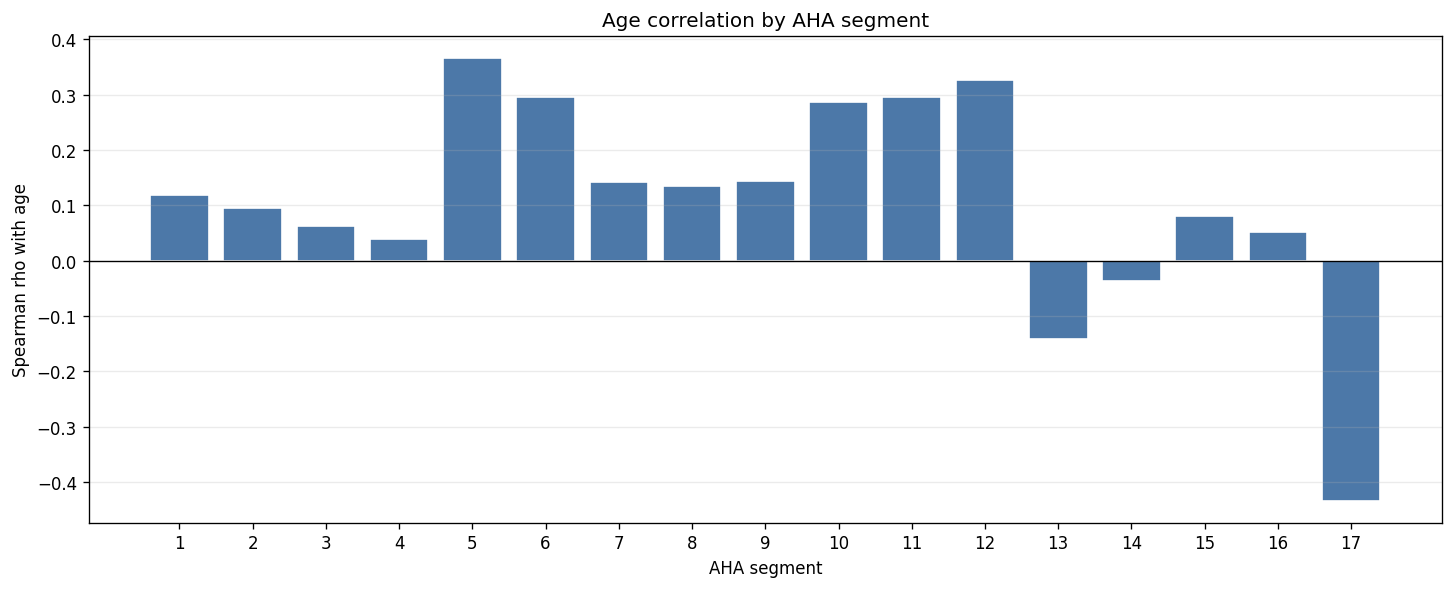

Saved age_spearman_aha17.png


,segment,label,median_age_cut,young_mean,old_mean,mannwhitney_p,p_bonferroni
0,1,bas ant,64.0,0.028232,0.026634,0.757378,1.00000
1,2,bas ant-sep,64.0,0.017485,0.024740,0.474490,1.00000
2,3,bas inf-sep,64.0,0.011161,0.023065,0.617807,1.00000
3,4,bas inf,64.0,0.009943,0.011896,0.908686,1.00000
4,5,bas inf-lat,64.0,0.011905,0.020089,0.089425,1.00000
5,6,bas ant-lat,64.0,0.010045,0.042783,0.024802,0.42163
6,7,mid ant,64.0,0.035866,0.014027,0.447964,1.00000
7,8,mid ant-sep,64.0,0.056920,0.113281,0.165859,1.00000
8,9,mid inf-sep,64.0,0.061570,0.127976,0.120996,1.00000
9,10,mid inf,64.0,0.037997,0.112749,0.215273,1.00000


Saved age_median_split_mannwhitney_aha17.csv


In [81]:
age_seg = seg_df.dropna(subset=['age']).copy()
age_results = []
alpha_age = 0.05 / len(SEG_COLS)
for seg, col in zip(SEGMENTS, SEG_COLS):
    sub = age_seg[['age', col]].dropna()
    if len(sub) >= 3:
        rho, p_s = spearmanr(sub['age'], sub[col])
    else:
        rho, p_s = np.nan, np.nan
    age_results.append({
        'segment': seg,
        'label': SEG_LABELS[seg],
        'n': len(sub),
        'spearman_rho': rho,
        'p_uncorrected': p_s,
        'p_bonferroni': min(p_s * len(SEG_COLS), 1.0) if np.isfinite(p_s) else np.nan,
        'significant_bonf_0_05': bool(np.isfinite(p_s) and p_s < alpha_age),
    })
age_results = pd.DataFrame(age_results)
display(age_results)
age_results.to_csv(OUT / 'age_spearman_aha17.csv', index=False)
print(f'Bonferroni alpha: {alpha_age:.4f}')
print('Saved age_spearman_aha17.csv')

fig_age17, ax_age17 = plt.subplots(figsize=(12, 4.8), constrained_layout=True)
ax_age17.bar(age_results['segment'], age_results['spearman_rho'], color='#4c78a8', edgecolor='white')
ax_age17.axhline(0, color='black', lw=0.8)
ax_age17.set_xticks(SEGMENTS)
ax_age17.set_xlabel('AHA segment')
ax_age17.set_ylabel('Spearman rho with age')
ax_age17.set_title('Age correlation by AHA segment')
ax_age17.grid(axis='y', alpha=0.25)
plt.savefig(OUT / 'age_spearman_aha17.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved age_spearman_aha17.png')

if len(age_seg) >= 6:
    median_age = age_seg['age'].median()
    age_seg['age_group_median'] = np.where(age_seg['age'] <= median_age, 'younger_or_equal_median', 'older_than_median')
    age_split_rows = []
    for seg, col in zip(SEGMENTS, SEG_COLS):
        young = age_seg.loc[age_seg['age_group_median'] == 'younger_or_equal_median', col].dropna().to_numpy(dtype=float)
        old = age_seg.loc[age_seg['age_group_median'] == 'older_than_median', col].dropna().to_numpy(dtype=float)
        if len(young) and len(old):
            u, p_u = mannwhitneyu(young, old, alternative='two-sided')
        else:
            u, p_u = np.nan, np.nan
        age_split_rows.append({
            'segment': seg,
            'label': SEG_LABELS[seg],
            'median_age_cut': median_age,
            'young_mean': np.nanmean(young) if len(young) else np.nan,
            'old_mean': np.nanmean(old) if len(old) else np.nan,
            'mannwhitney_p': p_u,
            'p_bonferroni': min(p_u * len(SEG_COLS), 1.0) if np.isfinite(p_u) else np.nan,
        })
    age_split_results = pd.DataFrame(age_split_rows)
    display(age_split_results)
    age_split_results.to_csv(OUT / 'age_median_split_mannwhitney_aha17.csv', index=False)
    print('Saved age_median_split_mannwhitney_aha17.csv')

#### 4.2.2 Vertex Count-Based PCA of AHA-17 Scar Vectors


,component,explained_variance_ratio,cumulative_variance_ratio
0,PC1,0.182674,0.182674
1,PC2,0.150630,0.333304
2,PC3,0.144430,0.477733
3,PC4,0.108988,0.586722
4,PC5,0.079413,0.666134
5,PC6,0.064736,0.730871


,segment,label,PC1,PC2,PC3,PC4,PC5,PC6
seg_01,1,bas ant,-0.089159,0.468211,0.099657,-0.208854,0.020816,-0.218026
seg_02,2,bas ant-sep,-0.075719,0.379180,0.175402,-0.290677,-0.248782,-0.142620
seg_03,3,bas inf-sep,-0.076887,-0.096093,0.044284,-0.333011,0.054696,-0.279296
seg_04,4,bas inf,-0.072125,-0.203429,0.205479,-0.307848,0.458080,0.269306
seg_05,5,bas inf-lat,-0.251702,-0.035018,0.238649,-0.037578,0.167657,0.559702
seg_06,6,bas ant-lat,-0.287597,0.383033,0.169446,0.004547,-0.127962,0.217425
seg_07,7,mid ant,0.088300,0.402870,-0.135717,-0.000023,0.502178,-0.125252
seg_08,8,mid ant-sep,0.420826,0.188219,0.155430,-0.232895,0.059866,0.093848
seg_09,9,mid inf-sep,0.271606,0.030736,0.241480,-0.298038,-0.325270,-0.053401
seg_10,10,mid inf,-0.078164,-0.196815,0.449088,-0.233787,0.278263,-0.192097


C:\Users\joan\AppData\Local\Temp\ipykernel_20000\2848178916.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


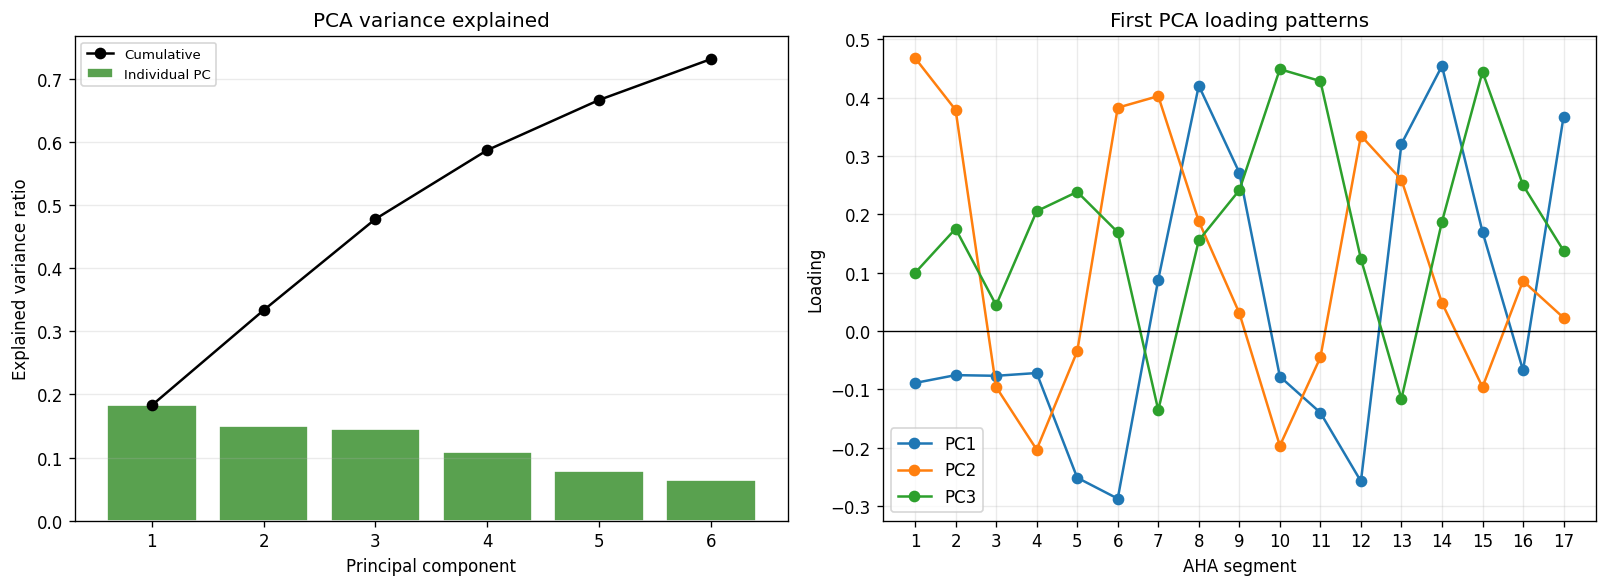

Saved pca_aha17_variance_loadings.png


C:\Users\joan\AppData\Local\Temp\ipykernel_20000\2848178916.py:55: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


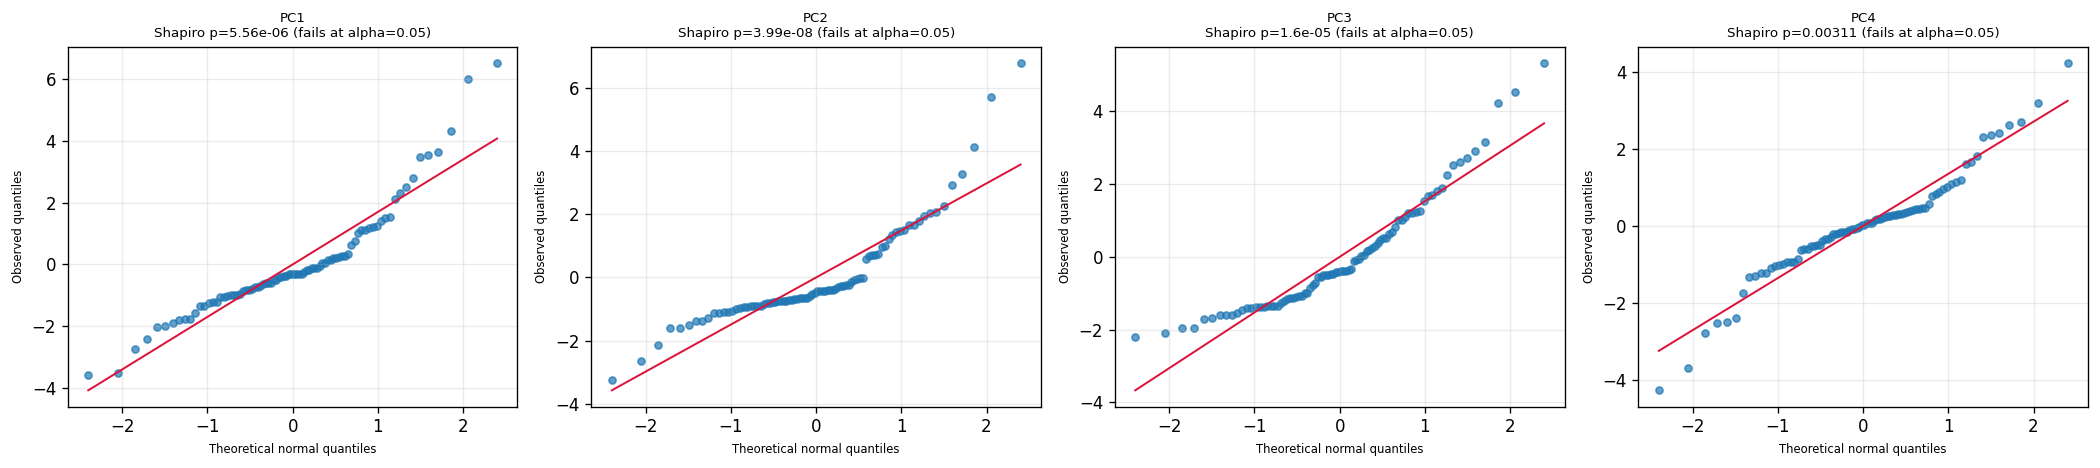

Saved pca_scores_qq.png


,component,shapiro_p,passes_0_05
0,PC1,5.557286e-06,False
1,PC2,3.989622e-08,False
2,PC3,1.595844e-05,False
3,PC4,3.107794e-03,False


,component,sex_ttest_p,sex_mannwhitney_p,male_mean,female_mean,age_spearman_rho,age_spearman_p
0,PC1,0.686589,0.614244,0.163964,0.595368,-0.251675,0.164671
1,PC2,0.058345,0.724635,0.127169,-0.493652,-0.012116,0.947527
2,PC3,0.362535,0.417984,0.148313,-0.507089,0.151629,0.407430
3,PC4,0.641380,0.724635,-0.188484,0.027903,-0.201928,0.267735


Saved pca CSV summaries


In [82]:
pca_df = seg_df.dropna(subset=SEG_COLS).copy()
if len(pca_df) >= 3:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(pca_df[SEG_COLS].to_numpy(dtype=float))
    n_components = min(6, X_scaled.shape[0], X_scaled.shape[1])
    pca = PCA(n_components=n_components, random_state=42)
    scores = pca.fit_transform(X_scaled)
    pc_cols = [f'PC{i+1}' for i in range(n_components)]
    for i, col in enumerate(pc_cols):
        pca_df[col] = scores[:, i]

    pca_var = pd.DataFrame({
        'component': pc_cols,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'cumulative_variance_ratio': np.cumsum(pca.explained_variance_ratio_),
    })
    loadings = pd.DataFrame(pca.components_.T, index=SEG_COLS, columns=pc_cols)
    loadings.insert(0, 'segment', SEGMENTS)
    loadings.insert(1, 'label', [SEG_LABELS[s] for s in SEGMENTS])
    display(pca_var)
    display(loadings)
    pca_var.to_csv(OUT / 'pca_explained_variance_aha17.csv', index=False)
    loadings.to_csv(OUT / 'pca_loadings_aha17.csv', index=False)

    fig_pca, axes_pca = plt.subplots(1, 2, figsize=(13.5, 5.0), constrained_layout=True)
    axes_pca[0].bar(np.arange(1, n_components + 1), pca.explained_variance_ratio_, color='#59a14f', edgecolor='white', label='Individual PC')
    axes_pca[0].plot(np.arange(1, n_components + 1), np.cumsum(pca.explained_variance_ratio_), color='black', marker='o', label='Cumulative')
    axes_pca[0].set_xlabel('Principal component')
    axes_pca[0].set_ylabel('Explained variance ratio')
    axes_pca[0].set_title('PCA variance explained')
    axes_pca[0].legend(fontsize=8)
    axes_pca[0].grid(axis='y', alpha=0.25)

    for pc in pc_cols[:3]:
        axes_pca[1].plot(SEGMENTS, loadings[pc], marker='o', label=pc)
    axes_pca[1].axhline(0, color='black', lw=0.8)
    axes_pca[1].set_xticks(SEGMENTS)
    axes_pca[1].set_xlabel('AHA segment')
    axes_pca[1].set_ylabel('Loading')
    axes_pca[1].set_title('First PCA loading patterns')
    axes_pca[1].legend()
    axes_pca[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT / 'pca_aha17_variance_loadings.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved pca_aha17_variance_loadings.png')

    n_qq_pc = min(4, n_components)
    fig_pcqq, axes_pcqq = plt.subplots(1, n_qq_pc, figsize=(4.4 * n_qq_pc, 4.0), constrained_layout=True)
    axes_pcqq = np.atleast_1d(axes_pcqq)
    pc_norm_rows = []
    for ax, pc in zip(axes_pcqq, pc_cols[:n_qq_pc]):
        p_sh = _qq_on_axis(ax, pca_df[pc], pc)
        pc_norm_rows.append({'component': pc, 'shapiro_p': p_sh, 'passes_0_05': p_sh >= 0.05 if np.isfinite(p_sh) else False})
    plt.tight_layout()
    plt.savefig(OUT / 'pca_scores_qq.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved pca_scores_qq.png')
    pca_score_normality = pd.DataFrame(pc_norm_rows)
    display(pca_score_normality)
    pca_score_normality.to_csv(OUT / 'pca_score_normality.csv', index=False)

    pca_tests = []
    for pc in pc_cols[:min(4, n_components)]:
        row = {'component': pc}
        sub_sex = pca_df.dropna(subset=['sex'])
        m = sub_sex.loc[sub_sex['sex'] == 'M', pc].dropna().to_numpy(dtype=float)
        f = sub_sex.loc[sub_sex['sex'] == 'F', pc].dropna().to_numpy(dtype=float)
        if len(m) >= 2 and len(f) >= 2:
            row['sex_ttest_p'] = ttest_ind(m, f, equal_var=False).pvalue
            row['sex_mannwhitney_p'] = mannwhitneyu(m, f, alternative='two-sided').pvalue
            row['male_mean'] = m.mean()
            row['female_mean'] = f.mean()
        age_sub = pca_df[['age', pc]].dropna()
        if len(age_sub) >= 3:
            row['age_spearman_rho'], row['age_spearman_p'] = spearmanr(age_sub['age'], age_sub[pc])
        pca_tests.append(row)
    pca_tests = pd.DataFrame(pca_tests)
    display(pca_tests)
    pca_tests.to_csv(OUT / 'pca_score_sex_age_tests.csv', index=False)
    print('Saved pca CSV summaries')
else:
    print(f'Skipping PCA: only {len(pca_df)} complete AHA vectors available.')

##### 4.2.2.1 PCA Score Multivariate Normality Diagnostic


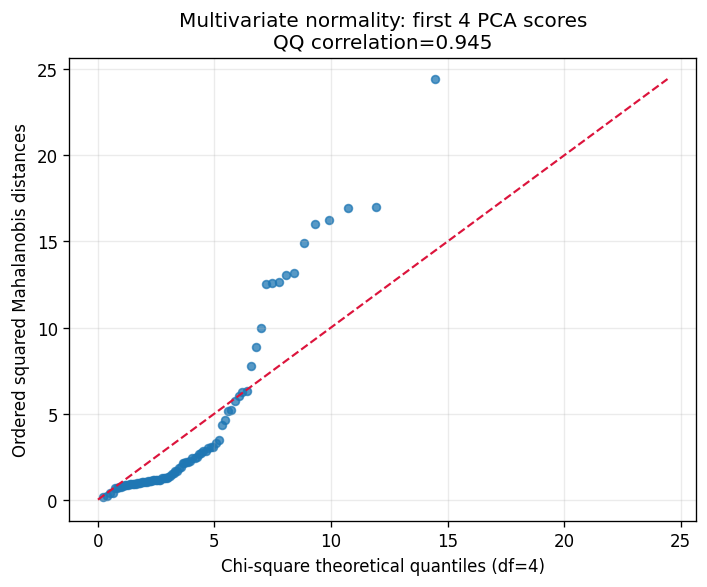

Saved normality_chisquare_pca_scores.png


,analysis,n,p_variables,qq_correlation,status
0,Multivariate normality: first 4 PCA scores,84,4,0.944649,computed


Saved normality_pca_scores_multivariate_summary.csv


In [83]:
if 'pca_df' in globals() and 'pc_cols' in globals() and len(pc_cols) >= 2:
    pca_mv_cols = pc_cols[:min(4, len(pc_cols))]
    pca_mv_summary = pd.DataFrame([
        _mahalanobis_chisquare_qq(pca_df[pca_mv_cols].to_numpy(dtype=float),
                                  f'Multivariate normality: first {len(pca_mv_cols)} PCA scores',
                                  'normality_chisquare_pca_scores.png')
    ])
    display(pca_mv_summary)
    pca_mv_summary.to_csv(OUT / 'normality_pca_scores_multivariate_summary.csv', index=False)
    print('Saved normality_pca_scores_multivariate_summary.csv')
else:
    print('PCA scores not available; run Section 4.4 PCA first.')

##### 4.2.2.2 Vertex Count-Based PCA Score-Group Scar Frequency Maps

For each of the first PCA components, patients are grouped by low, middle, and high PC scores. The panels average the original vertex-level polar maps within each score group, so the visualization shows scar-frequency patterns instead of solid AHA segment blocks.


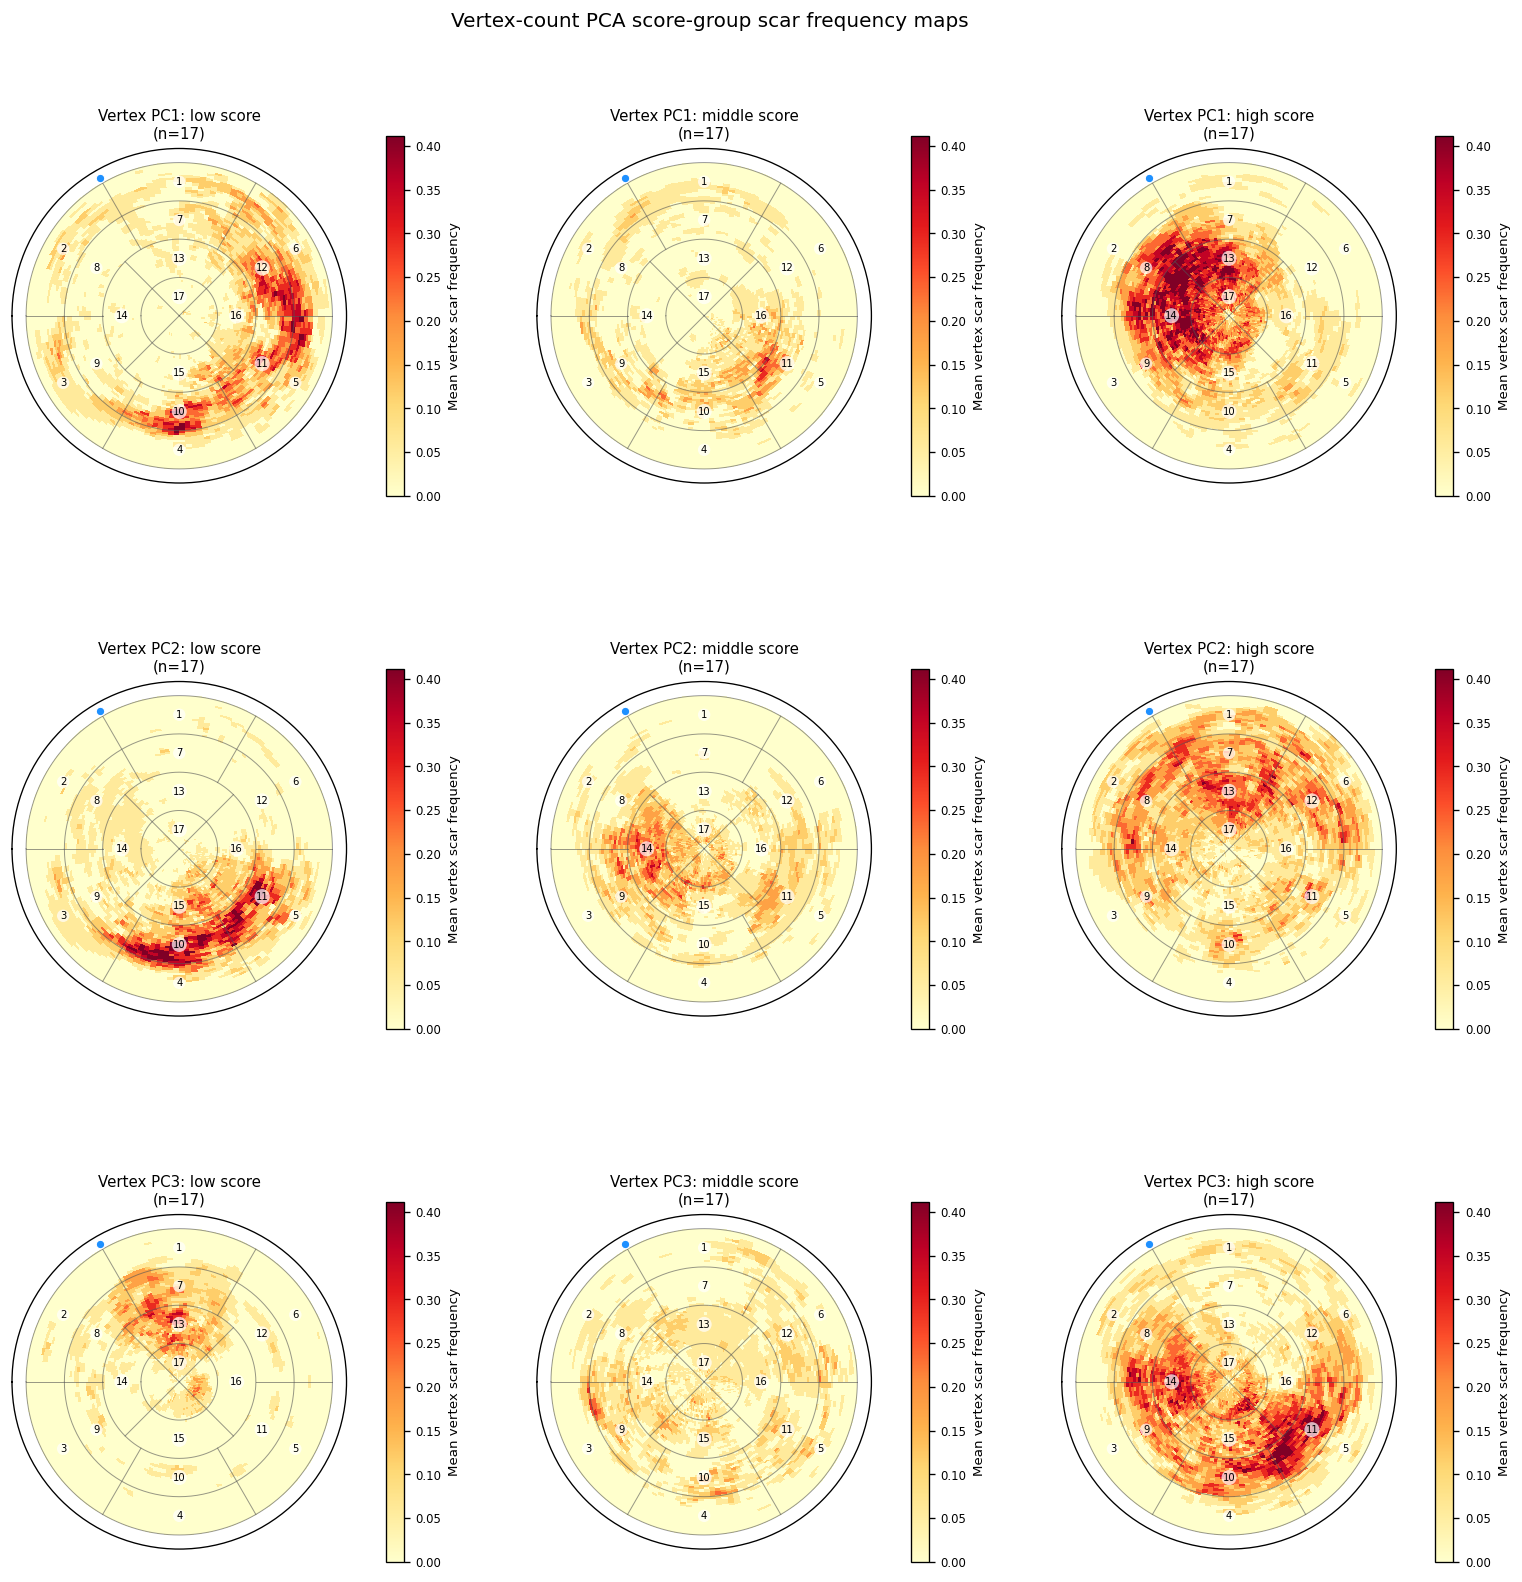

Saved pca_modes_vertex_polar_maps.png


In [84]:
if 'pca' not in globals() or 'scores' not in globals() or 'pca_df' not in globals():
    print('Vertex PCA is not available. Run Section 4.2.2 first.')
elif not pmaps:
    print('No vertex polar maps available for PCA score-group maps.')
else:
    _vertex_mode_rows = min(3, pca.n_components_)
    _score_df = pca_df[['key']].copy() if 'key' in pca_df.columns else pd.DataFrame({'key': list(pmaps.keys())[:len(pca_df)]})
    for _pc_idx in range(_vertex_mode_rows):
        _score_df[f'PC{_pc_idx + 1}'] = scores[:, _pc_idx]

    _group_n = max(3, int(np.ceil(0.20 * len(_score_df))))
    _all_mode_maps, _mode_payload = [], []
    for _pc_idx in range(_vertex_mode_rows):
        _pc = f'PC{_pc_idx + 1}'
        _tmp = _score_df[['key', _pc]].dropna().sort_values(_pc)
        _low_keys = [k for k in _tmp.head(_group_n)['key'] if k in pmaps]
        _high_keys = [k for k in _tmp.tail(_group_n)['key'] if k in pmaps]
        _center_score = float(_tmp[_pc].median())
        _mid_keys = [k for k in _tmp.assign(_dist=(_tmp[_pc] - _center_score).abs())
                       .sort_values('_dist').head(_group_n)['key'] if k in pmaps]
        _groups = [('low score', _low_keys), ('middle score', _mid_keys), ('high score', _high_keys)]
        _maps = []
        for _label, _keys in _groups:
            _arr = np.stack([np.asarray(pmaps[k], dtype=float) for k in _keys], axis=0).mean(axis=0) if _keys else np.full_like(next(iter(pmaps.values())), np.nan, dtype=float)
            _maps.append((_label, _keys, _arr))
            _all_mode_maps.append(_arr)
        _mode_payload.append(_maps)

    _positive_modes = np.concatenate([_m[np.isfinite(_m) & (_m > 0)] for _m in _all_mode_maps if np.isfinite(_m).any()]) if _all_mode_maps else np.array([])
    _vmax_modes = float(np.nanpercentile(_positive_modes, 99)) if len(_positive_modes) else 1.0
    _vmax_modes = max(_vmax_modes, 0.05)

    fig_vertex_modes, axes_vertex_modes = plt.subplots(
        _vertex_mode_rows, 3, figsize=(15.5, 5.0 * _vertex_mode_rows), subplot_kw={'projection': 'polar'})
    axes_vertex_modes = np.atleast_2d(axes_vertex_modes)
    fig_vertex_modes.suptitle('Vertex-count PCA score-group scar frequency maps', fontsize=12)
    for _r, _maps in enumerate(_mode_payload):
        for _c, (_label, _keys, _arr) in enumerate(_maps):
            _m = draw_bullseye_m04(_arr, axes_vertex_modes[_r, _c],
                                   title=f'Vertex PC{_r+1}: {_label}\n(n={len(_keys)})', cmap=SCAR_CMAP,
                                   vmax=_vmax_modes, label_segs=True)
            add_colorbar_m04(_m, axes_vertex_modes[_r, _c], label='Mean vertex scar frequency')
    fig_vertex_modes.subplots_adjust(top=0.92, wspace=0.34, hspace=0.36)
    plt.savefig(OUT / 'pca_modes_vertex_polar_maps.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved pca_modes_vertex_polar_maps.png')


#### 4.2.3 Vertex Count-Based Population-Level Coronary Territory Distributions

This is the coronary-territory version of the scar burden analysis. Each patient has three paired values: LAD, RCA, and LCX burden. The Friedman test asks whether those three within-patient territory distributions are equal.

The bar plot shows the mean burden per territory without SD error bars, while the table/printed summaries still preserve patient-to-patient variability when needed.


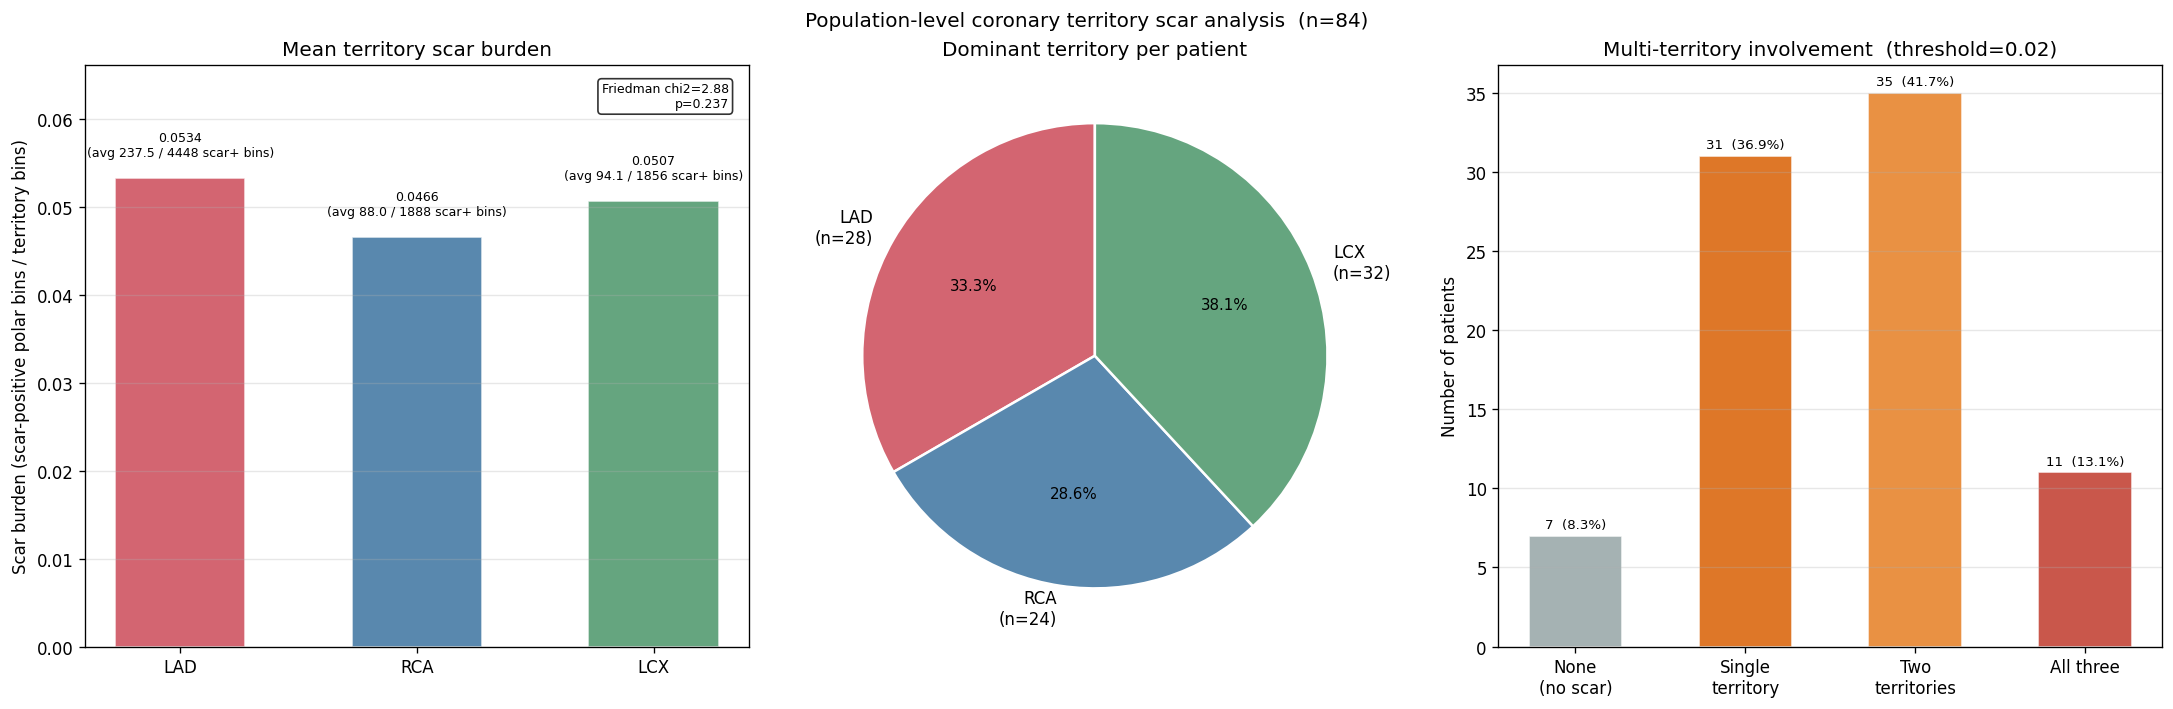

Saved territory_population.png


In [85]:
from scipy.stats import friedmanchisquare

fig, axes = plt.subplots(1, 3, figsize=(18, 5.8), constrained_layout=True)
fig.suptitle(f'Population-level coronary territory scar analysis  (n={len(df)})',
             fontsize=12)

# --- Plot 1: Mean territory burden with numerator/denominator annotations ---
ax = axes[0]
terr_list   = ['LAD', 'RCA', 'LCX']
terr_means  = [df[t].mean()  for t in terr_list]
terr_cols   = [TERR_COLORS[t] for t in terr_list]
bars = ax.bar(terr_list, terr_means,
              color=terr_cols, alpha=0.80, edgecolor='white', width=0.55)
_ymax_mean = max(terr_means) if len(terr_means) else 0
for bar, t, mean in zip(bars, terr_list, terr_means):
    mean_cz_bins = df[f'{t}_cz_bins'].mean()
    denom        = TERR_NBINS[t]
    ax.text(bar.get_x() + bar.get_width() / 2,
            mean + max(_ymax_mean, 1e-9) * 0.04,
            f'{mean:.4f}\n(avg {mean_cz_bins:.1f} / {denom} scar+ bins)',
            ha='center', va='bottom', fontsize=7.5)

# Friedman test: repeated measures within patients across territories
stat_fr, p_fr = friedmanchisquare(df['LAD'].values, df['RCA'].values, df['LCX'].values)
ax.text(0.97, 0.97,
        f'Friedman chi2={stat_fr:.2f}\np={p_fr:.3f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=7.5,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_ylabel('Scar burden (scar-positive polar bins / territory bins)')
ax.set_title('Mean territory scar burden')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(_ymax_mean * 1.24, 0.01))

# --- Plot 2: Dominant territory pie ---
ax = axes[1]
dom_counts = df['dominant'].value_counts()
dom_order  = [t for t in ('LAD', 'RCA', 'LCX') if t in dom_counts.index]
dom_vals   = [dom_counts.get(t, 0) for t in dom_order]
dom_cols   = [mcolors.to_rgba(TERR_COLORS[t], alpha=0.80) for t in dom_order]
wedges, texts, autotexts = ax.pie(
    dom_vals,
    labels=[f'{t}\n(n={v})' for t, v in zip(dom_order, dom_vals)],
    colors=dom_cols,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('Dominant territory per patient')

# --- Plot 3: Multi-territory involvement ---
ax = axes[2]
n_terr_counts = df['n_involved'].value_counts().sort_index()
labels_mt = {0: 'None\n(no scar)', 1: 'Single\nterritory',
             2: 'Two\nterritories', 3: 'All three'}
x_mt   = [labels_mt.get(int(k), str(k)) for k in n_terr_counts.index]
colors_mt = ['#95a5a6', NOTEBOOK_PALETTE['accent'], '#e67e22', '#c0392b']
bars_mt = ax.bar(x_mt, n_terr_counts.values,
                 color=colors_mt[:len(x_mt)], edgecolor='white', width=0.55, alpha=0.85)
for bar, val in zip(bars_mt, n_terr_counts.values):
    pct = 100 * val / len(df)
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val}  ({pct:.1f}%)', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Number of patients')
ax.set_title(f'Multi-territory involvement  (threshold={SCAR_THRESH:.2f})')
ax.grid(axis='y', alpha=0.3)

plt.savefig(OUT / 'territory_population.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved territory_population.png')


##### 4.2.3.1 Vertex Count-Based Population Mean Polar Map with Territory Overlay


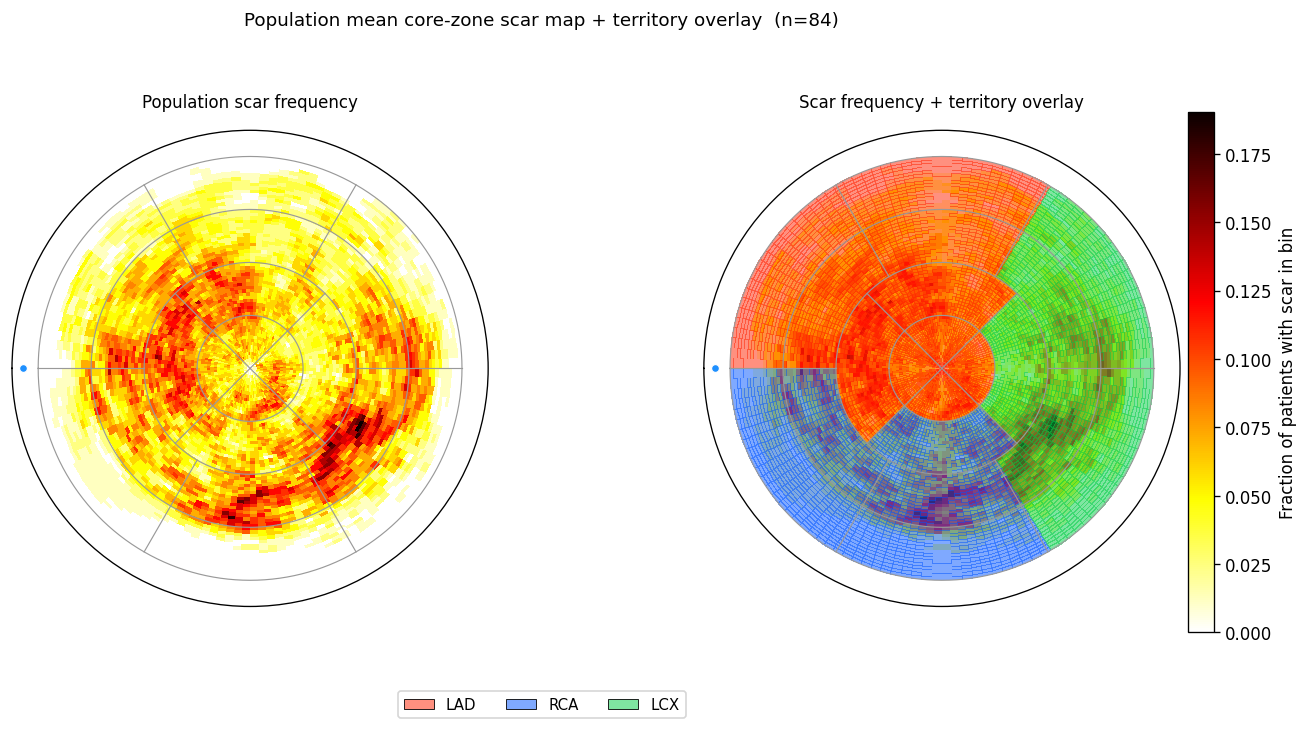

Saved population_scar_territory.png


In [86]:
if pmaps:
    pop_mean = np.stack(list(pmaps.values())).mean(axis=0)
    vmax_pm  = max(float(np.nanmax(pop_mean)), 1e-9)

    # Vivid, clearly distinct territory overlay colors
    OVERLAY_COLORS = {'LAD': '#ff2200', 'RCA': '#0055ff', 'LCX': '#00cc44'}
    OVERLAY_ALPHA  = 0.50

    fig, axes_pm = plt.subplots(1, 2, figsize=(14, 6.2),
                                subplot_kw={'projection': 'polar'})
    fig.suptitle(f'Population mean core-zone scar map + territory overlay  (n={len(pmaps)})',
                 fontsize=11)

    T_m, R_m = np.meshgrid(
        np.linspace(0, 2 * np.pi, N_THETA + 1),
        np.linspace(0, 1.0,       N_R + 1),
    )

    for ax_pm in axes_pm:
        mesh = ax_pm.pcolormesh(T_m, R_m, pop_mean, cmap='hot_r',
                                vmin=0, vmax=vmax_pm, shading='flat')
        t_full = np.linspace(0, 2 * np.pi, 361)
        for r_b in (0.25, 0.50, 0.75, 1.0):
            ax_pm.plot(t_full, np.full_like(t_full, r_b), color='#999', lw=0.7)
        for deg in (0, 60, 120, 180, 240, 300):
            ax_pm.plot([np.deg2rad(deg)] * 2, [0.5, 1.0], color='#999', lw=0.7)
        for deg in (45, 135, 225, 315):
            ax_pm.plot([np.deg2rad(deg)] * 2, [0.0, 0.5], color='#999', lw=0.7)
        ax_pm.set_theta_zero_location('W')
        ax_pm.set_theta_direction(-1)
        ax_pm.set_rticks([])
        ax_pm.set_xticks([])
        ax_pm.scatter([0.0], [1.07], s=22, color='dodgerblue',
                      edgecolor='white', linewidth=0.7, zorder=10, clip_on=False)
        for label, deg in [('ANT', 90), ('SEP', 0), ('INF', 270), ('LAT', 180)]:
            ax_pm.annotate(label, xy=(np.deg2rad(deg), 1.14), ha='center',
                           fontsize=8, color='#444', xycoords='data')

    axes_pm[0].set_title('Population scar frequency', fontsize=10, pad=14)

    # Territory overlay: distinct vivid colors at 50% alpha
    for terr, color in OVERLAY_COLORS.items():
        val_grid = (TERRITORY_GRID == terr).astype(float)
        cmap_t = mcolors.LinearSegmentedColormap.from_list(
            terr,
            [(1, 1, 1, 0.0),
             (*mcolors.to_rgb(color), OVERLAY_ALPHA)],
        )
        axes_pm[1].pcolormesh(T_m, R_m, val_grid, cmap=cmap_t,
                              vmin=0, vmax=1, shading='flat')
    axes_pm[1].set_title('Scar frequency + territory overlay', fontsize=10, pad=14)

    plt.colorbar(mesh, ax=axes_pm, orientation='vertical', fraction=0.02, pad=0.08,
                 label='Fraction of patients with scar in bin')

    legend_patches = [
        mpatches.Patch(facecolor=mcolors.to_rgba(OVERLAY_COLORS[t], alpha=OVERLAY_ALPHA),
                       edgecolor='black', linewidth=0.5, label=t)
        for t in TERRITORY
    ]
    fig.legend(handles=legend_patches, loc='lower center', ncol=3,
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, 0.02))

    fig.subplots_adjust(top=0.82, bottom=0.18, right=0.88, wspace=0.20)
    plt.savefig(OUT / 'population_scar_territory.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved population_scar_territory.png')

#### 4.2.4 Vertex Count-Based Age Correlations

Spearman rho is the main age statistic because it is non-parametric and tests for a monotonic relationship. Pearson r is shown only as a secondary linear summary. In both cases, `p` is the probability of observing an association at least this strong if the true association were zero.


Patients with age data: 32


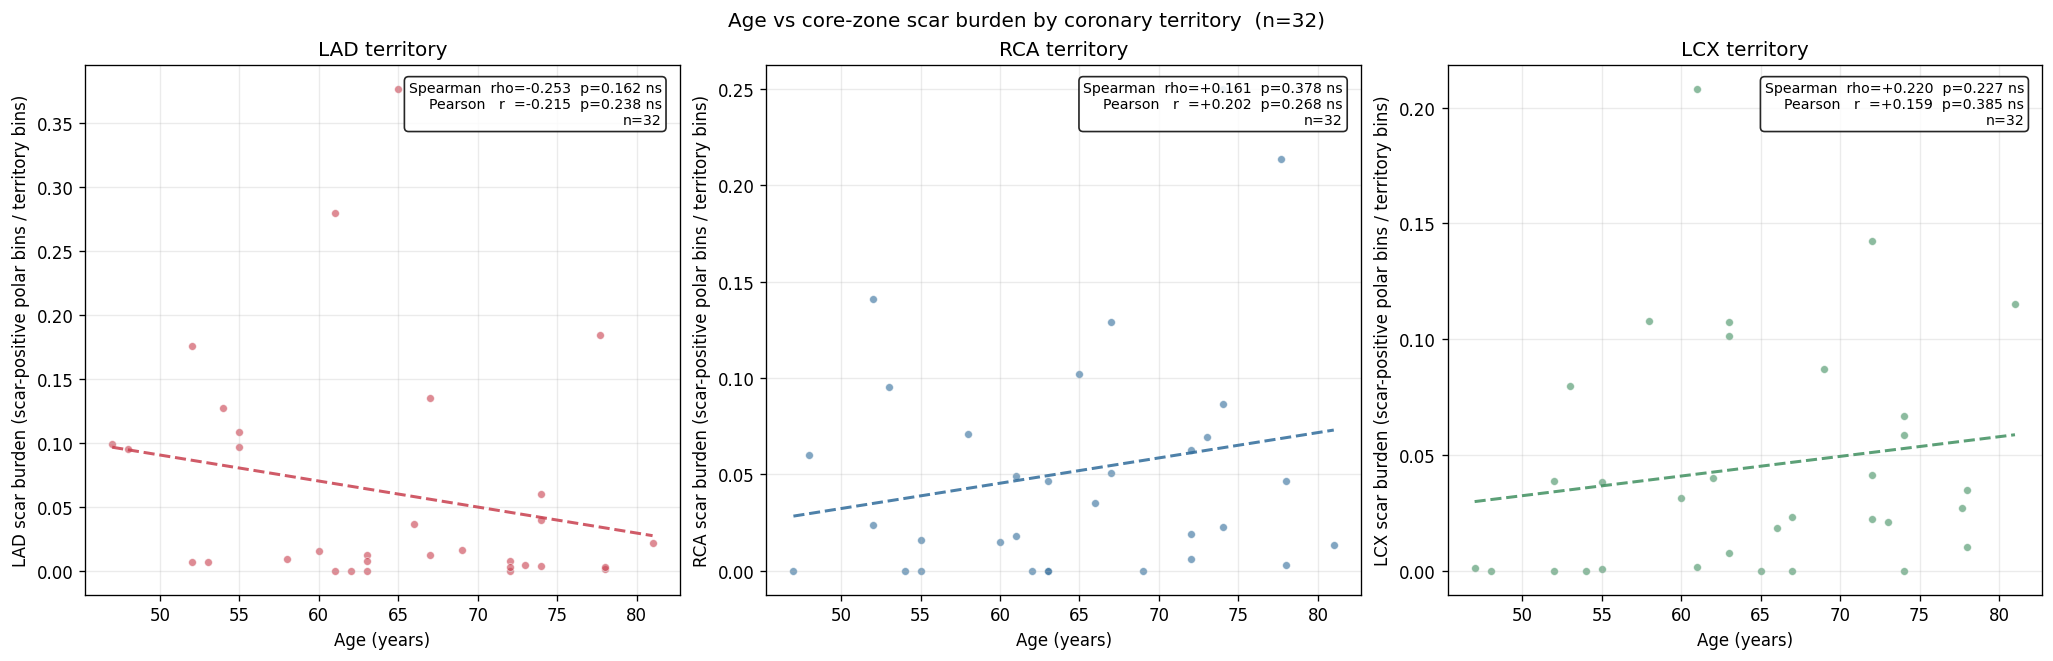

Saved age_territory_correlation.png


In [87]:
df_age = df.dropna(subset=['age'])
print(f'Patients with age data: {len(df_age)}')

fig, axes_age = plt.subplots(1, 3, figsize=(17, 5.4), constrained_layout=True)
fig.suptitle(
    f'Age vs core-zone scar burden by coronary territory  (n={len(df_age)})',
    fontsize=12,
)

for ax, terr in zip(axes_age, ('LAD', 'RCA', 'LCX')):
    sub = df_age[['age', terr]].dropna()
    rho_s, p_s  = spearmanr(sub['age'], sub[terr])
    rho_p, p_p  = pearsonr(sub['age'], sub[terr])
    color = TERR_COLORS[terr]

    ax.scatter(sub['age'], sub[terr], alpha=0.6, s=22, color=color,
               edgecolors='white', linewidth=0.5)

    m, b = np.polyfit(sub['age'], sub[terr], 1)
    x_l  = np.linspace(sub['age'].min(), sub['age'].max(), 100)
    ax.plot(x_l, m * x_l + b, color=color, lw=1.8, alpha=0.85, ls='--')

    ax.set_xlabel('Age (years)')
    ax.set_ylabel(f'{terr} scar burden (scar-positive polar bins / territory bins)')
    ax.set_title(f'{terr} territory')
    sig_s = '**' if p_s < 0.01 else ('*' if p_s < 0.05 else 'ns')
    sig_p = '**' if p_p < 0.01 else ('*' if p_p < 0.05 else 'ns')
    ax.text(0.97, 0.97,
            f'Spearman  rho={rho_s:+.3f}  p={p_s:.3f} {sig_s}\n'
            f'Pearson   r  ={rho_p:+.3f}  p={p_p:.3f} {sig_p}\n'
            f'n={len(sub)}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.grid(alpha=0.25)

plt.savefig(OUT / 'age_territory_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved age_territory_correlation.png')

##### 4.2.4.1 Age vs Total Scar and Multi-Territory Involvement


C:\Users\joan\AppData\Local\Temp\ipykernel_20000\3537962997.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ninv.boxplot(data_grp,


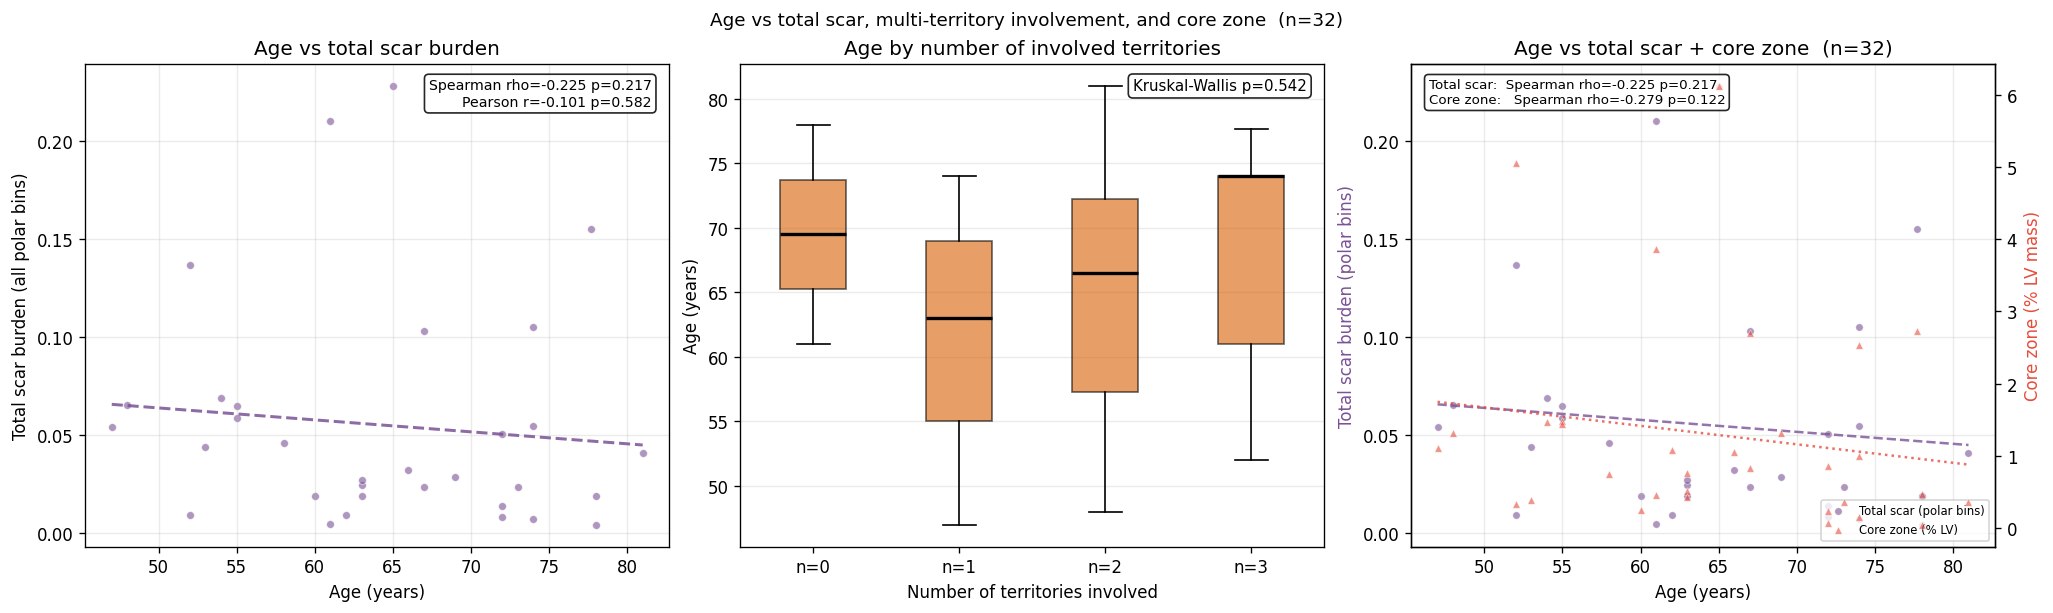

Saved age_total_scar.png


In [88]:
fig, axes_62 = plt.subplots(1, 3, figsize=(17, 5.0), constrained_layout=True)
fig.suptitle(f'Age vs total scar, multi-territory involvement, and core zone  (n={len(df_age)})',
             fontsize=11)

# Panel 1: age vs total scar
ax_tot = axes_62[0]
sub_tot = df_age[['age', 'total_scar']].dropna()
rho_t, p_t   = spearmanr(sub_tot['age'], sub_tot['total_scar'])
rho_tp, p_tp = pearsonr(sub_tot['age'], sub_tot['total_scar'])
ax_tot.scatter(sub_tot['age'], sub_tot['total_scar'], alpha=0.6, s=22,
               color=NOTEBOOK_PALETTE['secondary'], edgecolors='white', linewidth=0.5)
m, b = np.polyfit(sub_tot['age'], sub_tot['total_scar'], 1)
x_l  = np.linspace(sub_tot['age'].min(), sub_tot['age'].max(), 100)
ax_tot.plot(x_l, m * x_l + b, color=NOTEBOOK_PALETTE['secondary'], lw=1.8, ls='--', alpha=0.85)
ax_tot.set_xlabel('Age (years)')
ax_tot.set_ylabel('Total scar burden (all polar bins)')
ax_tot.set_title('Age vs total scar burden')
ax_tot.text(0.97, 0.97,
            f'Spearman rho={rho_t:+.3f} p={p_t:.3f}\nPearson r={rho_tp:+.3f} p={p_tp:.3f}',
            transform=ax_tot.transAxes, ha='right', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax_tot.grid(alpha=0.25)

# Panel 2: age by number of territories involved (boxplot + Kruskal-Wallis)
ax_ninv = axes_62[1]
sub_ninv = df_age[['age', 'n_involved']].dropna()
groups   = sorted(sub_ninv['n_involved'].unique())
data_grp = [sub_ninv.loc[sub_ninv['n_involved'] == g, 'age'].values for g in groups]
ax_ninv.boxplot(data_grp,
                labels=[f'n={int(g)}' for g in groups],
                patch_artist=True, medianprops=dict(color='black', lw=2),
                boxprops=dict(facecolor=NOTEBOOK_PALETTE['accent'], alpha=0.6))
if len(data_grp) >= 2:
    _, p_kw2 = kruskal(*data_grp)
    ax_ninv.text(0.97, 0.97, f'Kruskal-Wallis p={p_kw2:.3f}',
                 transform=ax_ninv.transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax_ninv.set_xlabel('Number of territories involved')
ax_ninv.set_ylabel('Age (years)')
ax_ninv.set_title('Age by number of involved territories')
ax_ninv.grid(axis='y', alpha=0.25)

# Panel 3: total scar (polar bins) + core zone (% LV) vs age – dual axis
ax_cz = axes_62[2]
sub_cz = df_age[['age', 'total_scar', 'core_pct']].dropna(subset=['age', 'core_pct'])
if len(sub_cz) >= 5:
    ax_cz2 = ax_cz.twinx()
    ln1 = ax_cz.scatter(sub_cz['age'], sub_cz['total_scar'], alpha=0.6, s=20,
                        color=NOTEBOOK_PALETTE['secondary'], edgecolors='white', linewidth=0.4,
                        label='Total scar (polar bins)')
    ln2 = ax_cz2.scatter(sub_cz['age'], sub_cz['core_pct'], alpha=0.6, s=20,
                         marker='^', color='#e74c3c', edgecolors='white', linewidth=0.4,
                         label='Core zone (% LV)')
    m1, b1 = np.polyfit(sub_cz['age'], sub_cz['total_scar'], 1)
    m2, b2 = np.polyfit(sub_cz['age'], sub_cz['core_pct'],   1)
    x_cz   = np.linspace(sub_cz['age'].min(), sub_cz['age'].max(), 100)
    ax_cz.plot(x_cz,  m1 * x_cz + b1, color=NOTEBOOK_PALETTE['secondary'], lw=1.5, ls='--', alpha=0.8)
    ax_cz2.plot(x_cz, m2 * x_cz + b2, color='#e74c3c', lw=1.5, ls=':',  alpha=0.8)
    rho_cz1, p_cz1 = spearmanr(sub_cz['age'], sub_cz['total_scar'])
    rho_cz2, p_cz2 = spearmanr(sub_cz['age'], sub_cz['core_pct'])
    ax_cz.set_xlabel('Age (years)')
    ax_cz.set_ylabel('Total scar burden (polar bins)', color=NOTEBOOK_PALETTE['secondary'])
    ax_cz2.set_ylabel('Core zone (% LV mass)', color='#e74c3c')
    ax_cz.set_title(f'Age vs total scar + core zone  (n={len(sub_cz)})')
    ax_cz.text(0.03, 0.97,
               f'Total scar:  Spearman rho={rho_cz1:+.3f} p={p_cz1:.3f}\n'
               f'Core zone:   Spearman rho={rho_cz2:+.3f} p={p_cz2:.3f}',
               transform=ax_cz.transAxes, ha='left', va='top', fontsize=8,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax_cz.legend([ln1, ln2], [ln1.get_label(), ln2.get_label()],
                 loc='lower right', fontsize=7)
    ax_cz.grid(alpha=0.25)
else:
    sub_fb = df_age[['age', 'total_scar']].dropna()
    rho_f, p_f = spearmanr(sub_fb['age'], sub_fb['total_scar'])
    ax_cz.scatter(sub_fb['age'], sub_fb['total_scar'], alpha=0.6, s=22, color=NOTEBOOK_PALETTE['secondary'])
    ax_cz.set_title('Age vs total scar (core_pct unavailable)')
    ax_cz.text(0.97, 0.97, f'Spearman rho={rho_f:+.3f} p={p_f:.3f}',
               transform=ax_cz.transAxes, ha='right', va='top', fontsize=9,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax_cz.grid(alpha=0.25)

plt.savefig(OUT / 'age_total_scar.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved age_total_scar.png')

##### 4.2.4.2 Age Correlations - Core Zone Only (Clinical Scalars)


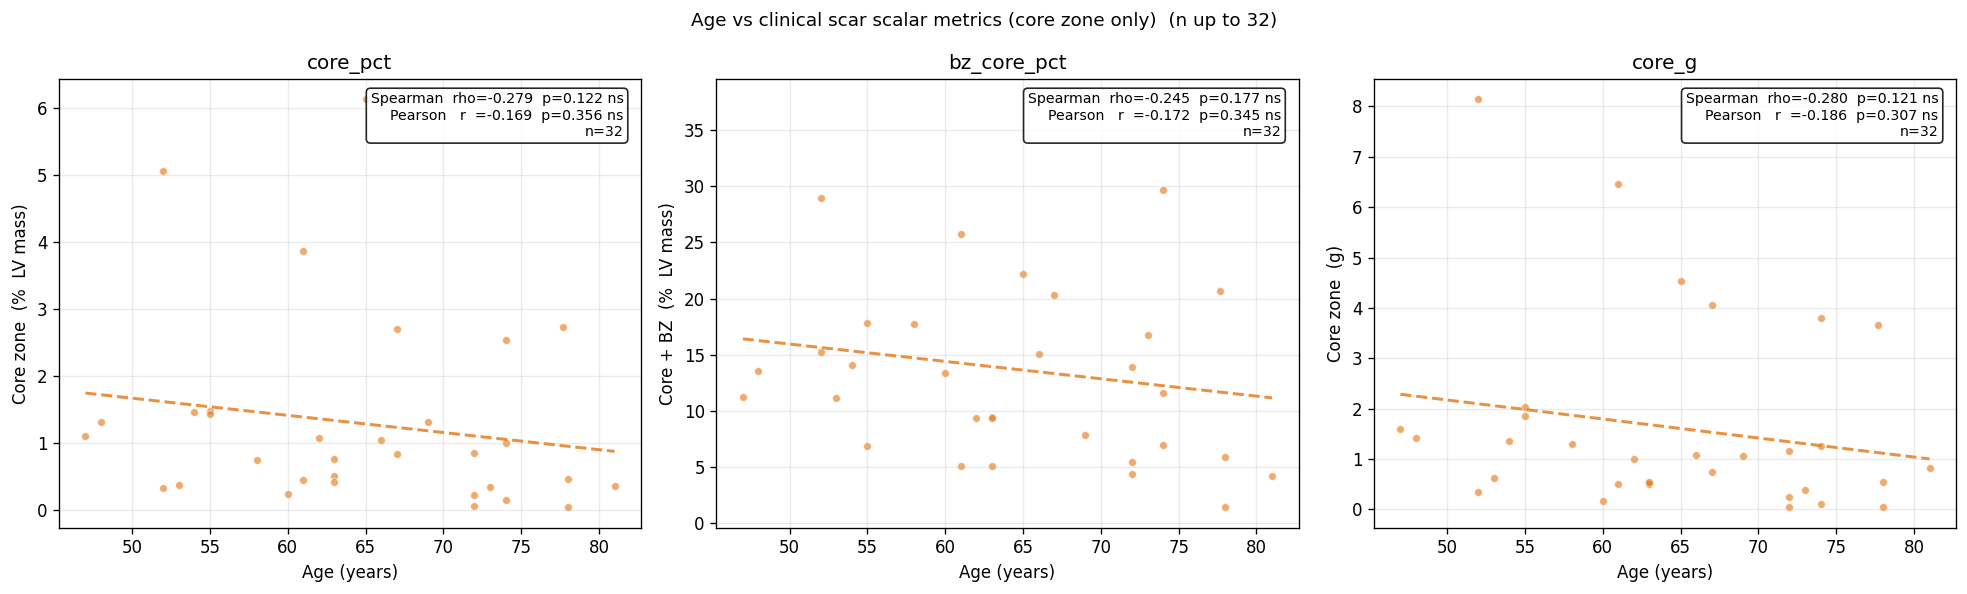

Saved age_core_zone_clinical.png


In [89]:
_scar_cols  = ['core_pct', 'bz_core_pct', 'core_g']
_scar_ylbls = [
    'Core zone  (%  LV mass)',
    'Core + BZ  (%  LV mass)',
    'Core zone  (g)',
]
_scar_cols_avail = [c for c in _scar_cols if df['age'].notna().any() and df[c].notna().any()]

if not _scar_cols_avail:
    print('No clinical scar scalar data available.')
else:
    fig, axes_cz = plt.subplots(1, len(_scar_cols_avail),
                                figsize=(5.5 * len(_scar_cols_avail), 5))
    if len(_scar_cols_avail) == 1:
        axes_cz = [axes_cz]
    fig.suptitle(
        f'Age vs clinical scar scalar metrics (core zone only)  (n up to {len(df_age)})',
        fontsize=11,
    )

    for ax, col, ylabel in zip(axes_cz, _scar_cols_avail,
                                [_scar_ylbls[_scar_cols.index(c)] for c in _scar_cols_avail]):
        sub_cz = df_age[['age', col]].dropna()
        if len(sub_cz) < 5:
            ax.set_title(f'{col}\n(insufficient data n={len(sub_cz)})')
            ax.axis('off')
            continue

        rho_s, p_s = spearmanr(sub_cz['age'], sub_cz[col])
        rho_p, p_p = pearsonr(sub_cz['age'], sub_cz[col])

        ax.scatter(sub_cz['age'], sub_cz[col], alpha=0.65, s=22,
                   color='#e67e22', edgecolors='white', linewidth=0.5)
        m, b = np.polyfit(sub_cz['age'], sub_cz[col], 1)
        x_l  = np.linspace(sub_cz['age'].min(), sub_cz['age'].max(), 100)
        ax.plot(x_l, m * x_l + b, color='#e67e22', lw=1.8, ls='--', alpha=0.85)

        ax.set_xlabel('Age (years)')
        ax.set_ylabel(ylabel)
        ax.set_title(col)
        sig_s = '**' if p_s < 0.01 else ('*' if p_s < 0.05 else 'ns')
        sig_p = '**' if p_p < 0.01 else ('*' if p_p < 0.05 else 'ns')
        ax.text(0.97, 0.97,
                f'Spearman  rho={rho_s:+.3f}  p={p_s:.3f} {sig_s}\n'
                f'Pearson   r  ={rho_p:+.3f}  p={p_p:.3f} {sig_p}\n'
                f'n={len(sub_cz)}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(OUT / 'age_core_zone_clinical.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved age_core_zone_clinical.png')

#### 4.2.5 Vertex Count-Based Ring-Level Scar Involvement

This mirrors the ring-level analysis in 4.3.7, but uses scar-positive polar bins instead of surface area.


,ring,mean_burden,sd_burden
0,Apex (17),0.050921,0.111588
1,Apical (13-16),0.066057,0.086310
2,Mid (7-12),0.066732,0.059977
3,Basal (1-6),0.021176,0.028641


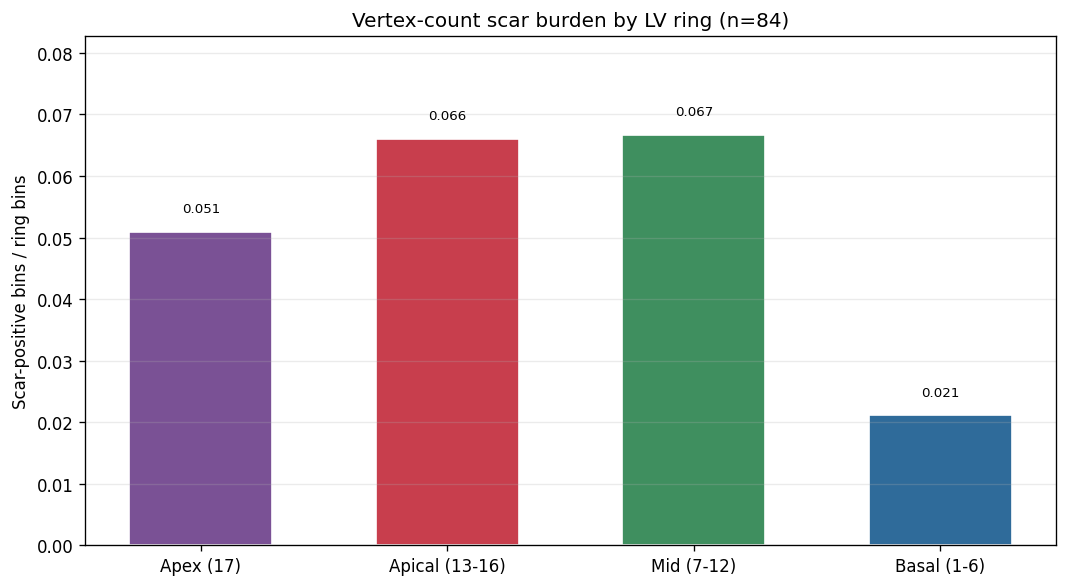

Saved vertex_ring_scar_burden.csv and vertex_ring_scar_burden.png


In [90]:
if not pmaps:
    print('No vertex polar maps available.')
else:
    _vkeys = list(pmaps.keys())
    _RINGS42 = [
        ('Apex (17)',       lambda r: r < 0.25,                 NOTEBOOK_PALETTE['secondary']),
        ('Apical (13-16)',  lambda r: (r >= 0.25) & (r < 0.50), TERR_COLORS['LAD']),
        ('Mid (7-12)',      lambda r: (r >= 0.50) & (r < 0.75), TERR_COLORS['LCX']),
        ('Basal (1-6)',     lambda r: r >= 0.75,                TERR_COLORS['RCA']),
    ]
    _rc42 = (np.arange(N_R) + 0.5) / N_R
    _ring_rows = []
    for _label, _fn, _color in _RINGS42:
        _mask_r = _fn(_rc42)
        _mask2d = np.broadcast_to(_mask_r[:, None], (N_R, N_THETA))
        _vals = np.array([np.asarray(pmaps[k], dtype=float)[_mask2d].mean() for k in _vkeys], dtype=float)
        _ring_rows.append({'ring': _label, 'mean_burden': float(np.nanmean(_vals)),
                           'sd_burden': float(np.nanstd(_vals, ddof=1)), 'color': _color})
    vertex_ring_summary = pd.DataFrame(_ring_rows)
    display(vertex_ring_summary.drop(columns='color'))
    vertex_ring_summary.drop(columns='color').to_csv(OUT / 'vertex_ring_scar_burden.csv', index=False)

    fig_r42, ax_r42 = plt.subplots(figsize=(9, 5))
    bars = ax_r42.bar(vertex_ring_summary['ring'], vertex_ring_summary['mean_burden'],
                      color=vertex_ring_summary['color'], edgecolor='white', width=0.58)
    _ymax = float(vertex_ring_summary['mean_burden'].max()) if len(vertex_ring_summary) else 0
    for bar, (_, row) in zip(bars, vertex_ring_summary.iterrows()):
        ax_r42.text(bar.get_x() + bar.get_width() / 2,
                    row['mean_burden'] + max(_ymax, 1e-9) * 0.04,
                    f"{row['mean_burden']:.3f}", ha='center', va='bottom', fontsize=8)
    ax_r42.set_title(f'Vertex-count scar burden by LV ring (n={len(_vkeys)})')
    ax_r42.set_ylabel('Scar-positive bins / ring bins')
    ax_r42.grid(axis='y', alpha=0.25)
    ax_r42.set_ylim(0, max(_ymax * 1.24, 0.01))
    plt.tight_layout()
    plt.savefig(OUT / 'vertex_ring_scar_burden.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved vertex_ring_scar_burden.csv and vertex_ring_scar_burden.png')


#### 4.2.6 Bootstrap CI for Vertex Count per AHA Segment

Patient-level bootstrap confidence intervals for mean vertex-count scar burden in each AHA segment.


,segment,label,mean_vertex_burden,ci95_low,ci95_high
0,1,bas ant,0.019683,0.008217,0.033247
1,2,bas ant-sep,0.020833,0.012330,0.030826
2,3,bas inf-sep,0.015873,0.006094,0.029621
3,4,bas inf,0.013427,0.006797,0.021916
4,5,bas inf-lat,0.028097,0.017785,0.039365
5,6,bas ant-lat,0.029585,0.017112,0.042695
6,7,mid ant,0.044237,0.021440,0.070324
7,8,mid ant-sep,0.067177,0.040105,0.097046
8,9,mid inf-sep,0.062571,0.040851,0.086913
9,10,mid inf,0.079444,0.052515,0.111408


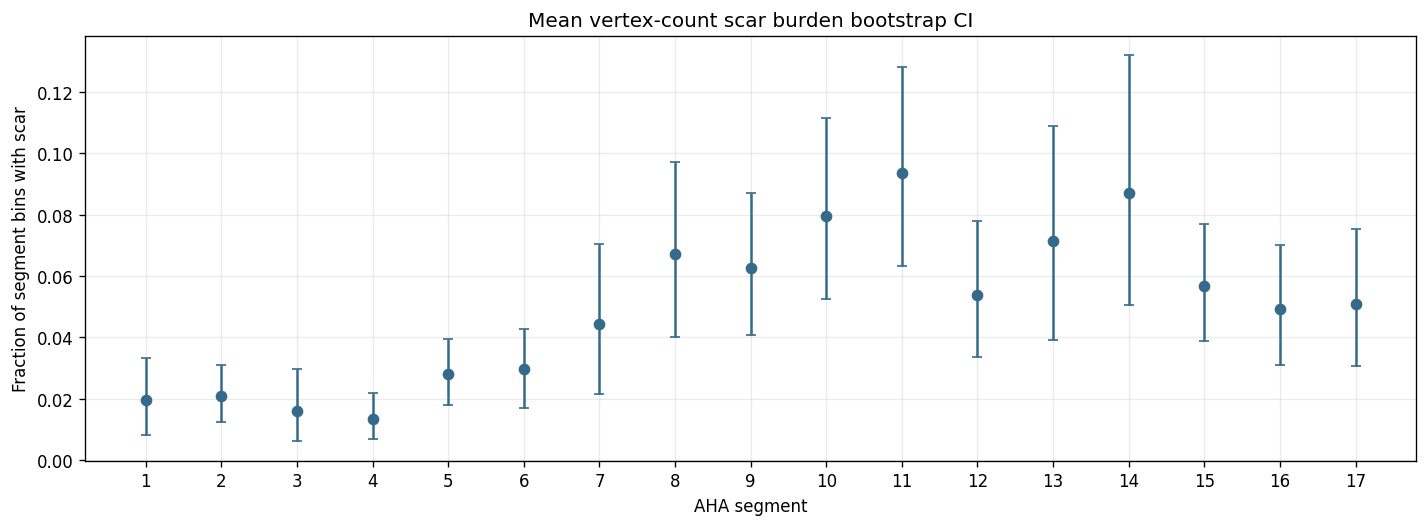

Saved vertex_bootstrap_aha17.csv and vertex_bootstrap_aha17.png


In [91]:
if 'seg_df' not in globals() or seg_df.empty:
    print('seg_df is not available. Run Section 3.2 first.')
else:
    _rng_vertex_boot = np.random.default_rng(42)
    _boot_rows = []
    for _seg, _col in zip(SEGMENTS, SEG_COLS):
        _vals = seg_df[_col].dropna().to_numpy(dtype=float)
        _lo, _hi = bootstrap_ci(_vals, np.nanmean, n_boot=2000, rng=_rng_vertex_boot)
        _boot_rows.append({'segment': _seg, 'label': SEG_LABELS[_seg],
                           'mean_vertex_burden': float(np.nanmean(_vals)),
                           'ci95_low': _lo, 'ci95_high': _hi})
    vertex_bootstrap_aha17 = pd.DataFrame(_boot_rows)
    display(vertex_bootstrap_aha17)
    vertex_bootstrap_aha17.to_csv(OUT / 'vertex_bootstrap_aha17.csv', index=False)

    fig_vb, ax_vb = plt.subplots(figsize=(12, 4.5))
    x = np.arange(1, 18)
    ax_vb.errorbar(x, vertex_bootstrap_aha17['mean_vertex_burden'],
                   yerr=[vertex_bootstrap_aha17['mean_vertex_burden'] - vertex_bootstrap_aha17['ci95_low'],
                         vertex_bootstrap_aha17['ci95_high'] - vertex_bootstrap_aha17['mean_vertex_burden']],
                   fmt='o', color=NOTEBOOK_PALETTE['primary'], ecolor=NOTEBOOK_PALETTE['primary'], capsize=3)
    ax_vb.set_title('Mean vertex-count scar burden bootstrap CI')
    ax_vb.set_ylabel('Fraction of segment bins with scar')
    ax_vb.set_xlabel('AHA segment')
    ax_vb.set_xticks(x)
    ax_vb.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT / 'vertex_bootstrap_aha17.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved vertex_bootstrap_aha17.csv and vertex_bootstrap_aha17.png')


#### 4.2.7 Vertex Count Variability Maps

Mirrors the area/coverage variability maps in 4.3.9, using binary scar-positive polar bins.


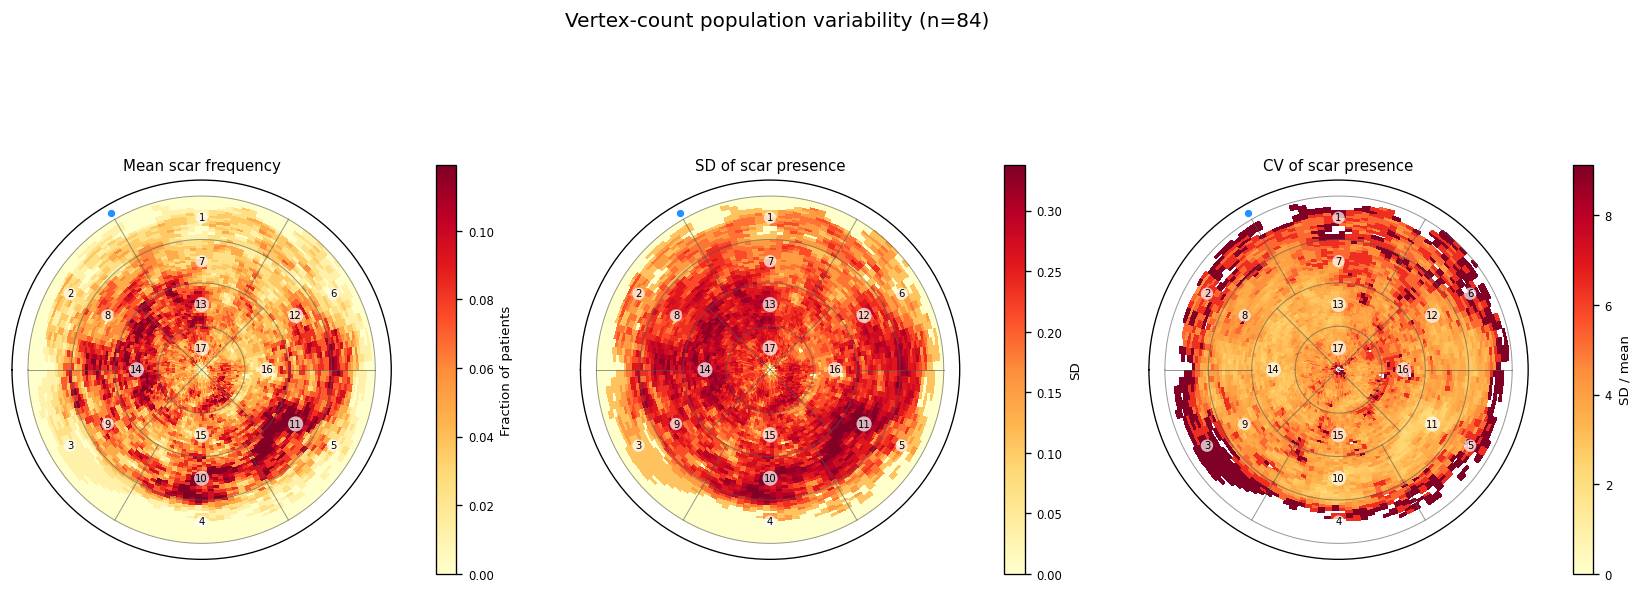

Saved vertex_variability_maps.png


In [92]:
if not pmaps:
    print('No vertex polar maps available.')
else:
    _vkeys = list(pmaps.keys())
    _vertex_stack = np.stack([np.asarray(pmaps[k], dtype=float) for k in _vkeys], axis=0)
    _vertex_mean = _vertex_stack.mean(axis=0)
    _vertex_sd = _vertex_stack.std(axis=0)
    _vertex_cv = np.divide(_vertex_sd, _vertex_mean,
                           out=np.full_like(_vertex_sd, np.nan), where=_vertex_mean > 1e-12)

    def _vmax_nonzero(arr, pct=99, default=1.0):
        vals = arr[np.isfinite(arr) & (arr > 0)]
        return float(np.nanpercentile(vals, pct)) if len(vals) else default

    fig_vvar, axes_vvar = plt.subplots(1, 3, figsize=(17, 5.8), subplot_kw={'projection': 'polar'})
    fig_vvar.suptitle(f'Vertex-count population variability (n={len(_vkeys)})', fontsize=12)
    panels = [
        (_vertex_mean, 'Mean scar frequency', 'Fraction of patients', max(_vmax_nonzero(_vertex_mean, pct=98, default=0.10), 0.05)),
        (_vertex_sd, 'SD of scar presence', 'SD', _vmax_nonzero(_vertex_sd)),
        (_vertex_cv, 'CV of scar presence', 'SD / mean', _vmax_nonzero(_vertex_cv)),
    ]
    for _ax, (_arr, _title, _label, _vmax) in zip(axes_vvar, panels):
        _m = draw_bullseye_m04(_arr, _ax, title=_title, cmap=SCAR_CMAP, vmax=_vmax, label_segs=True)
        add_colorbar_m04(_m, _ax, label=_label)
    fig_vvar.subplots_adjust(top=0.82, wspace=0.28)
    plt.savefig(OUT / 'vertex_variability_maps.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved vertex_variability_maps.png')


#### 4.2.8 Vertex Count-Based Archetype Maps

Each patient is assigned to a dominant coronary territory using the predefined LAD/RCA/LCX territory mask. For a given patient, the notebook counts scar-positive polar bins inside each territory and divides by the total number of bins assigned to that territory. The territory with the largest normalized scar fraction becomes that patient's dominant territory. These maps then average the original vertex-level scar polar maps within each dominant-territory group; they do not trace the culprit vessel directly, but summarize scar location using the reporting-territory convention.


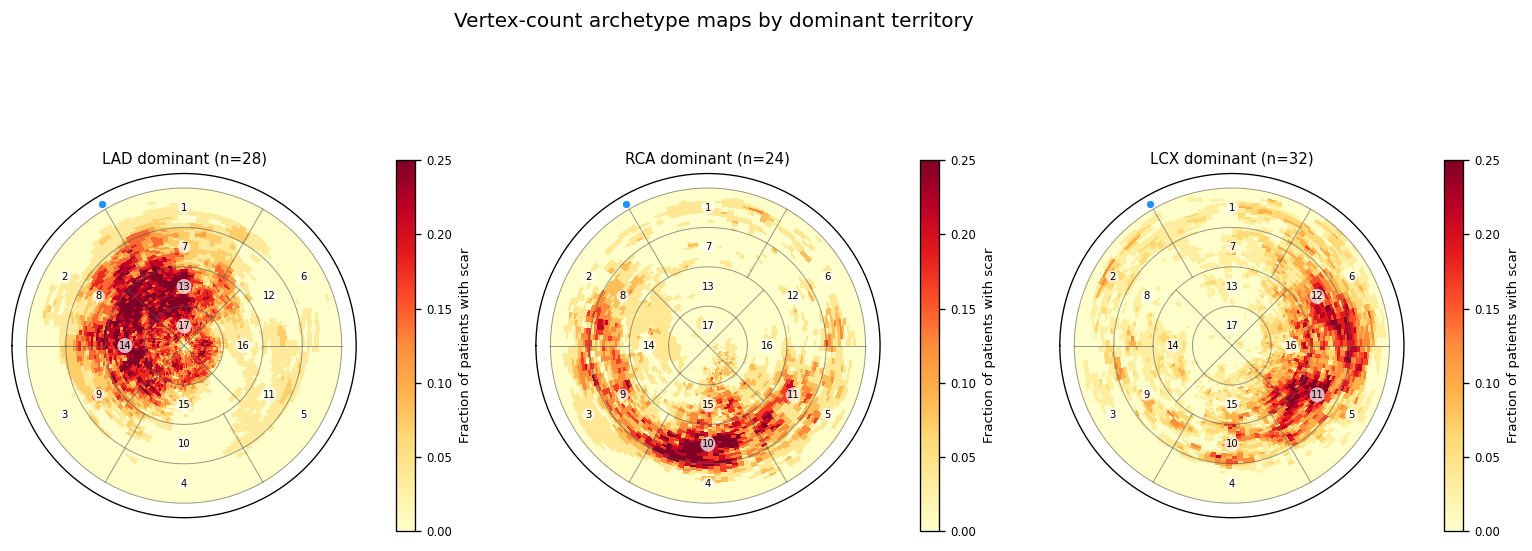

Saved vertex_archetype_maps_by_dominant_territory.png


In [93]:
if not pmaps or 'df' not in globals() or df.empty:
    print('Vertex polar maps or df are not available. Run Section 3.1 first.')
else:
    _arch_terrs = ['LAD', 'RCA', 'LCX']
    _vertex_maps, _arch_ns = {}, {}
    for _terr in _arch_terrs:
        _tkeys = df.loc[df['dominant'] == _terr, 'key'].tolist()
        _tkeys = [k for k in _tkeys if k in pmaps]
        if _tkeys:
            _vertex_maps[_terr] = np.stack([np.asarray(pmaps[k], dtype=float) for k in _tkeys]).mean(axis=0)
            _arch_ns[_terr] = len(_tkeys)
    if not _vertex_maps:
        print('No vertex archetype maps computable.')
    else:
        _avail = [t for t in _arch_terrs if t in _vertex_maps]
        _vmax_vertex = max(float(np.nanpercentile(_vertex_maps[t][_vertex_maps[t] > 0], 95)) if (_vertex_maps[t] > 0).any() else 0 for t in _avail)
        _vmax_vertex = _vmax_vertex if _vmax_vertex > 0 else 1.0
        fig_varch, axes_varch = plt.subplots(1, len(_avail), figsize=(5.2 * len(_avail), 5.4), subplot_kw={'projection': 'polar'})
        axes_varch = np.atleast_1d(axes_varch)
        fig_varch.suptitle('Vertex-count archetype maps by dominant territory', fontsize=12)
        for _ax, _terr in zip(axes_varch, _avail):
            _m = draw_bullseye_m04(_vertex_maps[_terr], _ax,
                                   title=f'{_terr} dominant (n={_arch_ns[_terr]})',
                                   cmap=SCAR_CMAP, vmax=_vmax_vertex, label_segs=True)
            add_colorbar_m04(_m, _ax, label='Fraction of patients with scar')
        fig_varch.subplots_adjust(top=0.82, wspace=0.30)
        plt.savefig(OUT / 'vertex_archetype_maps_by_dominant_territory.png', bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved vertex_archetype_maps_by_dominant_territory.png')


### 4.3 Area-Based Statistical Analysis

This section mirrors the vertex count-based workflow in Section 4.2, but uses mesh surface area instead of binary polar-bin occupancy. In the vertex-count analysis, each polar bin contributes as 0/1 scar presence, so all bins are weighted equally. In the area-based analysis, scar is weighted by the LV mesh surface area projected into each bin, so larger anatomical surface regions contribute more area.

The three area-related maps answer different questions:
- **CZ area (`cz_area`)**: absolute scar surface area in each polar bin, in mm2.
- **Scar-normalized CZ area (`cz_norm`)**: fraction of a patient's total scar area located in each bin.
- **LV surface coverage (`coverage`)**: CZ area divided by available LV shell area in that bin, correcting for larger basal bins and LV-size differences.

#### 4.3.1 Area, Scar-Normalized, and Surface-Coverage Map Computation


In [94]:

# --- Section 4.3 area helpers (adapted from M03 Section 5) ---

_EPS_S8 = 1e-12


def _tri_areas_centers(mesh):
    """Return triangle centers and areas for a mesh surface."""
    surf = mesh.extract_surface(algorithm='dataset_surface').clean()
    if surf.n_cells == 0:
        raise ValueError('mesh has no surface cells')
    pts   = np.asarray(surf.points, dtype=float)
    faces = np.asarray(surf.faces)
    centers_list, areas_list = [], []
    i = 0
    while i < len(faces):
        n   = int(faces[i])
        idx = faces[i + 1 : i + 1 + n]
        i  += 1 + n
        tris = [(0, 1, 2)] if n == 3 else [(0, 1, 2), (0, 2, 3)]
        for a, b, c in tris:
            A, B, C = pts[idx[a]], pts[idx[b]], pts[idx[c]]
            area = 0.5 * np.linalg.norm(np.cross(B - A, C - A))
            if area > 0:
                centers_list.append((A + B + C) / 3.0)
                areas_list.append(area)
    if not centers_list:
        raise ValueError('no valid triangles')
    return np.array(centers_list), np.array(areas_list)


def _accum_areas(mesh, geom, n_r=N_R, n_theta=N_THETA):
    """Accumulate triangle surface area (mm2) into the polar grid."""
    centers, areas = _tri_areas_centers(mesh)
    theta, s = project_points_to_polar(centers, geom)
    theta = (2.0 * np.pi - theta) % (2.0 * np.pi)
    ri = np.clip((s * n_r).astype(int),                      0, n_r - 1)
    ti = np.clip((theta / (2 * np.pi) * n_theta).astype(int), 0, n_theta - 1)
    grid = np.zeros((n_r, n_theta), dtype=float)
    np.add.at(grid, (ri, ti), areas)
    return grid[:, ::-1]


def polar_area_maps(case, n_r=N_R, n_theta=N_THETA):
    shell = best_shell(case)
    cz    = get_cz_mesh(case)
    rv    = best_rv_mesh(case)
    if shell is None:
        raise ValueError('no LV shell')
    if cz is None:
        raise ValueError('no CZ mesh')
    if rv is not None:
        ref_fn = lambda m, ax, ap, _rv=rv: rv_reference_from_rv_mesh(m, _rv, ax, ap)
        geom   = prepare_polar_geometry(shell, ref_fn=ref_fn, rv_mesh=rv)
        ref_method = 'rv'
    else:
        geom   = prepare_polar_geometry(shell, rv_mesh=None)
        ref_method = 'pca'

    _t, _s = project_points_to_polar(np.asarray(cz.points), geom)
    _t_cw  = (2.0 * np.pi - _t) % (2.0 * np.pi)
    vertex   = polar_mask(_t_cw, _s, n_r, n_theta, roll_deg=AHA_DISPLAY_DEG).astype(float)
    cz_area  = _accum_areas(cz, geom, n_r, n_theta)
    lv_area  = _accum_areas(shell, geom, n_r, n_theta)
    cz_total = float(cz_area.sum())
    lv_total = float(lv_area.sum())
    cz_norm  = np.divide(cz_area, cz_total,
                         out=np.zeros_like(cz_area), where=cz_total > _EPS_S8)
    coverage = np.divide(cz_area, lv_area,
                         out=np.zeros_like(cz_area), where=lv_area > _EPS_S8)
    return dict(vertex=vertex, cz_area=cz_area, lv_area=lv_area,
                cz_norm=cz_norm, coverage=coverage,
                cz_total=cz_total, lv_total=lv_total, ref_method=ref_method)


print('Section 4.3 area helpers ready: vertex, CZ area, scar-normalized area, and LV surface coverage.')


Section 4.3 area helpers ready: vertex, CZ area, scar-normalized area, and LV surface coverage.


In [ ]:

s8_results, s8_failures = {}, []

for _case in tqdm(known, desc='Sec 8 area maps'):
    _key = f'{_case.year}/{_case.patient_id}'
    try:
        s8_results[_key] = polar_area_maps(_case)
    except Exception as _exc:
        s8_failures.append({'key': _key, 'error': repr(_exc)})

print(f'OK: {len(s8_results)}   Failures: {len(s8_failures)}')
for r in s8_failures[:3]:
    print(f'  {r["key"]}: {r["error"]}')


Sec 8 area maps:   5%|▍         | 4/84 [00:07<02:23,  1.80s/it]

#### 4.3.2 Area-Based Population Projection Comparison

Mirrors M03 Section 5.3: vertex frequency, raw CZ area, scar-normalized CZ area, and LV surface coverage are shown side by side.


In [ ]:
# Population superposition: vertex / CZ area / scar-normalized CZ area / LV surface coverage.
if not s8_results:
    print('No results.')
else:
    _s8_keys = list(s8_results.keys())
    _vert_s8 = np.stack([s8_results[k]['vertex']   for k in _s8_keys]).mean(axis=0)
    _area_s8 = np.stack([s8_results[k]['cz_area']  for k in _s8_keys]).mean(axis=0)
    _norm_s8 = np.stack([s8_results[k]['cz_norm']  for k in _s8_keys]).mean(axis=0)
    _cov_s8  = np.stack([s8_results[k]['coverage'] for k in _s8_keys]).mean(axis=0)

    fig_s8p, axes_s8p = plt.subplots(1, 4, figsize=(22, 6.0), subplot_kw={'projection': 'polar'})
    fig_s8p.suptitle(f'Area projection comparison  |  n={len(_s8_keys)}', fontsize=11)

    def _pct_vmax(arr, pct=95, default=1.0):
        vals = np.asarray(arr)[np.isfinite(arr) & (np.asarray(arr) > 0)]
        return float(np.nanpercentile(vals, pct)) if len(vals) else default

    _vmax_area = _pct_vmax(_area_s8, 95)
    _vmax_norm = _pct_vmax(_norm_s8, 95)
    _vmax_cov  = _pct_vmax(_cov_s8,  95)

    maps = [
        draw_bullseye_m04(_vert_s8, axes_s8p[0], 'Vertex scar frequency', cmap='YlOrRd', vmax=1, label_segs=True),
        draw_bullseye_m04(_area_s8, axes_s8p[1], 'Mean CZ area (mm2)', cmap=AREA_CMAP, vmax=_vmax_area, label_segs=True),
        draw_bullseye_m04(_norm_s8, axes_s8p[2], 'Scar-normalized CZ area', cmap=AREA_CMAP, vmax=_vmax_norm, label_segs=True),
        draw_bullseye_m04(_cov_s8,  axes_s8p[3], 'LV surface coverage', cmap=COVERAGE_CMAP, vmax=_vmax_cov, label_segs=True),
    ]
    labels = ['Fraction of patients', 'Mean CZ area (mm2)', 'Fraction of patient scar', 'CZ area / LV area']
    for _m, _ax, _lab in zip(maps, axes_s8p, labels):
        add_colorbar_m04(_m, _ax, label=_lab)
    fig_s8p.subplots_adjust(top=0.82, wspace=0.28)
    plt.savefig(OUT / 's8_population_projection_comparison.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved s8_population_projection_comparison.png')


#### 4.3.3 Area-Based Population-Level Coronary Territory Distributions

This repeats the territory comparison using area-weighted metrics: raw CZ area, scar-normalized area, and LV surface coverage. The plots show mean values without SD error bars; the Friedman/Kendall annotations test whether the paired territory distributions differ within patients.


In [ ]:
# Territory-level area burden, scar-normalized burden, and LV surface coverage.
if s8_results:
    _s8_rows = []
    for key, res in s8_results.items():
        pid = key.split('/')[-1]
        row = {'key': key, 'pid': pid,
               'sex': sex_map.get(pid, float('nan')),
               'age': float(age_map[pid]) if pid in age_map else float('nan')}
        for terr in TERRITORY:
            mask = (TERRITORY_GRID == terr)
            _cz = float(res['cz_area'][mask].sum())
            _lv = float(res['lv_area'][mask].sum())
            row[f'{terr}_area_mm2'] = _cz
            row[f'{terr}_norm']     = float(res['cz_norm'][mask].sum())
            row[f'{terr}_coverage'] = _cz / _lv if _lv > _EPS_S8 else np.nan
        row['cz_total_mm2'] = float(res['cz_total'])
        row['lv_total_mm2'] = float(res['lv_total'])
        row['global_coverage'] = row['cz_total_mm2'] / row['lv_total_mm2'] if row['lv_total_mm2'] > _EPS_S8 else np.nan
        _s8_rows.append(row)

    df_s8 = pd.DataFrame(_s8_rows)
    df_s8['dominant_area_mm2'] = df_s8[[f'{t}_area_mm2' for t in ('LAD', 'RCA', 'LCX')]].idxmax(axis=1).str.replace('_area_mm2', '', regex=False)
    df_s8['dominant_area_norm'] = df_s8[[f'{t}_norm' for t in ('LAD', 'RCA', 'LCX')]].idxmax(axis=1).str.replace('_norm', '', regex=False)
    df_s8['dominant_coverage'] = df_s8[[f'{t}_coverage' for t in ('LAD', 'RCA', 'LCX')]].idxmax(axis=1).str.replace('_coverage', '', regex=False)
    df_s8.to_csv(OUT / 'area_territory_summary_per_patient.csv', index=False)

    print('Territory CZ area (mm2) mean +/- SD:')
    for t in ('LAD', 'RCA', 'LCX'):
        col = f'{t}_area_mm2'
        print(f'  {t}: {df_s8[col].mean():.2f} +/- {df_s8[col].std():.2f}')

    fig_s8t, axes_s8t = plt.subplots(1, 3, figsize=(17, 5.2), constrained_layout=True)
    fig_s8t.suptitle(f'Territory-level area burden and coverage  (n={len(df_s8)})', fontsize=12)

    for ax, col_suffix, ylabel, title in [
        (axes_s8t[0], 'area_mm2', 'CZ area (mm2)', 'Raw CZ area'),
        (axes_s8t[1], 'norm', 'Fraction of patient scar', 'Scar-normalized area'),
        (axes_s8t[2], 'coverage', 'CZ area / LV area', 'LV surface coverage'),
    ]:
        means = [df_s8[f'{t}_{col_suffix}'].mean() for t in ('LAD', 'RCA', 'LCX')]
        cols  = [TERR_COLORS[t] for t in ('LAD', 'RCA', 'LCX')]
        bars  = ax.bar(['LAD', 'RCA', 'LCX'], means,
                       color=cols, alpha=0.80, edgecolor='white', width=0.55)
        _ymax = max(means) if len(means) else 0
        for bar, m_v in zip(bars, means):
            _offset = _ymax * 0.04 if _ymax > 0 else 0.01
            ax.text(bar.get_x() + bar.get_width() / 2,
                    m_v + _offset,
                    f'{m_v:.3f}', ha='center', va='bottom', fontsize=8)
        sub_s8 = df_s8[[f'LAD_{col_suffix}', f'RCA_{col_suffix}', f'LCX_{col_suffix}']].dropna()
        if len(sub_s8) >= 3:
            fr_s, fr_p = friedmanchisquare(sub_s8.iloc[:, 0].values,
                                           sub_s8.iloc[:, 1].values,
                                           sub_s8.iloc[:, 2].values)
            kendall_w = fr_s / (len(sub_s8) * 3 * (3 - 1))
            ax.text(0.97, 0.97,
                    f'Friedman chi2={fr_s:.2f}\np={fr_p:.3f}\nKendall W={kendall_w:.3f}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=7.5,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0, _ymax * 1.24 if _ymax > 0 else 1)

    plt.savefig(OUT / 's8_territory_area_coverage_burden.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved area_territory_summary_per_patient.csv and s8_territory_area_coverage_burden.png')
else:
    print('No area results available.')


#### 4.3.4 Area-Based AHA-17 Segment Characterization


In [ ]:
# AHA-17 segment comparison: vertex / CZ area / scar-normalized area / LV surface coverage.
if s8_results:
    _s8_keys2 = list(s8_results.keys())
    _segs_s8  = list(range(1, 18))
    _AHA_G8 = _aha_segment_grid()
    _aha_rows = []
    _area_patient_rows = []

    for _key in _s8_keys2:
        _pid = _key.split('/')[-1]
        _res = s8_results[_key]
        _prow = {'key': _key, 'pid': _pid, 'age': float(age_map[_pid]) if _pid in age_map else np.nan}
        for _seg in _segs_s8:
            mask = (_AHA_G8 == _seg)
            _cz = float(_res['cz_area'][mask].sum())
            _lv = float(_res['lv_area'][mask].sum())
            _prow[f'area_seg_{_seg:02d}'] = _cz
            _prow[f'norm_seg_{_seg:02d}'] = float(_res['cz_norm'][mask].sum())
            _prow[f'coverage_seg_{_seg:02d}'] = _cz / _lv if _lv > _EPS_S8 else np.nan
        _area_patient_rows.append(_prow)
    area_seg_df = pd.DataFrame(_area_patient_rows)
    AREA_SEG_COLS = [f'area_seg_{i:02d}' for i in range(1, 18)]
    COVERAGE_SEG_COLS = [f'coverage_seg_{i:02d}' for i in range(1, 18)]
    area_seg_df.to_csv(OUT / 'area_aha17_per_patient.csv', index=False)

    for _seg in _segs_s8:
        mask = (_AHA_G8 == _seg)
        _vert_vals = [s8_results[k]['vertex'][mask].any() for k in _s8_keys2]
        _area_vals = [s8_results[k]['cz_area'][mask].sum() for k in _s8_keys2]
        _norm_vals = [s8_results[k]['cz_norm'][mask].sum() for k in _s8_keys2]
        _cov_vals = []
        for k in _s8_keys2:
            _cz = s8_results[k]['cz_area'][mask].sum()
            _lv = s8_results[k]['lv_area'][mask].sum()
            _cov_vals.append(_cz / _lv if _lv > _EPS_S8 else np.nan)
        _aha_rows.append({'segment': _seg, 'label': SEG_LABELS[_seg],
                          'vertex_frequency': float(np.mean(_vert_vals)),
                          'mean_area_mm2': float(np.mean(_area_vals)),
                          'sd_area_mm2': float(np.std(_area_vals, ddof=1)),
                          'mean_norm': float(np.mean(_norm_vals)),
                          'mean_coverage': float(np.nanmean(_cov_vals)),
                          'sd_coverage': float(np.nanstd(_cov_vals, ddof=1))})
    area_aha_summary = pd.DataFrame(_aha_rows)
    display(area_aha_summary)
    area_aha_summary.to_csv(OUT / 'area_aha17_summary.csv', index=False)

    x_s8 = np.arange(1, 18)
    fig_s8a, axes_s8a = plt.subplots(1, 4, figsize=(20, 4.3), constrained_layout=True)
    fig_s8a.suptitle(f'AHA-17 area comparison  |  n={len(_s8_keys2)}', fontsize=11)
    plot_specs = [
        ('vertex_frequency', 'Vertex scar frequency', 'Fraction of patients', '#c0392b'),
        ('mean_area_mm2', 'Mean CZ area', 'mm2', '#8e44ad'),
        ('mean_norm', 'Scar-normalized CZ area', 'Fraction of total scar', '#16a085'),
        ('mean_coverage', 'LV surface coverage', 'CZ area / LV area', '#2c3e50'),
    ]
    for _ax, (_col, _title, _ylabel, _color) in zip(axes_s8a, plot_specs):
        _ax.bar(x_s8, area_aha_summary[_col], color=_color, edgecolor='white')
        _ax.set_title(_title)
        _ax.set_ylabel(_ylabel)
        _ax.set_xlabel('AHA segment')
        _ax.set_xticks(x_s8)
        _ax.set_xticklabels(x_s8, fontsize=7)
        _ax.grid(axis='y', alpha=0.25)
        _ax.set_xlim(0.3, 17.7)
    plt.savefig(OUT / 's8_aha_segments_area_coverage.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved area_aha17_per_patient.csv, area_aha17_summary.csv, and s8_aha_segments_area_coverage.png')
else:
    print('No area results available.')


#### 4.3.5 Area-Based Age Effects Across AHA-17 Segments

This mirrors Section 4.2.1, using CZ area per AHA segment instead of the fraction of scar-positive bins.


In [ ]:
if 'area_seg_df' not in globals() or area_seg_df.empty:
    print('area_seg_df is not available. Run Section 4.3.4 first.')
else:
    AREA_SEG_COLS = [f'area_seg_{i:02d}' for i in range(1, 18)]
    _age_area = area_seg_df.dropna(subset=['age']).copy()
    _rows = []
    for _seg, _col in zip(range(1, 18), AREA_SEG_COLS):
        _sub = _age_area[['age', _col]].dropna()
        if len(_sub) >= 3:
            _rho, _p = spearmanr(_sub['age'], _sub[_col])
        else:
            _rho, _p = np.nan, np.nan
        _rows.append({'segment': _seg, 'label': SEG_LABELS[_seg], 'n': len(_sub),
                      'spearman_rho': _rho, 'p_uncorrected': _p})
    age_spearman_area_aha17 = pd.DataFrame(_rows)
    age_spearman_area_aha17['p_bonferroni'] = np.minimum(age_spearman_area_aha17['p_uncorrected'] * 17, 1.0)
    age_spearman_area_aha17['significant_bonf_0_05'] = age_spearman_area_aha17['p_bonferroni'] < 0.05
    display(age_spearman_area_aha17)
    age_spearman_area_aha17.to_csv(OUT / 'age_spearman_area_aha17.csv', index=False)

    fig_area_age, ax_area_age = plt.subplots(figsize=(12, 4.2))
    ax_area_age.bar(age_spearman_area_aha17['segment'], age_spearman_area_aha17['spearman_rho'],
                    color='#8e44ad', edgecolor='white')
    ax_area_age.axhline(0, color='black', lw=0.8)
    ax_area_age.set_xticks(range(1, 18))
    ax_area_age.set_xlabel('AHA segment')
    ax_area_age.set_ylabel('Spearman rho with age')
    ax_area_age.set_title('Area-based age correlation by AHA segment')
    ax_area_age.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT / 'age_spearman_area_aha17.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved age_spearman_area_aha17.csv and age_spearman_area_aha17.png')


#### 4.3.6 Area-Based PCA of AHA-17 CZ Area Vectors

This mirrors Section 4.2.2, using the 17-segment CZ area vector for each patient.


In [ ]:
if 'area_seg_df' not in globals() or area_seg_df.empty:
    print('area_seg_df is not available. Run Section 4.3.4 first.')
else:
    AREA_SEG_COLS = [f'area_seg_{i:02d}' for i in range(1, 18)]
    _area_complete = area_seg_df.dropna(subset=AREA_SEG_COLS).copy()
    if len(_area_complete) < 3:
        print('Not enough complete area rows for PCA.')
    else:
        _X_area = _area_complete[AREA_SEG_COLS].to_numpy(dtype=float)
        _X_area_scaled = StandardScaler().fit_transform(_X_area)
        _n_area_pc = min(6, _X_area_scaled.shape[0], _X_area_scaled.shape[1])
        pca_area = PCA(n_components=_n_area_pc, random_state=0)
        area_scores = pca_area.fit_transform(_X_area_scaled)
        area_pc_cols = [f'PC{i+1}' for i in range(_n_area_pc)]
        area_pca_var = pd.DataFrame({'component': area_pc_cols,
                                     'explained_variance_ratio': pca_area.explained_variance_ratio_,
                                     'cumulative_variance_ratio': np.cumsum(pca_area.explained_variance_ratio_)})
        display(area_pca_var)
        area_pca_var.to_csv(OUT / 'pca_explained_variance_area_aha17.csv', index=False)
        area_loadings = pd.DataFrame(pca_area.components_.T, index=AREA_SEG_COLS, columns=area_pc_cols)
        area_loadings.insert(0, 'segment', range(1, 18))
        area_loadings.insert(1, 'label', [SEG_LABELS[i] for i in range(1, 18)])
        display(area_loadings)
        area_loadings.to_csv(OUT / 'pca_loadings_area_aha17.csv', index=False)
        fig_area_pca, axes_area_pca = plt.subplots(1, 2, figsize=(12, 4.5))
        axes_area_pca[0].bar(area_pca_var['component'], area_pca_var['explained_variance_ratio'], color=NOTEBOOK_PALETTE['secondary'], edgecolor='white')
        axes_area_pca[0].set_ylabel('Explained variance ratio')
        axes_area_pca[0].set_title('Area PCA variance by component')
        axes_area_pca[0].grid(axis='y', alpha=0.25)
        axes_area_pca[1].plot(area_pca_var['component'], area_pca_var['cumulative_variance_ratio'], marker='o', color=NOTEBOOK_PALETTE['neutral'])
        axes_area_pca[1].set_ylim(0, 1.02)
        axes_area_pca[1].set_ylabel('Cumulative explained variance')
        axes_area_pca[1].set_title('Area PCA cumulative variance')
        axes_area_pca[1].grid(alpha=0.25)
        plt.tight_layout()
        plt.savefig(OUT / 'pca_variance_area_aha17.png', bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved area PCA outputs')


##### 4.3.6.1 Area-Based PCA Score Multivariate Normality Diagnostic


In [ ]:
if 'area_scores' in globals() and 'area_pc_cols' in globals() and len(area_pc_cols) >= 2:
    _area_mv_cols = area_pc_cols[:min(4, len(area_pc_cols))]
    _area_scores_df = pd.DataFrame(area_scores[:, :len(_area_mv_cols)], columns=_area_mv_cols)
    area_pca_mv_summary = pd.DataFrame([
        _mahalanobis_chisquare_qq(_area_scores_df[_area_mv_cols].to_numpy(dtype=float),
                                  f'Multivariate normality: first {len(_area_mv_cols)} area PCA scores',
                                  'normality_chisquare_area_pca_scores.png')
    ])
    display(area_pca_mv_summary)
    area_pca_mv_summary.to_csv(OUT / 'normality_area_pca_scores_multivariate_summary.csv', index=False)
    print('Saved normality_area_pca_scores_multivariate_summary.csv')
else:
    print('Area PCA scores not available; run Section 4.3.6 first.')


##### 4.3.6.2 Area-Based PCA Score-Group Scar Frequency Maps

Patients are grouped by low, middle, and high scores along each area-based PCA component. The panels then average the original vertex scar-frequency maps in each group, so the PCA pattern is visualized as a full polar-map frequency distribution instead of an AHA segment block map.


In [ ]:
if 'pca_area' not in globals() or 'area_scores' not in globals() or 'area_seg_df' not in globals():
    print('Area PCA is not available. Run Section 4.3.6 first.')
elif 's8_results' not in globals() or not s8_results:
    print('Area maps are not available for PCA score-group maps.')
else:
    _area_mode_rows = min(3, pca_area.n_components_)
    _area_mode_df = area_seg_df.dropna(subset=AREA_SEG_COLS).copy()
    for _pc_idx in range(_area_mode_rows):
        _area_mode_df[f'PC{_pc_idx + 1}'] = area_scores[:, _pc_idx]

    _group_n = max(3, int(np.ceil(0.20 * len(_area_mode_df))))
    _all_area_mode_maps, _area_mode_payload = [], []
    for _pc_idx in range(_area_mode_rows):
        _pc = f'PC{_pc_idx + 1}'
        _tmp = _area_mode_df[['key', _pc]].dropna().sort_values(_pc)
        _low_keys = [k for k in _tmp.head(_group_n)['key'] if k in s8_results]
        _high_keys = [k for k in _tmp.tail(_group_n)['key'] if k in s8_results]
        _center_score = float(_tmp[_pc].median())
        _mid_keys = [k for k in _tmp.assign(_dist=(_tmp[_pc] - _center_score).abs())
                       .sort_values('_dist').head(_group_n)['key'] if k in s8_results]
        _groups = [('low score', _low_keys), ('middle score', _mid_keys), ('high score', _high_keys)]
        _maps = []
        for _label, _keys in _groups:
            _arr = np.stack([np.asarray(s8_results[k]['vertex'], dtype=float) for k in _keys], axis=0).mean(axis=0) if _keys else np.full_like(next(iter(s8_results.values()))['vertex'], np.nan, dtype=float)
            _maps.append((_label, _keys, _arr))
            _all_area_mode_maps.append(_arr)
        _area_mode_payload.append(_maps)

    _positive_area_modes = np.concatenate([_m[np.isfinite(_m) & (_m > 0)] for _m in _all_area_mode_maps if np.isfinite(_m).any()]) if _all_area_mode_maps else np.array([])
    _vmax_area_modes = float(np.nanpercentile(_positive_area_modes, 99)) if len(_positive_area_modes) else 1.0
    _vmax_area_modes = max(_vmax_area_modes, 0.05)

    fig_area_modes, axes_area_modes = plt.subplots(
        _area_mode_rows, 3, figsize=(15.5, 5.0 * _area_mode_rows), subplot_kw={'projection': 'polar'})
    axes_area_modes = np.atleast_2d(axes_area_modes)
    fig_area_modes.suptitle('Area PCA score-group scar frequency maps', fontsize=12)
    for _r, _maps in enumerate(_area_mode_payload):
        for _c, (_label, _keys, _arr) in enumerate(_maps):
            _m = draw_bullseye_m04(_arr, axes_area_modes[_r, _c],
                                   title=f'Area PC{_r+1}: {_label}\n(n={len(_keys)})', cmap=SCAR_CMAP,
                                   vmax=_vmax_area_modes, label_segs=True)
            add_colorbar_m04(_m, axes_area_modes[_r, _c], label='Mean vertex scar frequency')
    fig_area_modes.subplots_adjust(top=0.92, wspace=0.34, hspace=0.36)
    plt.savefig(OUT / 'pca_modes_area_polar_maps.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved pca_modes_area_polar_maps.png')


#### 4.3.7 Ring-Level Surface Coverage

Adapted from M03 Section 5.6. Each bar is pooled CZ area divided by pooled LV shell area inside that apex-to-base ring.


In [ ]:
if not s8_results:
    print('No area results available.')
else:
    _s8_keys = list(s8_results.keys())
    _RINGS43 = [
        ('Apex (17)',       lambda r: r < 0.25,                 '#9b59b6'),
        ('Apical (13-16)',  lambda r: (r >= 0.25) & (r < 0.50), '#e74c3c'),
        ('Mid (7-12)',      lambda r: (r >= 0.50) & (r < 0.75), '#2ecc71'),
        ('Basal (1-6)',     lambda r: r >= 0.75,                '#3498db'),
    ]
    _rc43 = (np.arange(N_R) + 0.5) / N_R
    _ring_rows = []
    for _label, _fn, _col in _RINGS43:
        _mask_r = _fn(_rc43)
        _mask2d = np.broadcast_to(_mask_r[:, None], (N_R, N_THETA))
        _cz_pool = sum(s8_results[k]['cz_area'][_mask2d].sum() for k in _s8_keys)
        _lv_pool = sum(s8_results[k]['lv_area'][_mask2d].sum() for k in _s8_keys)
        _ring_rows.append({'ring': _label, 'cz_area_mm2': _cz_pool, 'lv_area_mm2': _lv_pool,
                           'coverage': _cz_pool / _lv_pool if _lv_pool > _EPS_S8 else np.nan,
                           'color': _col})
    area_ring_coverage = pd.DataFrame(_ring_rows)
    display(area_ring_coverage.drop(columns='color'))
    area_ring_coverage.drop(columns='color').to_csv(OUT / 'area_ring_coverage.csv', index=False)

    fig_r43, ax_r43 = plt.subplots(figsize=(9, 5))
    bars = ax_r43.bar(area_ring_coverage['ring'], area_ring_coverage['coverage'],
                      color=area_ring_coverage['color'], edgecolor='white', width=0.58)
    for bar, (_, row) in zip(bars, area_ring_coverage.iterrows()):
        ax_r43.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(area_ring_coverage['coverage']) * 0.03,
                    f"{row['coverage']:.3f}\n({row['cz_area_mm2']/1e3:.1f}k / {row['lv_area_mm2']/1e3:.1f}k mm2)",
                    ha='center', va='bottom', fontsize=8)
    ax_r43.set_title(f'CZ area by LV ring (n={len(_s8_keys)})')
    ax_r43.set_ylabel('CZ area / LV area')
    ax_r43.grid(axis='y', alpha=0.25)
    ax_r43.set_ylim(0, max(area_ring_coverage['coverage']) * 1.25)
    plt.tight_layout()
    plt.savefig(OUT / 'area_ring_coverage.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved area_ring_coverage.csv and area_ring_coverage.png')


#### 4.3.8 Bootstrap CI for Area and Coverage per AHA Segment

Patient-level bootstrap confidence intervals for mean CZ area and mean LV surface coverage in each AHA segment.


In [ ]:
if 'area_seg_df' not in globals() or area_seg_df.empty:
    print('area_seg_df is not available. Run Section 4.3.4 first.')
else:
    _rng_area_boot = np.random.default_rng(42)
    _boot_rows = []
    for _seg in range(1, 18):
        _area_vals = area_seg_df[f'area_seg_{_seg:02d}'].dropna().to_numpy(dtype=float)
        _cov_vals = area_seg_df[f'coverage_seg_{_seg:02d}'].dropna().to_numpy(dtype=float)
        _a_lo, _a_hi = bootstrap_ci(_area_vals, np.nanmean, n_boot=2000, rng=_rng_area_boot)
        _c_lo, _c_hi = bootstrap_ci(_cov_vals, np.nanmean, n_boot=2000, rng=_rng_area_boot)
        _boot_rows.append({'segment': _seg, 'label': SEG_LABELS[_seg],
                           'mean_area_mm2': float(np.nanmean(_area_vals)),
                           'area_ci95_low': _a_lo, 'area_ci95_high': _a_hi,
                           'mean_coverage': float(np.nanmean(_cov_vals)),
                           'coverage_ci95_low': _c_lo, 'coverage_ci95_high': _c_hi})
    area_bootstrap_aha17 = pd.DataFrame(_boot_rows)
    display(area_bootstrap_aha17)
    area_bootstrap_aha17.to_csv(OUT / 'area_bootstrap_aha17.csv', index=False)

    fig_ab, axes_ab = plt.subplots(1, 2, figsize=(15, 4.5), constrained_layout=True)
    x = np.arange(1, 18)
    axes_ab[0].errorbar(x, area_bootstrap_aha17['mean_area_mm2'],
                        yerr=[area_bootstrap_aha17['mean_area_mm2'] - area_bootstrap_aha17['area_ci95_low'],
                              area_bootstrap_aha17['area_ci95_high'] - area_bootstrap_aha17['mean_area_mm2']],
                        fmt='o', color=NOTEBOOK_PALETTE['secondary'], ecolor=NOTEBOOK_PALETTE['secondary'], capsize=3)
    axes_ab[0].set_title('Mean CZ area bootstrap CI')
    axes_ab[0].set_ylabel('CZ area (mm2)')
    axes_ab[1].errorbar(x, area_bootstrap_aha17['mean_coverage'],
                        yerr=[area_bootstrap_aha17['mean_coverage'] - area_bootstrap_aha17['coverage_ci95_low'],
                              area_bootstrap_aha17['coverage_ci95_high'] - area_bootstrap_aha17['mean_coverage']],
                        fmt='o', color=NOTEBOOK_PALETTE['neutral'], ecolor=NOTEBOOK_PALETTE['neutral'], capsize=3)
    axes_ab[1].set_title('Mean LV surface coverage bootstrap CI')
    axes_ab[1].set_ylabel('CZ area / LV area')
    for _ax in axes_ab:
        _ax.set_xlabel('AHA segment')
        _ax.set_xticks(x)
        _ax.grid(alpha=0.25)
    plt.savefig(OUT / 'area_bootstrap_aha17.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved area_bootstrap_aha17.csv and area_bootstrap_aha17.png')


#### 4.3.9 Area and Coverage Variability Maps

Mirrors the vertex-count variability map, but uses CZ area and LV surface coverage. SD shows absolute between-patient variability; CV normalizes variability by the local mean.


In [ ]:
if not s8_results:
    print('No area results available.')
else:
    _s8_keys = list(s8_results.keys())
    _area_stack = np.stack([s8_results[k]['cz_area'] for k in _s8_keys], axis=0)
    _cov_stack  = np.stack([s8_results[k]['coverage'] for k in _s8_keys], axis=0)

    _area_mean = _area_stack.mean(axis=0)
    _area_sd   = _area_stack.std(axis=0)
    _area_cv   = np.divide(_area_sd, _area_mean, out=np.full_like(_area_sd, np.nan), where=_area_mean > _EPS_S8)
    _cov_mean  = _cov_stack.mean(axis=0)
    _cov_sd    = _cov_stack.std(axis=0)
    _cov_cv    = np.divide(_cov_sd, _cov_mean, out=np.full_like(_cov_sd, np.nan), where=_cov_mean > _EPS_S8)

    def _vmax_nonzero(arr, pct=99, default=1.0):
        vals = arr[np.isfinite(arr) & (arr > 0)]
        return float(np.nanpercentile(vals, pct)) if len(vals) else default

    fig_var, axes_var = plt.subplots(2, 2, figsize=(14, 11.5), subplot_kw={'projection': 'polar'})
    fig_var.suptitle(f'Area-based population variability (n={len(_s8_keys)})', fontsize=12)
    panels = [
        (_area_sd, 'SD of CZ area', 'CZ area SD (mm2)', _vmax_nonzero(_area_sd)),
        (_area_cv, 'CV of CZ area', 'SD / mean', _vmax_nonzero(_area_cv)),
        (_cov_sd, 'SD of LV surface coverage', 'Coverage SD', _vmax_nonzero(_cov_sd)),
        (_cov_cv, 'CV of LV surface coverage', 'SD / mean', _vmax_nonzero(_cov_cv)),
    ]
    for _ax, (_arr, _title, _label, _vmax) in zip(axes_var.ravel(), panels):
        _m = draw_bullseye_m04(_arr, _ax, title=_title, cmap=SCAR_CMAP, vmax=_vmax, label_segs=True)
        add_colorbar_m04(_m, _ax, label=_label)
    fig_var.subplots_adjust(top=0.90, wspace=0.28, hspace=0.32)
    plt.savefig(OUT / 'area_coverage_variability_maps.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved area_coverage_variability_maps.png')


#### 4.3.10 Area Archetype Maps by Dominant Coronary Territory

For patients assigned to each dominant area territory, this shows the mean CZ area and mean LV surface coverage polar maps.


In [ ]:
if not s8_results or 'df_s8' not in globals() or df_s8.empty:
    print('Area results or df_s8 are not available. Run Sections 4.3.1-4.3.3 first.')
else:
    _arch_terrs = ['LAD', 'RCA', 'LCX']
    _area_maps, _coverage_maps, _arch_ns = {}, {}, {}
    for _terr in _arch_terrs:
        _tkeys = df_s8.loc[df_s8['dominant_area_mm2'] == _terr, 'key'].tolist()
        _tkeys = [k for k in _tkeys if k in s8_results]
        if _tkeys:
            _area_maps[_terr] = np.stack([s8_results[k]['cz_area'] for k in _tkeys]).mean(axis=0)
            _coverage_maps[_terr] = np.stack([s8_results[k]['coverage'] for k in _tkeys]).mean(axis=0)
            _arch_ns[_terr] = len(_tkeys)
    if not _area_maps:
        print('No area archetype maps computable.')
    else:
        _avail = [t for t in _arch_terrs if t in _area_maps]
        _vmax_area = max(float(np.nanpercentile(_area_maps[t][_area_maps[t] > 0], 95)) if (_area_maps[t] > 0).any() else 0 for t in _avail)
        _vmax_cov = max(float(np.nanpercentile(_coverage_maps[t][_coverage_maps[t] > 0], 95)) if (_coverage_maps[t] > 0).any() else 0 for t in _avail)
        _vmax_area = _vmax_area if _vmax_area > 0 else 1.0
        _vmax_cov = _vmax_cov if _vmax_cov > 0 else 1.0
        fig_arch, axes_arch = plt.subplots(2, len(_avail), figsize=(5.2 * len(_avail), 9.8), subplot_kw={'projection': 'polar'})
        axes_arch = np.atleast_2d(axes_arch)
        fig_arch.suptitle('Area archetype maps by dominant raw-area territory', fontsize=12)
        for _j, _terr in enumerate(_avail):
            _m1 = draw_bullseye_m04(_area_maps[_terr], axes_arch[0, _j],
                                    title=f'{_terr} dominant (n={_arch_ns[_terr]})\nMean CZ area',
                                    cmap=AREA_CMAP, vmax=_vmax_area, label_segs=True)
            add_colorbar_m04(_m1, axes_arch[0, _j], label='CZ area (mm2)')
            _m2 = draw_bullseye_m04(_coverage_maps[_terr], axes_arch[1, _j],
                                    title=f'{_terr} dominant (n={_arch_ns[_terr]})\nMean LV surface coverage',
                                    cmap=COVERAGE_CMAP, vmax=_vmax_cov, label_segs=True)
            add_colorbar_m04(_m2, axes_arch[1, _j], label='CZ area / LV area')
        fig_arch.subplots_adjust(top=0.90, wspace=0.30, hspace=0.32)
        plt.savefig(OUT / 'area_archetype_maps_by_dominant_territory.png', bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved area_archetype_maps_by_dominant_territory.png')


#### 4.3.11 Area-Based Age Correlations

This mirrors Section 4.2.4 using area-based territory metrics, global CZ area, and global LV surface coverage. Spearman rho is the primary statistic; Pearson r is reported as a secondary linear summary.


In [ ]:
if 'df_s8' not in globals() or df_s8.empty:
    print('df_s8 is not available. Run Section 4.3.3 first.')
else:
    df_s8_age = df_s8.dropna(subset=['age']).copy()
    _area_age_specs = [
        ('cz_total_mm2', 'Total CZ area (mm2)', NOTEBOOK_PALETTE['secondary']),
        ('global_coverage', 'Global LV surface coverage', NOTEBOOK_PALETTE['neutral']),
    ]
    for _terr in ('LAD', 'RCA', 'LCX'):
        _area_age_specs.append((f'{_terr}_area_mm2', f'{_terr} CZ area (mm2)', TERR_COLORS[_terr]))
    fig_area_age_terr, axes_area_age_terr = plt.subplots(1, len(_area_age_specs), figsize=(5.4 * len(_area_age_specs), 5.0), constrained_layout=True)
    axes_area_age_terr = np.atleast_1d(axes_area_age_terr)
    _summary_rows = []
    for _ax, (_col, _label, _color) in zip(axes_area_age_terr, _area_age_specs):
        _sub = df_s8_age[['age', _col]].dropna()
        if len(_sub) >= 3:
            _rho, _p_s = spearmanr(_sub['age'], _sub[_col])
            _r, _p_p = pearsonr(_sub['age'], _sub[_col])
        else:
            _rho = _p_s = _r = _p_p = np.nan
        _summary_rows.append({'variable': _col, 'label': _label, 'n': len(_sub),
                              'spearman_rho': _rho, 'spearman_p': _p_s,
                              'pearson_r': _r, 'pearson_p': _p_p})
        _ax.scatter(_sub['age'], _sub[_col], color=_color, alpha=0.65, s=28, edgecolors='white', linewidth=0.5)
        if len(_sub) >= 2:
            _m, _b = np.polyfit(_sub['age'], _sub[_col], 1)
            _x = np.linspace(_sub['age'].min(), _sub['age'].max(), 100)
            _ax.plot(_x, _m * _x + _b, color=_color, ls='--', lw=1.6)
        _ax.set_title(_label)
        _ax.set_xlabel('Age (years)')
        _ax.set_ylabel(_label)
        _ax.text(0.97, 0.97, f'Spearman rho={_rho:+.3f} p={_p_s:.3f}\nPearson r={_r:+.3f} p={_p_p:.3f}\nn={len(_sub)}',
                 transform=_ax.transAxes, ha='right', va='top', fontsize=8,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
        _ax.grid(alpha=0.25)
    fig_area_age_terr.suptitle(f'Age vs area-based scar burden and coverage (n={len(df_s8_age)})', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT / 'age_area_territory_correlation.png', bbox_inches='tight', dpi=150)
    plt.show()
    age_area_territory_summary = pd.DataFrame(_summary_rows)
    display(age_area_territory_summary)
    age_area_territory_summary.to_csv(OUT / 'age_area_territory_correlation.csv', index=False)
    print('Saved age_area_territory_correlation.csv and age_area_territory_correlation.png')


## 5. Transmurality Analysis

This section moves from where scar is located to how deeply scar extends through the LV wall. Transmurality is expressed as a percentage of wall depth: values near 0% are subendocardial, values near 100% approach the epicardial side. The summary histograms show the patient-level distribution of mean/median transmurality and threshold fractions among scar-positive bins, while the boxplots compare those summaries by LV ring or coronary territory.

Ring-specific transmurality is computed locally: for each ring, the notebook selects scar-positive polar bins inside that ring and summarizes their local wall-depth values. Elongation is treated as a scalar layer-span: the number of wall-depth layers where scar is present in that polar bin. Therefore `>=3 layers` means scar is present in at least three sampled transmural layers, and `>=5 layers` means a broader through-wall span.


In [ ]:
import re

RING_ZONES = {
    'Apex':   (0.00, 0.25),
    'Apical': (0.25, 0.50),
    'Mid':    (0.50, 0.75),
    'Basal':  (0.75, 1.00),
}


def _layer_percent(path):
    match = re.search(r'Layer[_\s-]*(\d+)', Path(path).stem, flags=re.IGNORECASE)
    return float(match.group(1)) if match else np.nan


def _polar_vertex_mask_for_mesh(mesh, geom, n_r=N_R, n_theta=N_THETA):
    theta, s = project_points_to_polar(np.asarray(mesh.points), geom)
    theta = (2.0 * np.pi - theta) % (2.0 * np.pi)
    return polar_mask(theta, s, n_r, n_theta, roll_deg=AHA_DISPLAY_DEG).astype(bool)


def _transmurality_map_for_case(case, scar_map=None, n_r=N_R, n_theta=N_THETA):
    shell = best_shell(case)
    rv = best_rv_mesh(case)
    if shell is None:
        raise ValueError('no LV shell')
    if rv is not None:
        ref_fn = lambda m, ax, ap, _rv=rv: rv_reference_from_rv_mesh(m, _rv, ax, ap)
        geom = prepare_polar_geometry(shell, ref_fn=ref_fn, rv_mesh=rv)
        ref_method = 'rv'
    else:
        geom = prepare_polar_geometry(shell, rv_mesh=None)
        ref_method = 'pca'

    key = f'{case.year}/{case.patient_id}'
    if scar_map is None:
        scar_map = pmaps.get(key)
    if scar_map is None:
        raise ValueError('no scar polar map')
    scar_mask = np.asarray(scar_map, dtype=float) > 0

    layer_paths = sorted(
        list(getattr(case, 'tissue_layers', [])),
        key=lambda p: (_layer_percent(p) if np.isfinite(_layer_percent(p)) else 999),
    )
    if not layer_paths:
        raise ValueError('no TISSUE/Layer_XX.vtk surfaces')

    trans_grid      = np.zeros((n_r, n_theta), dtype=float)
    min_trans_grid  = np.zeros((n_r, n_theta), dtype=float)
    layer_count_grid = np.zeros((n_r, n_theta), dtype=float)
    _first_hit      = np.zeros((n_r, n_theta), dtype=bool)
    layer_presence = {}
    for layer_path in layer_paths:
        pct = _layer_percent(layer_path)
        if not np.isfinite(pct):
            continue
        layer_mesh = pv.read(str(layer_path))
        layer_mask = _polar_vertex_mask_for_mesh(layer_mesh, geom, n_r, n_theta)
        layer_scar_mask = layer_mask & scar_mask
        trans_grid[layer_scar_mask] = np.maximum(trans_grid[layer_scar_mask], pct)
        layer_count_grid[layer_scar_mask] += 1
        _new_bins = layer_scar_mask & ~_first_hit
        min_trans_grid[_new_bins] = pct
        _first_hit[_new_bins] = True
        layer_presence[f'layer_{int(pct):02d}'] = int(layer_scar_mask.sum())

    # Scalar local scar elongation: number of sampled transmural layers with scar in each polar bin.
    elongation_grid = np.where(
        scar_mask & (trans_grid > 0),
        layer_count_grid,
        0.0,
    )

    return {
        'trans_grid': trans_grid,
        'min_trans_grid': min_trans_grid,
        'elongation_grid': elongation_grid,
        'elongation_unit': 'scar-positive layers',
        'scar_mask': scar_mask,
        'layer_presence': layer_presence,
        'ref_method': ref_method,
        'n_layers': len(layer_presence),
    }


trans_results, trans_failures = {}, []
for case in tqdm(known, desc='Layer-based transmurality maps'):
    key = f'{case.year}/{case.patient_id}'
    if key not in pmaps:
        continue
    try:
        trans_results[key] = _transmurality_map_for_case(case, scar_map=pmaps[key])
    except Exception as exc:
        trans_failures.append((key, str(exc)))

print(f'Transmurality maps computed: {len(trans_results)}')
print(f'Transmurality failures: {len(trans_failures)}')
if trans_failures[:8]:
    print('First failures:')
    for key, msg in trans_failures[:8]:
        print(f'  {key}: {msg}')

In [ ]:
def _ring_mask(lo, hi, n_r=N_R, n_theta=N_THETA):
    rc = (np.arange(n_r) + 0.5) / n_r
    return ((rc[:, None] >= lo) & (rc[:, None] < hi)) & np.ones((n_r, n_theta), dtype=bool)


if not trans_results:
    print('No transmurality results available. Run the previous cell first.')
else:
    trans_rows = []
    layer_rows = []
    long_rows = []
    for key, res in trans_results.items():
        pid = key.split('/')[-1]
        trans = np.asarray(res['trans_grid'], dtype=float)
        onset = np.asarray(res['min_trans_grid'], dtype=float)
        elong = np.asarray(res['elongation_grid'], dtype=float)
        scar = np.asarray(res['scar_mask'], dtype=bool)
        base = {
            'key': key,
            'pid': pid,
            'sex': sex_map.get(pid, np.nan),
            'age': float(age_map[pid]) if pid in age_map else np.nan,
            'n_layers': res['n_layers'],
        }
        scar_vals = trans[scar & (trans > 0)]
        base.update({
            'overall_mean_trans_pct': float(np.nanmean(scar_vals)) if len(scar_vals) else np.nan,
            'overall_median_trans_pct': float(np.nanmedian(scar_vals)) if len(scar_vals) else np.nan,
            'overall_frac_ge50': float(np.mean(scar_vals >= 50)) if len(scar_vals) else np.nan,
            'overall_frac_ge75': float(np.mean(scar_vals >= 75)) if len(scar_vals) else np.nan,
            'overall_n_trans_bins': int(len(scar_vals)),
        })
        _all_elong = elong[scar & (trans > 0)]
        _all_onset = onset[scar & (trans > 0)]
        base.update({
            'overall_mean_elong_layers':   float(np.nanmean(_all_elong))    if len(_all_elong) else np.nan,
            'overall_median_elong_layers': float(np.nanmedian(_all_elong))  if len(_all_elong) else np.nan,
            'overall_frac_elong_ge3layers':  float(np.mean(_all_elong >= 3)) if len(_all_elong) else np.nan,
            'overall_frac_elong_ge5layers':  float(np.mean(_all_elong >= 5)) if len(_all_elong) else np.nan,
            'overall_mean_onset_pct':   float(np.nanmean(_all_onset))    if len(_all_onset) else np.nan,
            'overall_median_onset_pct': float(np.nanmedian(_all_onset))  if len(_all_onset) else np.nan,
        })
        for ring_name, (lo, hi) in RING_ZONES.items():
            _ring_scar_mask = _ring_mask(lo, hi) & scar & (trans > 0)
            vals = trans[_ring_scar_mask]
            base[f'{ring_name}_mean_trans_pct'] = float(np.nanmean(vals)) if len(vals) else np.nan
            base[f'{ring_name}_median_trans_pct'] = float(np.nanmedian(vals)) if len(vals) else np.nan
            base[f'{ring_name}_frac_ge50'] = float(np.mean(vals >= 50)) if len(vals) else np.nan
            base[f'{ring_name}_frac_ge75'] = float(np.mean(vals >= 75)) if len(vals) else np.nan
            _ring_elong = elong[_ring_scar_mask]
            _ring_onset = onset[_ring_scar_mask]
            base[f'{ring_name}_mean_elong_layers']  = float(np.nanmean(_ring_elong))    if len(_ring_elong) else np.nan
            base[f'{ring_name}_mean_onset_pct']  = float(np.nanmean(_ring_onset))    if len(_ring_onset) else np.nan
            base[f'{ring_name}_frac_elong_ge3layers'] = float(np.mean(_ring_elong >= 3)) if len(_ring_elong) else np.nan
            base[f'{ring_name}_frac_elong_ge5layers'] = float(np.mean(_ring_elong >= 5)) if len(_ring_elong) else np.nan
            base[f'{ring_name}_n_bins'] = int(len(vals))
            long_rows.append({
                'key': key, 'pid': pid, 'region_type': 'ring', 'region': ring_name,
                'mean_trans_pct': base[f'{ring_name}_mean_trans_pct'],
                'median_trans_pct': base[f'{ring_name}_median_trans_pct'],
                'frac_ge50': base[f'{ring_name}_frac_ge50'],
                'frac_ge75': base[f'{ring_name}_frac_ge75'],
                'mean_elong_layers': base[f'{ring_name}_mean_elong_layers'],
                'mean_onset_pct': base[f'{ring_name}_mean_onset_pct'],
                'frac_elong_ge3layers': base[f'{ring_name}_frac_elong_ge3layers'],
                'frac_elong_ge5layers': base[f'{ring_name}_frac_elong_ge5layers'],
                'n_bins': base[f'{ring_name}_n_bins'],
            })
        for terr in ('LAD', 'RCA', 'LCX'):
            _terr_scar_mask = (TERRITORY_GRID == terr) & scar & (trans > 0)
            vals = trans[_terr_scar_mask]
            base[f'{terr}_mean_trans_pct'] = float(np.nanmean(vals)) if len(vals) else np.nan
            base[f'{terr}_median_trans_pct'] = float(np.nanmedian(vals)) if len(vals) else np.nan
            base[f'{terr}_frac_ge50'] = float(np.mean(vals >= 50)) if len(vals) else np.nan
            base[f'{terr}_frac_ge75'] = float(np.mean(vals >= 75)) if len(vals) else np.nan
            _terr_elong = elong[_terr_scar_mask]
            _terr_onset = onset[_terr_scar_mask]
            base[f'{terr}_mean_elong_layers']  = float(np.nanmean(_terr_elong))    if len(_terr_elong) else np.nan
            base[f'{terr}_mean_onset_pct']  = float(np.nanmean(_terr_onset))    if len(_terr_onset) else np.nan
            base[f'{terr}_frac_elong_ge3layers'] = float(np.mean(_terr_elong >= 3)) if len(_terr_elong) else np.nan
            base[f'{terr}_frac_elong_ge5layers'] = float(np.mean(_terr_elong >= 5)) if len(_terr_elong) else np.nan
            base[f'{terr}_n_bins'] = int(len(vals))
            long_rows.append({
                'key': key, 'pid': pid, 'region_type': 'territory', 'region': terr,
                'mean_trans_pct': base[f'{terr}_mean_trans_pct'],
                'median_trans_pct': base[f'{terr}_median_trans_pct'],
                'frac_ge50': base[f'{terr}_frac_ge50'],
                'frac_ge75': base[f'{terr}_frac_ge75'],
                'mean_elong_layers': base[f'{terr}_mean_elong_layers'],
                'mean_onset_pct': base[f'{terr}_mean_onset_pct'],
                'frac_elong_ge3layers': base[f'{terr}_frac_elong_ge3layers'],
                'frac_elong_ge5layers': base[f'{terr}_frac_elong_ge5layers'],
                'n_bins': base[f'{terr}_n_bins'],
            })
        trans_rows.append(base)
        layer_rows.append({'key': key, 'pid': pid, **res['layer_presence']})

    trans_df = pd.DataFrame(trans_rows)
    trans_long_df = pd.DataFrame(long_rows)
    trans_layer_df = pd.DataFrame(layer_rows).fillna(0)

    ring_local_summary = []
    for ring_name in RING_ZONES:
        _sub = pd.DataFrame(long_rows)
        _sub = _sub[(_sub['region_type'] == 'ring') & (_sub['region'].eq(ring_name))].copy() if not _sub.empty else _sub
        _weights = _sub['n_bins'].to_numpy(dtype=float) if not _sub.empty else np.array([])
        _ok = np.isfinite(_weights) & (_weights > 0)
        if _ok.any():
            _local_mean_trans = float(np.average(_sub.loc[_ok, 'mean_trans_pct'], weights=_weights[_ok]))
            _local_mean_elong = float(np.average(_sub.loc[_ok, 'mean_elong_layers'], weights=_weights[_ok]))
            _total_bins = int(np.nansum(_weights[_ok]))
        else:
            _local_mean_trans, _local_mean_elong, _total_bins = np.nan, np.nan, 0
        ring_local_summary.append({
            'ring': ring_name,
            'local_mean_trans_pct_bin_weighted': _local_mean_trans,
            'local_mean_elong_layers_bin_weighted': _local_mean_elong,
            'total_scar_positive_bins': _total_bins,
        })
    ring_local_summary = pd.DataFrame(ring_local_summary)

    ring_summary = []
    for ring_name in RING_ZONES:
        ring_summary.append({
            'ring': ring_name,
            'mean_trans_pct': trans_df[f'{ring_name}_mean_trans_pct'].mean(),
            'median_trans_pct': trans_df[f'{ring_name}_median_trans_pct'].median(),
            'sd_trans_pct': trans_df[f'{ring_name}_mean_trans_pct'].std(),
            'mean_frac_ge50': trans_df[f'{ring_name}_frac_ge50'].mean(),
            'mean_frac_ge75': trans_df[f'{ring_name}_frac_ge75'].mean(),
            'mean_n_bins': trans_df[f'{ring_name}_n_bins'].mean(),
        })
    ring_summary = pd.DataFrame(ring_summary).merge(ring_local_summary, on='ring', how='left').sort_values('mean_trans_pct', ascending=False)

    territory_trans_summary = []
    for terr in ('LAD', 'RCA', 'LCX'):
        territory_trans_summary.append({
            'territory': terr,
            'mean_trans_pct': trans_df[f'{terr}_mean_trans_pct'].mean(),
            'median_trans_pct': trans_df[f'{terr}_median_trans_pct'].median(),
            'sd_trans_pct': trans_df[f'{terr}_mean_trans_pct'].std(),
            'mean_frac_ge50': trans_df[f'{terr}_frac_ge50'].mean(),
            'mean_frac_ge75': trans_df[f'{terr}_frac_ge75'].mean(),
            'mean_n_bins': trans_df[f'{terr}_n_bins'].mean(),
        })
    territory_trans_summary = pd.DataFrame(territory_trans_summary).sort_values('mean_trans_pct', ascending=False)

    print('Most transmural AHA rings:')
    display(ring_summary)
    print('Most transmural coronary territories:')
    display(territory_trans_summary)

    trans_df.to_csv(OUT / 'transmurality_per_patient.csv', index=False)
    trans_long_df.to_csv(OUT / 'transmurality_region_long.csv', index=False)
    trans_layer_df.to_csv(OUT / 'transmurality_layer_presence.csv', index=False)
    ring_summary.to_csv(OUT / 'transmurality_ring_summary.csv', index=False)
    ring_local_summary.to_csv(OUT / 'transmurality_ring_local_summary.csv', index=False)
    territory_trans_summary.to_csv(OUT / 'transmurality_territory_summary.csv', index=False)
    print('Saved transmurality CSV summaries')

    ring_order = ['Apex', 'Apical', 'Mid', 'Basal']
    terr_order = ['LAD', 'RCA', 'LCX']
    fig_tr, axes_tr = plt.subplots(2, 2, figsize=(13, 9))
    fig_tr.suptitle(
        f'Layer-based scar transmurality summaries (scar-positive bins only, n={len(trans_df)})',
        fontsize=12)

    ring_data = [trans_df[f'{r}_mean_trans_pct'].dropna().to_numpy(dtype=float) for r in ring_order]
    bp = axes_tr[0, 0].boxplot(ring_data, labels=ring_order, patch_artist=True, showfliers=False,
                               medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], ['#b47cc7', '#d65f5f', '#6acc65', '#4878cf']):
        patch.set_facecolor(color); patch.set_alpha(0.55); patch.set_edgecolor(color)
    axes_tr[0, 0].set_ylabel('Mean transmurality among scar-positive bins (%)')
    axes_tr[0, 0].set_title('Distribution by apex-to-base ring')
    axes_tr[0, 0].grid(axis='y', alpha=0.25)

    terr_data = [trans_df[f'{t}_mean_trans_pct'].dropna().to_numpy(dtype=float) for t in terr_order]
    bp = axes_tr[0, 1].boxplot(terr_data, labels=terr_order, patch_artist=True, showfliers=False,
                               medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], [TERR_COLORS[t] for t in terr_order]):
        patch.set_facecolor(color); patch.set_alpha(0.55); patch.set_edgecolor(color)
    axes_tr[0, 1].set_ylabel('Mean transmurality among scar-positive bins (%)')
    axes_tr[0, 1].set_title('Distribution by coronary territory')
    axes_tr[0, 1].grid(axis='y', alpha=0.25)

    ring_plot = ring_summary.set_index('ring').loc[ring_order].reset_index()
    x_ring = np.arange(len(ring_order))
    axes_tr[1, 0].bar(x_ring - 0.18, ring_plot['mean_frac_ge50'], width=0.36, label='>=50%', color='#fdae61')
    axes_tr[1, 0].bar(x_ring + 0.18, ring_plot['mean_frac_ge75'], width=0.36, label='>=75%', color='#d7191c')
    axes_tr[1, 0].set_xticks(x_ring); axes_tr[1, 0].set_xticklabels(ring_order)
    axes_tr[1, 0].set_ylim(0, 1)
    axes_tr[1, 0].set_ylabel('Fraction of scar-positive bins')
    axes_tr[1, 0].set_title('High-transmurality fraction by ring')
    axes_tr[1, 0].legend()
    axes_tr[1, 0].grid(axis='y', alpha=0.25)

    terr_plot = territory_trans_summary.set_index('territory').loc[terr_order].reset_index()
    x_terr = np.arange(len(terr_order))
    axes_tr[1, 1].bar(x_terr - 0.18, terr_plot['mean_frac_ge50'], width=0.36, label='>=50%', color='#fdae61')
    axes_tr[1, 1].bar(x_terr + 0.18, terr_plot['mean_frac_ge75'], width=0.36, label='>=75%', color='#d7191c')
    axes_tr[1, 1].set_xticks(x_terr); axes_tr[1, 1].set_xticklabels(terr_order)
    axes_tr[1, 1].set_ylim(0, 1)
    axes_tr[1, 1].set_ylabel('Fraction of scar-positive bins')
    axes_tr[1, 1].set_title('High-transmurality fraction by territory')
    axes_tr[1, 1].legend()
    axes_tr[1, 1].grid(axis='y', alpha=0.25)

    plt.tight_layout()
    plt.savefig(OUT / 'transmurality_ring_territory_summary.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved transmurality_ring_territory_summary.png')

### 5.1 Ring-Specific Transmurality Polar Maps

These maps isolate each apex-to-base ring. The color represents mean transmurality only where scar is present in that ring; the rest of the bullseye is masked so each panel focuses on one anatomical level. A warmer color means that, among scar-positive bins at that location, scar tends to extend deeper through the wall.


In [ ]:
if not trans_results:
    print('No transmurality results available.')
else:
    _trans_keys = list(trans_results.keys())
    _trans_stack = np.stack([trans_results[k]['trans_grid'] for k in _trans_keys])
    _trans_positive = np.where(_trans_stack > 0, _trans_stack, np.nan)
    _mean_trans_map = np.nanmean(_trans_positive, axis=0)

    _ring_order_maps = ['Basal', 'Mid', 'Apical', 'Apex']
    _ring_maps = []
    for _ring in _ring_order_maps:
        _lo, _hi = RING_ZONES[_ring]
        _mask = _ring_mask(_lo, _hi)
        _arr = np.full_like(_mean_trans_map, np.nan, dtype=float)
        _arr[_mask] = _mean_trans_map[_mask]
        _ring_maps.append(_arr)

    _vals = np.concatenate([arr[np.isfinite(arr)] for arr in _ring_maps if np.isfinite(arr).any()])
    _vmin_ring = max(0.0, float(np.nanpercentile(_vals, 5))) if len(_vals) else 0.0
    _vmax_ring = min(90.0, float(np.nanpercentile(_vals, 95))) if len(_vals) else 90.0
    if _vmax_ring <= _vmin_ring:
        _vmin_ring, _vmax_ring = 0.0, 90.0

    fig_ring, axes_ring = plt.subplots(1, 4, figsize=(18, 5.6), subplot_kw={'projection': 'polar'})
    fig_ring.suptitle('Ring-specific mean scar transmurality (masked to each ring)', fontsize=12)
    for ax, _ring, _arr in zip(axes_ring, _ring_order_maps, _ring_maps):
        m = draw_bullseye_m04(_arr, ax, title=_ring, cmap='turbo', vmax=_vmax_ring, label_segs=True)
        m.set_clim(_vmin_ring, _vmax_ring)
    plt.colorbar(m, ax=axes_ring, fraction=0.025, pad=0.08,
                 label=f'Mean transmurality (%) | color scale {_vmin_ring:.0f}-{_vmax_ring:.0f}')
    fig_ring.subplots_adjust(top=0.82, right=0.88, wspace=0.25)
    plt.savefig(OUT / 'transmurality_ring_specific_polar_maps.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved transmurality_ring_specific_polar_maps.png')

### 5.2 Coronary-Territory-Specific Transmurality Maps


In [ ]:
if not trans_results:
    print('No transmurality results available.')
else:
    _trans_keys = list(trans_results.keys())
    _trans_stack = np.stack([trans_results[k]['trans_grid'] for k in _trans_keys])
    _trans_positive = np.where(_trans_stack > 0, _trans_stack, np.nan)
    _mean_trans_map = np.nanmean(_trans_positive, axis=0)
    _frac_ge50_map = np.nanmean(_trans_stack >= 50, axis=0)
    _frac_ge75_map = np.nanmean(_trans_stack >= 75, axis=0)

    _mean_vals = _mean_trans_map[np.isfinite(_mean_trans_map)]
    _vmin_mean = max(0.0, float(np.nanpercentile(_mean_vals, 5))) if len(_mean_vals) else 0.0
    _vmax_mean = min(90.0, float(np.nanpercentile(_mean_vals, 95))) if len(_mean_vals) else 90.0
    if _vmax_mean <= _vmin_mean:
        _vmin_mean, _vmax_mean = 0.0, 90.0

    _frac_vals = np.concatenate([
        _frac_ge50_map[np.isfinite(_frac_ge50_map)].ravel(),
        _frac_ge75_map[np.isfinite(_frac_ge75_map)].ravel(),
    ])
    _frac_positive = _frac_vals[_frac_vals > 0]
    _vmax_frac = float(np.nanpercentile(_frac_positive, 95)) if len(_frac_positive) else 1.0
    _vmax_frac = min(max(_vmax_frac, 0.05), 1.0)

    fig_tm, axes_tm = plt.subplots(1, 3, figsize=(18, 6.0), subplot_kw={'projection': 'polar'})
    fig_tm.suptitle('Population scar transmurality polar maps (contrast-enhanced scales)', fontsize=12)
    m0 = draw_bullseye_m04(_mean_trans_map, axes_tm[0],
                           f'Mean transmurality in scar-positive bins (%)\nscale {_vmin_mean:.0f}-{_vmax_mean:.0f}',
                           cmap='turbo', vmax=_vmax_mean, label_segs=True)
    m0.set_clim(_vmin_mean, _vmax_mean)
    m1 = draw_bullseye_m04(_frac_ge50_map, axes_tm[1],
                           f'Fraction of patients >=50% transmural\nscale 0-{_vmax_frac:.2f}',
                           cmap='YlOrRd', vmax=_vmax_frac, label_segs=True)
    m2 = draw_bullseye_m04(_frac_ge75_map, axes_tm[2],
                           f'Fraction of patients >=75% transmural\nscale 0-{_vmax_frac:.2f}',
                           cmap='YlOrRd', vmax=_vmax_frac, label_segs=True)
    plt.colorbar(m0, ax=axes_tm[0], fraction=0.046, pad=0.10, label='%')
    plt.colorbar(m1, ax=axes_tm[1], fraction=0.046, pad=0.10, label='fraction')
    plt.colorbar(m2, ax=axes_tm[2], fraction=0.046, pad=0.10, label='fraction')
    fig_tm.subplots_adjust(top=0.82, wspace=0.28)
    plt.savefig(OUT / 'transmurality_population_maps.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved transmurality_population_maps.png')

### 5.3 Scar Onset and Elongation Analysis

**Onset** = shallowest (most endocardial) layer with scar in each polar bin (Layer_10 = 10% from endo). Low onset = scar starts near endocardium.

**Elongation** = deepest layer reached minus onset = wall-depth span of scar in that bin. A bin with onset 30% and max 70% has elongation 40%.

These two metrics decompose transmurality: onset describes *where* scar starts; elongation describes *how far* it extends. They distinguish a subendocardial-deep scar (low onset, high elongation) from a midwall scar (high onset, low elongation).

High-elongation thresholds: **>=30%** (spans 3+ layers) and **>=50%** (spans 5+ layers).

Global maps below show full-bullseye population averages. Ring- and territory-specific maps follow in 4.9.3 and 4.9.4.


In [ ]:
if not trans_results:
    print('No transmurality results available.')
else:
    _ek = list(trans_results.keys())
    _n_e = len(_ek)
    _estack_g  = np.stack([trans_results[k]['elongation_grid'] for k in _ek])
    _ostack_g  = np.stack([trans_results[k]['min_trans_grid']  for k in _ek])
    _tstack_g  = np.stack([trans_results[k]['trans_grid']      for k in _ek])
    _spos_g    = _tstack_g > 0

    _mean_elong_g  = np.nanmean(np.where(_spos_g, _estack_g, np.nan), axis=0)
    _mean_onset_g  = np.nanmean(np.where(_spos_g, _ostack_g, np.nan), axis=0)
    _frac_e3_g     = np.nanmean(np.where(_spos_g, _estack_g >= 3, np.nan), axis=0)
    _frac_e5_g     = np.nanmean(np.where(_spos_g, _estack_g >= 5, np.nan), axis=0)

    _ev = _mean_elong_g[np.isfinite(_mean_elong_g) & (_mean_elong_g > 0)]
    _ov = _mean_onset_g[np.isfinite(_mean_onset_g) & (_mean_onset_g > 0)]
    _vmax_eg = max(1.0, float(np.nanpercentile(_ev, 95))) if len(_ev) else 1.0
    _vmax_og = min(90.0, float(np.nanpercentile(_ov, 95))) if len(_ov) else 90.0

    fig_ge, axes_ge = plt.subplots(1, 4, figsize=(22, 6.0), subplot_kw={'projection': 'polar'})
    fig_ge.suptitle(f'Global scar onset and elongation  (n={_n_e} patients)', fontsize=12)

    m_o  = draw_bullseye_m04(_mean_onset_g, axes_ge[0],
                             title=f'Mean onset (%)\nscale 0-{_vmax_og:.0f}',
                             cmap='turbo', vmax=_vmax_og, label_segs=True)
    m_o.set_clim(0, _vmax_og)

    m_e  = draw_bullseye_m04(_mean_elong_g, axes_ge[1],
                             title=f'Mean elongation (layers)\nscale 0-{_vmax_eg:.0f}',
                             cmap='turbo', vmax=_vmax_eg, label_segs=True)
    m_e.set_clim(0, _vmax_eg)

    m_e3 = draw_bullseye_m04(_frac_e3_g, axes_ge[2],
                             title='Frac elongation >=3 layers\nscale 0-1',
                              cmap='turbo', vmax=1.0, label_segs=True)
    m_e3.set_clim(0, 1.0)

    m_e5 = draw_bullseye_m04(_frac_e5_g, axes_ge[3],
                             title='Frac elongation >=5 layers\nscale 0-1',
                              cmap='turbo', vmax=1.0, label_segs=True)
    m_e5.set_clim(0, 1.0)

    plt.colorbar(m_o,   ax=axes_ge[0], fraction=0.025, pad=0.08, label='%')
    plt.colorbar(m_e,   ax=axes_ge[1], fraction=0.025, pad=0.08, label='layers')
    plt.colorbar(m_e3,  ax=axes_ge[2], fraction=0.025, pad=0.08, label='fraction')
    plt.colorbar(m_e5,  ax=axes_ge[3], fraction=0.025, pad=0.08, label='fraction')

    fig_ge.subplots_adjust(top=0.82, wspace=0.28)
    plt.savefig(OUT / 'transmurality_onset_elong_global.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved transmurality_onset_elong_global.png')


### 5.4 Ring-Specific Onset and Elongation Maps

Each row restricts analysis to bins inside that apex-to-base ring. Values are absolute wall-depth percentages — cross-ring comparison is valid.

Columns: mean onset / mean elongation in scar-positive layers / fraction elongation >=3 layers / fraction elongation >=5 layers.

Only scar-positive bins contribute.


In [ ]:
if not trans_results:
    print('No transmurality results available.')
else:
    _ek_r = list(trans_results.keys())
    _n_e_r = len(_ek_r)
    _estack_r  = np.stack([trans_results[k]['elongation_grid'] for k in _ek_r])
    _ostack_r  = np.stack([trans_results[k]['min_trans_grid']  for k in _ek_r])
    _tstack_r  = np.stack([trans_results[k]['trans_grid']      for k in _ek_r])
    _spos_r    = _tstack_r > 0

    _ring_order_e = ['Basal', 'Mid', 'Apical', 'Apex']
    _all_er = _estack_r[_spos_r]; _all_or = _ostack_r[_spos_r]
    _vmax_er = max(1.0, float(np.nanpercentile(_all_er[_all_er > 0], 95))) if (_all_er > 0).any() else 1.0
    _vmax_or = min(90.0, float(np.nanpercentile(_all_or[_all_or > 0], 95))) if (_all_or > 0).any() else 90.0

    _ring_mdefs = [
        ('Mean onset (%)',         _ostack_r, 'nanmean', _vmax_or, '%'),
        ('Mean elongation (layers)', _estack_r, 'nanmean', _vmax_er, 'layers'),
        ('Frac elongation >=3 layers', _estack_r, 'ge3', 1.0, 'fraction'),
        ('Frac elongation >=5 layers', _estack_r, 'ge5', 1.0, 'fraction'),
    ]

    fig_re, axes_re = plt.subplots(4, 4, figsize=(20, 18), subplot_kw={'projection': 'polar'})
    fig_re.suptitle(f'Ring-specific scar onset and elongation  (n={_n_e_r} patients)', fontsize=12)

    _col_mesh_re = [None] * 4
    for c_idx, (mname, stack, agg, vmax, unit) in enumerate(_ring_mdefs):
        for r_idx, _ring in enumerate(_ring_order_e):
            ax = axes_re[r_idx, c_idx]
            _lo, _hi = RING_ZONES[_ring]
            _rm = _ring_mask(_lo, _hi)
            _mpos = _spos_r & _rm[np.newaxis, :, :]
            if agg == 'nanmean':
                _pop = np.nanmean(np.where(_mpos, stack.astype(float), np.nan), axis=0)
            elif agg == 'ge3':
                _pop = np.nanmean(np.where(_mpos, stack >= 3, np.nan), axis=0)
            else:
                _pop = np.nanmean(np.where(_mpos, stack >= 5, np.nan), axis=0)
            _arr = np.full_like(_pop, np.nan, dtype=float)
            _arr[_rm] = _pop[_rm]
            _title = f'{mname}\n{_ring}' if r_idx == 0 else _ring
            _m = draw_bullseye_m04(_arr, ax, title=_title, cmap='turbo',
                                   vmax=vmax, label_segs=(r_idx == 0 and c_idx == 0))
            _m.set_clim(0, vmax)
            _col_mesh_re[c_idx] = _m

    for c_idx, (_, _, _, vmax, unit) in enumerate(_ring_mdefs):
        if _col_mesh_re[c_idx] is not None:
            plt.colorbar(_col_mesh_re[c_idx], ax=axes_re[:, c_idx].tolist(),
                         fraction=0.025, pad=0.08, label=unit)

    fig_re.subplots_adjust(top=0.94, right=0.88, wspace=0.25, hspace=0.34)
    plt.savefig(OUT / 'transmurality_ring_onset_elong.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved transmurality_ring_onset_elong.png')


### 5.5 Coronary-Territory-Specific Onset and Elongation Maps

Same as 4.9.3 but restricted by coronary territory. Only bins inside each territory contribute to that row's maps.

Columns: mean onset / mean elongation in scar-positive layers / fraction elongation >=3 layers / fraction elongation >=5 layers.


In [ ]:
if not trans_results:
    print('No transmurality results available.')
else:
    _ek_t = list(trans_results.keys())
    _n_e_t = len(_ek_t)
    _estack_t  = np.stack([trans_results[k]['elongation_grid'] for k in _ek_t])
    _ostack_t  = np.stack([trans_results[k]['min_trans_grid']  for k in _ek_t])
    _tstack_t  = np.stack([trans_results[k]['trans_grid']      for k in _ek_t])
    _spos_t    = _tstack_t > 0

    _terr_order_e = ['LAD', 'RCA', 'LCX']
    _all_et = _estack_t[_spos_t]; _all_ot = _ostack_t[_spos_t]
    _vmax_et = max(1.0, float(np.nanpercentile(_all_et[_all_et > 0], 95))) if (_all_et > 0).any() else 1.0
    _vmax_ot = min(90.0, float(np.nanpercentile(_all_ot[_all_ot > 0], 95))) if (_all_ot > 0).any() else 90.0

    _terr_mdefs = [
        ('Mean onset (%)',         _ostack_t, 'nanmean', _vmax_ot, '%'),
        ('Mean elongation (layers)', _estack_t, 'nanmean', _vmax_et, 'layers'),
        ('Frac elongation >=3 layers', _estack_t, 'ge3', 1.0, 'fraction'),
        ('Frac elongation >=5 layers', _estack_t, 'ge5', 1.0, 'fraction'),
    ]

    fig_te, axes_te = plt.subplots(3, 4, figsize=(20, 14), subplot_kw={'projection': 'polar'})
    fig_te.suptitle(f'Territory-specific scar onset and elongation  (n={_n_e_t} patients)', fontsize=12)

    _col_mesh_te = [None] * 4
    for c_idx, (mname, stack, agg, vmax, unit) in enumerate(_terr_mdefs):
        for r_idx, _terr in enumerate(_terr_order_e):
            ax = axes_te[r_idx, c_idx]
            _tm = (TERRITORY_GRID == _terr)
            _mpos = _spos_t & _tm[np.newaxis, :, :]
            if agg == 'nanmean':
                _pop = np.nanmean(np.where(_mpos, stack.astype(float), np.nan), axis=0)
            elif agg == 'ge3':
                _pop = np.nanmean(np.where(_mpos, stack >= 3, np.nan), axis=0)
            else:
                _pop = np.nanmean(np.where(_mpos, stack >= 5, np.nan), axis=0)
            _arr = np.full_like(_pop, np.nan, dtype=float)
            _arr[_tm] = _pop[_tm]
            _title = f'{mname}\n{_terr}' if r_idx == 0 else _terr
            _m = draw_bullseye_m04(_arr, ax, title=_title, cmap='turbo',
                                   vmax=vmax, label_segs=(r_idx == 0 and c_idx == 0))
            _m.set_clim(0, vmax)
            _col_mesh_te[c_idx] = _m

    for c_idx, (_, _, _, vmax, unit) in enumerate(_terr_mdefs):
        if _col_mesh_te[c_idx] is not None:
            plt.colorbar(_col_mesh_te[c_idx], ax=axes_te[:, c_idx].tolist(),
                         fraction=0.025, pad=0.08, label=unit)

    fig_te.subplots_adjust(top=0.92, right=0.88, wspace=0.25, hspace=0.34)
    plt.savefig(OUT / 'transmurality_territory_onset_elong.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved transmurality_territory_onset_elong.png')


## Appendix: Descriptive Sex Summaries (Exploratory)

Sex-labelled analyses are kept descriptive because only 5 female patients have labels.


## A.1 Descriptive Sex Differences: Mann-Whitney, Permutation, and Hotelling T2

This is exploratory because the sex-labeled subset is unbalanced: many more males than females. The solutions used here are:

1. **Univariate segment tests:** Mann-Whitney U per AHA segment, with Bonferroni correction across 17 tests. This avoids normality assumptions.
2. **Multivariate sex test:** two-sample Hotelling T2 / two-group MANOVA-style test using the unequal-sample pooled within-group covariance matrix:

`S_pooled = ((n_male - 1) cov_male + (n_female - 1) cov_female) / (n_male + n_female - 2)`

This is the weighted average covariance matrix you remembered. It gives more weight to the larger group's covariance while still estimating a shared within-group covariance.

The parametric Hotelling F-test assumes multivariate normality and similar covariance matrices, which are fragile here. Therefore, the notebook also reports a **permutation p-value** that preserves the male/female group sizes and does not rely on multivariate normality. The A.1 null-distribution plot is this empirical permutation distribution of Hotelling T2 after randomly shuffling sex labels; the observed statistic is compared with that distribution. A right-tail p-value is the fraction of shuffled-label statistics at least as large as the observed statistic, so this is an empirical null distribution, not a Gaussian distribution.


In [ ]:
def _pooled_covariance_two_groups(X, labels, pos='M', neg='F', ridge=1e-8):
    labels = np.asarray(labels)
    X = np.asarray(X, dtype=float)
    Xa = X[labels == pos]
    Xb = X[labels == neg]
    if len(Xa) < 2 or len(Xb) < 2:
        raise ValueError('Both groups need at least two observations.')

    n_a, n_b = len(Xa), len(Xb)
    p_dim = X.shape[1]
    mean_a = Xa.mean(axis=0)
    mean_b = Xb.mean(axis=0)
    grand = X.mean(axis=0)

    cov_a = np.cov(Xa, rowvar=False)
    cov_b = np.cov(Xb, rowvar=False)
    cov_a = np.atleast_2d(cov_a)
    cov_b = np.atleast_2d(cov_b)

    # Within-group SSCP matrix and pooled within-group covariance.
    W = (n_a - 1) * cov_a + (n_b - 1) * cov_b
    pooled = W / max(n_a + n_b - 2, 1)

    # Between-group SSCP matrix: variability explained by group mean separation.
    B = (n_a * np.outer(mean_a - grand, mean_a - grand)
         + n_b * np.outer(mean_b - grand, mean_b - grand))

    scale = np.trace(pooled) / max(p_dim, 1)
    pooled_reg = pooled + np.eye(p_dim) * ridge * max(scale, 1.0)
    return {
        'Xa': Xa, 'Xb': Xb,
        'n_pos': n_a, 'n_neg': n_b, 'p_dim': p_dim,
        'mean_pos': mean_a, 'mean_neg': mean_b,
        'cov_pos': cov_a, 'cov_neg': cov_b,
        'within_sscp': W,
        'between_sscp': B,
        'pooled_cov': pooled,
        'pooled_cov_reg': pooled_reg,
    }


def hotelling_t2_two_sample(X, labels, pos='M', neg='F', ridge=1e-8):
    info = _pooled_covariance_two_groups(X, labels, pos=pos, neg=neg, ridge=ridge)
    n1, n2, p_dim = info['n_pos'], info['n_neg'], info['p_dim']
    diff = info['mean_pos'] - info['mean_neg']
    inv_sp = np.linalg.pinv(info['pooled_cov_reg'])
    t2 = float((n1 * n2 / (n1 + n2)) * diff @ inv_sp @ diff)

    df1 = p_dim
    df2 = n1 + n2 - p_dim - 1
    if df2 > 0:
        f_stat = float((df2 / (df1 * (n1 + n2 - 2))) * t2)
        p_parametric = float(f_dist.sf(f_stat, df1, df2))
    else:
        f_stat = np.nan
        p_parametric = np.nan
    info.update({'T2': t2, 'F': f_stat, 'df1': df1, 'df2': df2, 'p_parametric': p_parametric})
    return info


def hotelling_t2_stat(X, labels, pos='M', neg='F'):
    try:
        return hotelling_t2_two_sample(X, labels, pos=pos, neg=neg)['T2']
    except Exception:
        return np.nan


def permutation_pvalue(X, labels, statistic_fn, n_perm=5000, rng=None):
    rng = np.random.default_rng(42) if rng is None else rng
    labels = np.asarray(labels)
    observed = statistic_fn(X, labels)
    if not np.isfinite(observed):
        return observed, np.nan, np.array([])
    null = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        null[i] = statistic_fn(X, rng.permutation(labels))
    p = (np.sum(null >= observed) + 1) / (n_perm + 1)
    return observed, p, null


def bootstrap_mean_difference(x_m, x_f, n_boot=2000, rng=None):
    rng = np.random.default_rng(42) if rng is None else rng
    x_m = np.asarray(x_m, dtype=float)
    x_f = np.asarray(x_f, dtype=float)
    x_m = x_m[np.isfinite(x_m)]
    x_f = x_f[np.isfinite(x_f)]
    if len(x_m) == 0 or len(x_f) == 0:
        return np.nan, np.nan, np.nan
    diffs = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        diffs[b] = rng.choice(x_m, len(x_m), replace=True).mean() - rng.choice(x_f, len(x_f), replace=True).mean()
    return float(x_m.mean() - x_f.mean()), *np.percentile(diffs, [2.5, 97.5])


sex_seg = seg_df.dropna(subset=['sex']).copy()
sex_seg = sex_seg[sex_seg['sex'].isin(['M', 'F'])]
sex_results = []
rng_sex = np.random.default_rng(42)
alpha_bonf = 0.05 / len(SEG_COLS)

for seg, col in zip(SEGMENTS, SEG_COLS):
    m_vals = sex_seg.loc[sex_seg['sex'] == 'M', col].dropna().to_numpy(dtype=float)
    f_vals = sex_seg.loc[sex_seg['sex'] == 'F', col].dropna().to_numpy(dtype=float)
    if len(m_vals) and len(f_vals):
        u_stat, p_u = mannwhitneyu(m_vals, f_vals, alternative='two-sided')
        diff, ci_lo, ci_hi = bootstrap_mean_difference(m_vals, f_vals, n_boot=2000, rng=rng_sex)
    else:
        u_stat, p_u, diff, ci_lo, ci_hi = np.nan, np.nan, np.nan, np.nan, np.nan
    sex_results.append({
        'segment': seg,
        'label': SEG_LABELS[seg],
        'n_male': len(m_vals),
        'n_female': len(f_vals),
        'male_mean': np.nanmean(m_vals) if len(m_vals) else np.nan,
        'female_mean': np.nanmean(f_vals) if len(f_vals) else np.nan,
        'mean_diff_male_minus_female': diff,
        'diff_ci95_low': ci_lo,
        'diff_ci95_high': ci_hi,
        'mannwhitney_u': u_stat,
        'p_uncorrected': p_u,
        'p_bonferroni': min(p_u * len(SEG_COLS), 1.0) if np.isfinite(p_u) else np.nan,
        'significant_bonf_0_05': bool(np.isfinite(p_u) and p_u < alpha_bonf),
    })
sex_results = pd.DataFrame(sex_results)
display(sex_results)
sex_results.to_csv(OUT / 'sex_mannwhitney_aha17_bootstrap.csv', index=False)
print(f'Bonferroni alpha: {alpha_bonf:.4f}')
print('Saved sex_mannwhitney_aha17_bootstrap.csv')

sex_multivar_rows = []
if sex_seg['sex'].nunique() == 2 and len(sex_seg) > 4:
    multivar_specs = [
        ('AHA-17 scar vector', sex_seg[SEG_COLS].to_numpy(dtype=float), sex_seg['sex'].to_numpy(), len(SEG_COLS)),
        ('Coronary territory vector', df.dropna(subset=['sex'])[['LAD', 'RCA', 'LCX']].to_numpy(dtype=float),
         df.dropna(subset=['sex'])['sex'].to_numpy(), 3),
    ]

    for label_name, X_mv_sex, labels_mv_sex, p_dim in multivar_specs:
        info = hotelling_t2_two_sample(X_mv_sex, labels_mv_sex)
        obs_stat, p_perm, null_stats = permutation_pvalue(
            X_mv_sex, labels_mv_sex, hotelling_t2_stat, n_perm=5000, rng=np.random.default_rng(42))
        sex_multivar_rows.append({
            'analysis': label_name,
            'n_male': int(np.sum(labels_mv_sex == 'M')),
            'n_female': int(np.sum(labels_mv_sex == 'F')),
            'p_variables': p_dim,
            'T2': info['T2'],
            'F_statistic': info['F'],
            'df1': info['df1'],
            'df2': info['df2'],
            'p_parametric_F': info['p_parametric'],
            'p_permutation': p_perm,
        })

        if label_name.startswith('AHA'):
            fig_perm, ax_perm = plt.subplots(figsize=(6, 4))
            ax_perm.hist(null_stats, bins=40, color='#8da0cb', edgecolor='white', alpha=0.85)
            ax_perm.axvline(obs_stat, color='crimson', lw=2,
                            label=f'observed T2, permutation p={p_perm:.4f}')
            ax_perm.set_xlabel('Permuted Hotelling T2 statistic')
            ax_perm.set_ylabel('Count')
            ax_perm.set_title('Sex-label permutation test across AHA-17 scar vector')
            ax_perm.legend()
            plt.tight_layout()
            plt.savefig(OUT / 'sex_permutation_hotelling_aha17.png', bbox_inches='tight', dpi=150)
            plt.show()
            print('Saved sex_permutation_hotelling_aha17.png')

    sex_multivar_tests = pd.DataFrame(sex_multivar_rows)
    display(sex_multivar_tests)
    sex_multivar_tests.to_csv(OUT / 'sex_hotelling_t2_multivariate_tests.csv', index=False)
    print('Saved sex_hotelling_t2_multivariate_tests.csv')
else:
    print('Skipping multivariate sex tests: both M/F groups are required.')

### A.1.1 How to Read the Multivariate Sex Test


The multivariate null hypothesis is: **male and female patients have the same mean scar vector**.

For AHA-17, the vector has 17 values per patient. For coronary territories, the vector has 3 values per patient (`LAD`, `RCA`, `LCX`).

- **Within-groups matrix (`W`)**: variability of patients around their own sex-group mean. This is the residual/unexplained variability.
- **Pooled within-group covariance (`S_pooled`)**: `W / (n_male + n_female - 2)`. With unbalanced groups, this is the weighted average covariance formula: `(n1-1)cov(A) + (n2-1)cov(B)` divided by `n1+n2-2`.
- **Between-groups matrix (`B`)**: variability explained by the separation between the male and female mean vectors.
- **Hotelling T2 / F-statistic**: compares between-group mean separation against within-group variability.

The parametric F p-value is only trustworthy if multivariate normality and similar covariance matrices are reasonable. Because this dataset is sparse, bounded, and sex-unbalanced, the permutation p-value should be treated as the safer result.


### A.1.2 Global Scar Summary

This complementary scalar analysis first shows the overall distribution of global scar metrics without sex stratification, then compares males and females. The stratified comparison asks whether males and females differ in total scar burden or clinical scar-size metrics. Mann-Whitney U is used as the main test; bootstrap confidence intervals describe the male-minus-female mean difference.


In [ ]:
sex_global_df = df.dropna(subset=['sex']).copy()
sex_global_df = sex_global_df[sex_global_df['sex'].isin(['M', 'F'])]
sex_global_metrics = [
    ('total_scar', 'Total scar burden'),
    ('n_involved', 'Number of involved territories'),
    ('core_pct', 'Core zone (% LV mass)'),
    ('bz_core_pct', 'Core + BZ (% LV mass)'),
    ('core_g', 'Core zone (g)'),
]
sex_global_rows = []
for col, label in sex_global_metrics:
    if col not in sex_global_df.columns:
        continue
    m_vals = sex_global_df.loc[sex_global_df['sex'] == 'M', col].dropna().to_numpy(dtype=float)
    f_vals = sex_global_df.loc[sex_global_df['sex'] == 'F', col].dropna().to_numpy(dtype=float)
    if len(m_vals) and len(f_vals):
        u_stat, p_u = mannwhitneyu(m_vals, f_vals, alternative='two-sided')
        diff, ci_lo, ci_hi = bootstrap_mean_difference(m_vals, f_vals, n_boot=2000, rng=np.random.default_rng(42))
    else:
        u_stat, p_u, diff, ci_lo, ci_hi = np.nan, np.nan, np.nan, np.nan, np.nan
    sex_global_rows.append({
        'metric': col,
        'label': label,
        'n_male': len(m_vals),
        'n_female': len(f_vals),
        'male_mean': np.nanmean(m_vals) if len(m_vals) else np.nan,
        'female_mean': np.nanmean(f_vals) if len(f_vals) else np.nan,
        'mean_diff_male_minus_female': diff,
        'diff_ci95_low': ci_lo,
        'diff_ci95_high': ci_hi,
        'mannwhitney_u': u_stat,
        'p_uncorrected': p_u,
    })
sex_global_tests = pd.DataFrame(sex_global_rows)
sex_global_tests['p_bonferroni_metrics'] = np.minimum(
    sex_global_tests['p_uncorrected'] * max(len(sex_global_tests), 1), 1.0)
display(sex_global_tests)
sex_global_tests.to_csv(OUT / 'sex_global_scar_summary_tests.csv', index=False)
print('Saved sex_global_scar_summary_tests.csv')


all_plot_metrics = [row for row in sex_global_rows if row['metric'] in ('total_scar', 'n_involved', 'core_pct')]
if all_plot_metrics:
    fig_all_sg, axes_all_sg = plt.subplots(1, len(all_plot_metrics), figsize=(5 * len(all_plot_metrics), 4.5))
    axes_all_sg = np.atleast_1d(axes_all_sg)
    rng_all_sg = np.random.default_rng(41)
    for ax, row in zip(axes_all_sg, all_plot_metrics):
        col = row['metric']
        vals_all = sex_global_df[col].dropna().to_numpy(dtype=float)
        bp = ax.boxplot([vals_all], positions=[1], widths=0.45,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color='black', lw=2))
        bp['boxes'][0].set_facecolor(NOTEBOOK_PALETTE['neutral'])
        bp['boxes'][0].set_alpha(0.35)
        bp['boxes'][0].set_edgecolor(NOTEBOOK_PALETTE['neutral'])
        jitter = rng_all_sg.uniform(-0.10, 0.10, size=len(vals_all))
        ax.scatter(np.ones(len(vals_all)) + jitter, vals_all,
                   s=24, alpha=0.70, color=NOTEBOOK_PALETTE['neutral'],
                   edgecolors='white', linewidth=0.5)
        ax.set_xticks([1])
        ax.set_xticklabels([f'All\n(n={len(vals_all)})'])
        ax.set_title(row['label'])
        ax.set_ylabel('Value')
        ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT / 'global_scar_summary_all_patients.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved global_scar_summary_all_patients.png')

plot_metrics = [row for row in sex_global_rows if row['metric'] in ('total_scar', 'n_involved', 'core_pct')]
if plot_metrics:
    fig_sg, axes_sg = plt.subplots(1, len(plot_metrics), figsize=(5 * len(plot_metrics), 4.5))
    axes_sg = np.atleast_1d(axes_sg)
    rng_sg = np.random.default_rng(42)
    for ax, row in zip(axes_sg, plot_metrics):
        col = row['metric']
        vals_m = sex_global_df.loc[sex_global_df['sex'] == 'M', col].dropna().to_numpy(dtype=float)
        vals_f = sex_global_df.loc[sex_global_df['sex'] == 'F', col].dropna().to_numpy(dtype=float)
        bp = ax.boxplot([vals_m, vals_f], positions=[1, 2], widths=0.45,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color='black', lw=2))
        for patch, color in zip(bp['boxes'], ['#4c78a8', '#d45087']):
            patch.set_facecolor(color)
            patch.set_alpha(0.45)
            patch.set_edgecolor(color)
        for vals, pos, color in [(vals_m, 1, '#4c78a8'), (vals_f, 2, '#d45087')]:
            jitter = rng_sg.uniform(-0.10, 0.10, size=len(vals))
            ax.scatter(np.full(len(vals), pos) + jitter, vals,
                       s=24, alpha=0.75, color=color, edgecolors='white', linewidth=0.5)
        ax.set_xticks([1, 2])
        ax.set_xticklabels([f'Male\n(n={len(vals_m)})', f'Female\n(n={len(vals_f)})'])
        ax.set_title(row['label'])
        ax.set_ylabel('Value')
        ax.text(0.97, 0.97, f'Mann-Whitney p={row["p_uncorrected"]:.3f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
        ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT / 'sex_global_scar_summary.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved sex_global_scar_summary.png')

## A.2 Population-Level Territory by Sex


These plots stratify the territory analysis by sex. The Friedman chi-square and p-value shown inside each sex panel compare LAD/RCA/LCX **within that sex group**. They do not test male vs female differences; male vs female differences are handled in Section 4.7.


In [ ]:
# Sex-stratified population polar maps + territory distributions

_pop_groups = {}
if sex_map:
    _df_m = df[df['sex'] == 'M']
    _df_f = df[df['sex'] == 'F']
    _pop_groups = {
        'All':    (df,   list(pmaps.keys())),
        'Male':   (_df_m, [k for k in pmaps if k.split('/')[-1] in sex_map
                            and sex_map[k.split('/')[-1]] == 'M']),
        'Female': (_df_f, [k for k in pmaps if k.split('/')[-1] in sex_map
                            and sex_map[k.split('/')[-1]] == 'F']),
    }
else:
    print('No sex data – skipping sex-stratified polar maps.')

if _pop_groups:
    T_sx, R_sx = np.meshgrid(
        np.linspace(0, 2 * np.pi, N_THETA + 1),
        np.linspace(0, 1.0,       N_R + 1),
    )
    OVERLAY_COLORS = {'LAD': '#ff2200', 'RCA': '#0055ff', 'LCX': '#00cc44'}
    OVERLAY_ALPHA  = 0.50

    # 5.2a Population mean polar map + territory overlay by sex
    _grp_list = list(_pop_groups.items())
    fig_sx, axes_sx = plt.subplots(
        len(_grp_list), 2,
        figsize=(12, 4.5 * len(_grp_list)),
        subplot_kw={'projection': 'polar'})
    if len(_grp_list) == 1:
        axes_sx = [axes_sx]
    fig_sx.suptitle(
        'Population mean polar map + territory overlay by sex',
        fontsize=11, y=1.01,
    )

    for row_i, (grp_lbl, (grp_df, grp_keys)) in enumerate(_grp_list):
        n_grp = len(grp_keys)
        if n_grp == 0:
            for ax in axes_sx[row_i]:
                ax.set_title(f'{grp_lbl} (n=0)', fontsize=9)
            continue
        grp_mean = np.stack([pmaps[k] for k in grp_keys]).mean(axis=0)
        vmax_g   = max(float(np.nanmax(grp_mean)), 1e-9)

        for col_i, (ax, show_overlay) in enumerate(zip(axes_sx[row_i], [False, True])):
            mesh_g = draw_bullseye_m04(grp_mean, ax, cmap='hot_r', vmax=vmax_g)
            for lbl, deg in [('ANT', 90), ('SEP', 0), ('INF', 270), ('LAT', 180)]:
                ax.annotate(lbl, xy=(np.deg2rad(deg), 1.14), ha='center',
                            fontsize=7, color='#444', xycoords='data')
            if show_overlay:
                for terr, color in OVERLAY_COLORS.items():
                    val_grid = (TERRITORY_GRID == terr).astype(float)
                    cmap_t   = mcolors.LinearSegmentedColormap.from_list(
                        terr,
                        [(1, 1, 1, 0.0),
                         (*mcolors.to_rgb(color), OVERLAY_ALPHA)],
                    )
                    ax.pcolormesh(T_sx, R_sx, val_grid, cmap=cmap_t,
                                  vmin=0, vmax=1, shading='flat')
                ax.set_title(f'{grp_lbl} (n={n_grp}) + territory overlay', fontsize=9, pad=14)
            else:
                ax.set_title(f'{grp_lbl} (n={n_grp}) scar frequency', fontsize=9, pad=14)

        plt.colorbar(mesh_g, ax=axes_sx[row_i], orientation='vertical',
                     fraction=0.02, pad=0.10, label='Fraction with scar')

    legend_patches = [
        mpatches.Patch(facecolor=mcolors.to_rgba(OVERLAY_COLORS[t], alpha=OVERLAY_ALPHA),
                       edgecolor='black', linewidth=0.5, label=t)
        for t in TERRITORY
    ]
    fig_sx.legend(handles=legend_patches, loc='lower center', ncol=3,
                  fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))
    fig_sx.subplots_adjust(top=0.84, right=0.88, wspace=0.22, hspace=0.30)
    plt.savefig(OUT / 'population_scar_territory_by_sex.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved population_scar_territory_by_sex.png')

    # 5.2b Territory burden bar charts – All / Male / Female
    fig_sb, axes_sb = plt.subplots(1, len(_grp_list), figsize=(5.6 * len(_grp_list), 5.4), constrained_layout=True)
    if len(_grp_list) == 1:
        axes_sb = [axes_sb]
    fig_sb.suptitle('Population-level coronary territory scar burden by sex', fontsize=12)

    for col_i, (grp_lbl, (grp_df, grp_keys)) in enumerate(_grp_list):
        ax = axes_sb[col_i]
        n_grp = len(grp_keys)
        if n_grp == 0 or len(grp_df) == 0:
            ax.set_title(f'{grp_lbl} (n=0)')
            ax.axis('off')
            continue
        terr_means_g = [grp_df[t].mean() for t in ('LAD', 'RCA', 'LCX')]
        terr_sds_g   = [grp_df[t].std()  for t in ('LAD', 'RCA', 'LCX')]
        terr_cols_g  = [TERR_COLORS[t] for t in ('LAD', 'RCA', 'LCX')]
        bars_g = ax.bar(['LAD', 'RCA', 'LCX'], terr_means_g, yerr=terr_sds_g,
                        capsize=5, color=terr_cols_g, alpha=0.80,
                        edgecolor='white', width=0.55)
        for bar, t, mean, sd in zip(bars_g, ('LAD', 'RCA', 'LCX'),
                                     terr_means_g, terr_sds_g):
            denom = TERR_NBINS[t]
            mean_cz = grp_df[f'{t}_cz_bins'].mean() if f'{t}_cz_bins' in grp_df.columns else np.nan
            ax.text(bar.get_x() + bar.get_width() / 2,
                    mean + (0 if np.isnan(sd) else sd) + max(terr_means_g) * 0.03,
                    f'{mean:.4f}\n(avg {mean_cz:.1f} / {denom} scar+ bins)',
                    ha='center', va='bottom', fontsize=7.5)
        sub_g = grp_df[['LAD', 'RCA', 'LCX']].dropna()
        if len(sub_g) >= 3:
            from scipy.stats import friedmanchisquare as _fr
            fr_s, fr_p = _fr(sub_g['LAD'].values, sub_g['RCA'].values, sub_g['LCX'].values)
            ax.text(0.97, 0.97,
                    f'Friedman chi2={fr_s:.2f}\np={fr_p:.3f}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=7.5,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_ylabel('Scar burden (scar-positive polar bins / territory bins)')
        ax.set_title(f'{grp_lbl} (n={n_grp}) – mean +/- SD')
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0, max(terr_means_g) * 1.45)

    plt.savefig(OUT / 'territory_burden_by_sex_bars.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved territory_burden_by_sex_bars.png')

## A.3 Descriptive Sex Differences in Coronary Territory Scar


Each panel compares male vs female patients for one coronary territory. Each dot is one patient. The box shows the interquartile range and median. Mann-Whitney U is used because territory scar burden is bounded and non-normal. These results are exploratory because the sex-labeled cohort is smaller than the full 84-patient analysis cohort.


In [ ]:
df_sex  = df.dropna(subset=['sex'])
males   = df_sex[df_sex['sex'] == 'M']
females = df_sex[df_sex['sex'] == 'F']
print(f'Males: {len(males)}   Females: {len(females)}')

fig, axes_sex = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'Sex differences in coronary territory scar burden (exploratory)  '
    f'(M={len(males)}, F={len(females)})',
    fontsize=12,
)

rng = np.random.default_rng(42)
sex_territory_rows = []
for ax, terr in zip(axes_sex, ('LAD', 'RCA', 'LCX')):
    m_vals = males[terr].dropna().to_numpy(dtype=float)
    f_vals = females[terr].dropna().to_numpy(dtype=float)

    if len(m_vals) and len(f_vals):
        u_stat, p_u = mannwhitneyu(m_vals, f_vals, alternative='two-sided')
    else:
        u_stat, p_u = np.nan, np.nan

    bp = ax.boxplot([m_vals, f_vals], positions=[1, 2], widths=0.45,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], ['#4c78a8', '#d45087']):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
        patch.set_edgecolor(color)

    for vals, pos, color in [(m_vals, 1, '#4c78a8'), (f_vals, 2, '#d45087')]:
        jitter = rng.uniform(-0.10, 0.10, size=len(vals))
        ax.scatter(np.full(len(vals), pos) + jitter, vals,
                   s=22, alpha=0.75, color=color, edgecolors='white', linewidth=0.5)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'Male\n(n={len(m_vals)})', f'Female\n(n={len(f_vals)})'])
    ax.set_ylabel('Scar burden (fraction of territory)')
    ax.set_title(f'{terr} territory')
    ax.text(0.97, 0.97,
            f'Mann-Whitney U={u_stat:.1f}\np={p_u:.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.grid(axis='y', alpha=0.25)

    sex_territory_rows.append({
        'territory': terr,
        'n_male': len(m_vals),
        'n_female': len(f_vals),
        'male_mean': np.nanmean(m_vals) if len(m_vals) else np.nan,
        'female_mean': np.nanmean(f_vals) if len(f_vals) else np.nan,
        'mannwhitney_u': u_stat,
        'p_uncorrected': p_u,
    })

sex_territory_tests = pd.DataFrame(sex_territory_rows)
sex_territory_tests['p_bonferroni_3territories'] = np.minimum(sex_territory_tests['p_uncorrected'] * 3, 1.0)
display(sex_territory_tests)
sex_territory_tests.to_csv(OUT / 'sex_territory_mannwhitney.csv', index=False)

plt.tight_layout()
plt.savefig(OUT / 'sex_territory_mannwhitney.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved sex_territory_mannwhitney.png and sex_territory_mannwhitney.csv')

### A.3.1 Territory Differences Within Each Sex: Friedman Test


LAD, RCA, and LCX are repeated measures within the same patients, so ordinary one-way ANOVA is not the right primary test. This section uses Friedman tests within all sex-labeled patients, males, and females separately.


In [ ]:
print('=== Friedman test: territory differences within each sex-labeled group ===')
print('Null hypothesis: LAD, RCA, and LCX have the same burden distribution within the group.\n')

friedman_rows = []
for grp_label, grp_df in [('All sex-labeled patients', df_sex),
                          ('Males', males),
                          ('Females', females)]:
    sub = grp_df[['LAD', 'RCA', 'LCX']].dropna()
    if len(sub) >= 3:
        fr_stat, p_fr = friedmanchisquare(sub['LAD'].values,
                                          sub['RCA'].values,
                                          sub['LCX'].values)
    else:
        fr_stat, p_fr = np.nan, np.nan
    friedman_rows.append({
        'group': grp_label,
        'n': len(sub),
        'friedman_chi2': fr_stat,
        'p_value': p_fr,
        'mean_LAD': sub['LAD'].mean() if len(sub) else np.nan,
        'mean_RCA': sub['RCA'].mean() if len(sub) else np.nan,
        'mean_LCX': sub['LCX'].mean() if len(sub) else np.nan,
    })
friedman_sex_territory = pd.DataFrame(friedman_rows)
display(friedman_sex_territory)
friedman_sex_territory.to_csv(OUT / 'territory_friedman_by_sex.csv', index=False)

fig2, ax2 = plt.subplots(figsize=(8, 4.5))
x_pos = np.arange(3)
width = 0.35
for offset, (grp_lbl, grp_df, color) in enumerate(
    [('Male', males, '#4c78a8'), ('Female', females, '#d45087')]
):
    means = [grp_df[t].mean() for t in ('LAD', 'RCA', 'LCX')]
    sds   = [grp_df[t].std()  for t in ('LAD', 'RCA', 'LCX')]
    ax2.bar(x_pos + offset * width, means, width,
            yerr=sds, capsize=4,
            label=f'{grp_lbl} (n={len(grp_df)})',
            color=color, alpha=0.75, edgecolor='white')
ax2.set_xticks(x_pos + width / 2)
ax2.set_xticklabels(['LAD', 'RCA', 'LCX'])
ax2.set_ylabel('Mean scar burden (mean +/- SD)')
ax2.set_title('Territory scar burden by sex')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'territory_burden_by_sex.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved territory_friedman_by_sex.csv and territory_burden_by_sex.png')

### A.3.2 Dominant Territory by Sex


In [ ]:
if len(df_sex) > 0:
    fig, axes_dom = plt.subplots(1, 2, figsize=(11, 5))
    fig.suptitle('Dominant territory distribution by sex', fontsize=11)

    for ax, (grp_lbl, gdf) in zip(axes_dom, [('Male', males), ('Female', females)]):
        if len(gdf) == 0:
            ax.set_title(f'{grp_lbl} (n=0)')
            ax.axis('off')
            continue
        dom_g       = gdf['dominant'].value_counts()
        dom_order_g = [t for t in ('LAD', 'RCA', 'LCX') if t in dom_g.index]
        dom_vals_g  = [dom_g.get(t, 0) for t in dom_order_g]
        dom_cols_g  = [mcolors.to_rgba(TERR_COLORS[t], alpha=0.80) for t in dom_order_g]
        ax.pie(
            dom_vals_g,
            labels=[f'{t} ({v}, {100*v/len(gdf):.0f}%)'
                    for t, v in zip(dom_order_g, dom_vals_g)],
            colors=dom_cols_g,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5),
        )
        ax.set_title(f'{grp_lbl} (n={len(gdf)})')

    plt.tight_layout()
    plt.savefig(OUT / 'dominant_territory_by_sex.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved dominant_territory_by_sex.png')